# KAMP 프레스 데이터 분석 — 통합 노트북

원본 분석 노트북(`KAMP_Data_Analysis_notebook.ipynb`)의 **모든 분석**과 **시간 간격 정밀 분석**을 한 파일에 모았습니다.
계산 함수는 원본과 똑같고, 결과를 보여 주는 부분만 **그래프 위주**로 바꿨습니다.

**사용법**: `press_data_normal.csv`, `outlier_data.csv`가 있는 폴더를 자동으로 찾습니다. 위에서부터 **모두 실행**하세요. 윈도·특징 계산 셀은 몇 분 걸립니다.
결과는 실행할 때마다 이 노트북 옆 `결과/<실행시각>` 폴더에 새로 저장됩니다.
**맨 마지막 셀이 `요약.md`를 만듭니다.** 노트북을 다 보기 어렵다면 이 노트북 옆의 `요약.md`만 열어도 핵심 결과와 그래프를 볼 수 있습니다.

| 단계 | 내용 | 주요 그래프 |
|---|---|---|
| 00 | 환경·라이브러리·함수 정의 | — |
| 01 | 품질 검사 | 품질 점검표 |
| 02 | **시간 간격 분석** | 파형+끊김, 간격 분포, 끊김 길이, gap 기준 민감도, 재시작 근거, 구간 길이 |
| 03–04 | 구간 분할(Train/Valid/Test) | 분할별 행·구간 수, 시간축 분할 지도 |
| 05–06 | 윈도와 특징 계산 | 윈도 수·행 활용률, 계획서 수치 대조 |
| 07 | E0~E3 기준 실험 | 성능 막대, 혼동행렬, 점수 분포, PR 곡선, 임계값 정책 비교 |
| 08 | 신호·특징·주파수 그림 | 센서 분포, 상관 히트맵, RMS·P2P, FFT/PSD |
| 09 | 오류 사례와 보고서 | 오탐·미탐 수, 대표 오류 파형 |
| 10 | **종합 요약 `요약.md` 만들기** | 결론·표·그래프를 한 파일로 정리 |

> 중복 검사 결과는 이 노트북에 표시하지 않습니다. 단, 원본과 같은 결과를 얻기 위해 **값까지 완전히 같은 행은 자동으로 1개만 남깁니다**(정상 데이터 1건).

## 00 실행 환경 확인

필요한 패키지가 없으면 이름을 표시합니다. 이 경우 `INSTALL_MISSING_PACKAGES = True`로 바꾸고 이 셀을 다시 실행하세요. 이미 실행 중인 커널에 패키지를 설치했다면 환경에 따라 커널 재시작이 필요할 수 있습니다.

In [1]:
import os
import sys
import subprocess
from pathlib import Path
import importlib.util

INSTALL_MISSING_PACKAGES = False
_dll_handles = []
if os.name == 'nt':
    conda_bin = Path(sys.prefix) / 'Library' / 'bin'
    if conda_bin.is_dir():
        os.environ['PATH'] = str(conda_bin) + os.pathsep + os.environ.get('PATH', '')
        if hasattr(os, 'add_dll_directory'):
            _dll_handles.append(os.add_dll_directory(str(conda_bin)))

packages = {'numpy':'numpy', 'pandas':'pandas', 'scipy':'scipy',
            'sklearn':'scikit-learn', 'matplotlib':'matplotlib', 'joblib':'joblib'}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    if INSTALL_MISSING_PACKAGES:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    else:
        raise RuntimeError(f'설치가 필요한 패키지: {missing}. INSTALL_MISSING_PACKAGES = True로 바꿔 다시 실행하세요.')
print('Python:', sys.executable)
print('필수 패키지 확인 완료')

필수 패키지 확인 완료


## 00 라이브러리

In [2]:
from __future__ import annotations
from dataclasses import dataclass, asdict
from datetime import datetime
import hashlib
import json
import platform
import importlib.metadata
import numpy as np
import pandas as pd
from scipy import signal, stats
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_fscore_support, precision_recall_curve)
import joblib
from IPython.display import display, Image

SENSORS = ['AI0_Vibration', 'AI1_Vibration', 'AI2_Current']
FILES = {'press_data_normal.csv': 0, 'outlier_data.csv': 1}

## 00 그래프 설정

한글 글꼴과 공통 색을 정합니다.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
from IPython.display import Markdown, HTML

# 한글 글꼴: Windows 글꼴 파일을 직접 등록한 뒤 지정합니다 (글꼴 캐시 상태와 무관하게 동작).
import os
for _fp in [Path(os.environ.get('WINDIR', r'C:\Windows')) / 'Fonts' / n for n in ('malgun.ttf', 'malgunbd.ttf')]:
    if _fp.exists():
        font_manager.fontManager.addfont(str(_fp))
_names = {x.name for x in font_manager.fontManager.ttflist}
KR_FONT = next((f for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR'] if f in _names), None)
if KR_FONT:
    plt.rcParams['font.family'] = KR_FONT
    print('그래프 한글 글꼴:', KR_FONT)
else:
    print('경고: 한글 글꼴을 찾지 못했습니다. 그래프의 한글이 네모(□)로 보일 수 있습니다.')
plt.rcParams.update({'axes.unicode_minus': False, 'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})

LAB = {0: '정상', 1: '이상'}
SRC_LAB = {'press_data_normal.csv': 0, 'outlier_data.csv': 1}
COL = {0: '#2b6cb0', 1: '#dd6b20'}
SPLIT_COL = {'train': '#4a5568', 'valid': '#38a169', 'test': '#805ad5'}
GAP_COLOR, SAFE_COLOR = '#e53e3e', '#38a169'
EXP_ORDER = ['E0_abs_OR', 'E1_time_W20', 'E2_time_psd_W20', 'E3_time_W16', 'E3_time_W30']

FIGS = {}   # 그래프 파일 이름 -> 설명. 마지막 요약.md에 들어갑니다.


def show(name, caption=''):
    # 현재 그래프를 결과 폴더의 notebook_figures에 저장하고 화면에 보여 줍니다.
    d = OUTPUT_DIR / 'notebook_figures'
    d.mkdir(parents=True, exist_ok=True)
    plt.gcf().savefig(d / f'{name}.png', dpi=110, bbox_inches='tight')
    FIGS[name] = caption
    plt.show()

그래프 한글 글꼴: Malgun Gothic


## 함수 정의 공통 설정과 저장 함수

기본 주기는 0.1초, gap 기준은 0.15초, 윈도 길이는 16·20·30·50, stride는 1, seed는 42입니다.

In [4]:
@dataclass(frozen=True)
class Config:
    period: float = 0.1
    gap: float = 0.15
    windows: tuple = (16, 20, 30, 50)
    stride: int = 1
    seed: int = 42
    uniform_tolerance: float = 0.0011
    split_version: str = 'segment_chronological_v1'
    feature_version: str = 'signed_hann_psd_v1'

def save_csv(frame, path):
    frame.to_csv(path, index=False, encoding='utf-8-sig')

def write_json(obj, path):
    Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=2, default=str), encoding='utf-8')

## 함수 정의 품질 검사와 시간 공백 함수

동일 관측만 제거하고, 시간 충돌·유효하지 않은 값은 기록 후 중단합니다. Gap과 누락 추정은 각 파일 안에서 계산합니다.

In [5]:
def gap_table(frame, cfg):
    dt = frame.TimeStamp.diff().dt.total_seconds()
    m = dt > cfg.gap
    g = frame.loc[m, ['source', 'row_id', 'TimeStamp']].copy()
    g['previous_row_id'] = frame.row_id.shift()[m]
    g['previous_time'] = frame.TimeStamp.shift()[m]
    g['gap_seconds'] = dt[m]
    g['excess_seconds'] = dt[m] - cfg.period
    ratio = dt[m] / cfg.period
    # tiny tolerance prevents binary floating point errors at integer boundaries
    for name, values in [('floor', np.floor(ratio + 1e-9)),
                         ('round', np.floor(ratio + 0.5)),
                         ('ceil', np.ceil(ratio - 1e-9))]:
        g['missing_' + name] = (values - 1).clip(lower=0).astype(int)
    g['grid_residual_seconds'] = dt[m] - np.floor(ratio + 0.5) * cfg.period
    return g

def audit_data(data_dir, out, cfg):
    """보존적 정리: 같은 시간/센서/라벨 중복만 제거, 충돌·결측은 저장 후 중단."""
    out = Path(out)
    out.mkdir(parents=True, exist_ok=True)
    cleaned, quality, gaps, missing, sensitivity, hashes, row_logs = [], [], [], [], [], {}, []
    fatal = []
    for filename, label in FILES.items():
        path = Path(data_dir) / filename
        hashes[filename] = hashlib.sha256(path.read_bytes()).hexdigest()
        raw = pd.read_csv(path)
        required = ['TimeStamp', *SENSORS, 'Equipment_state']
        if not set(required).issubset(raw.columns):
            raise ValueError(f'{filename}: missing columns {set(required) - set(raw.columns)}')
        raw['source'] = filename
        raw['row_id'] = [f'{filename}:{i}' for i in range(len(raw))]
        original_time = raw.TimeStamp.copy()
        raw['TimeStamp'] = pd.to_datetime(raw.TimeStamp, errors='coerce')
        for col in SENSORS + ['Equipment_state']:
            raw[col] = pd.to_numeric(raw[col], errors='coerce')
        bad = raw.TimeStamp.isna() | ~np.isfinite(raw[SENSORS + ['Equipment_state']]).all(axis=1)
        bad_label = raw.Equipment_state.ne(label)
        duplicate = raw.duplicated(required, keep='first') & ~bad
        unique = raw.loc[~duplicate & ~bad].copy()
        conflict = unique.TimeStamp.duplicated(keep=False)
        save_csv(unique.loc[conflict], out / f'{path.stem}_conflicts.csv')
        save_csv(raw.loc[duplicate], out / f'{path.stem}_duplicates.csv')
        log = raw[['source', 'row_id', 'TimeStamp']].copy()
        log['original_timestamp'] = original_time
        log['parse_ok'] = raw.TimeStamp.notna()
        log['status'] = np.select([bad, bad_label, duplicate, raw.row_id.isin(unique.loc[conflict, 'row_id'])],
                                  ['invalid', 'unexpected_label', 'duplicate_removed', 'timestamp_conflict'], 'kept')
        row_logs.append(log)
        if bad.any() or conflict.any() or bad_label.any():
            fatal.append(filename)
        q = dict(source=filename, raw_rows=len(raw), cleaned_rows=len(unique),
                 missing_cells=int(raw[required].isna().sum().sum()),
                 infinite_cells=int(np.isinf(raw[SENSORS]).sum().sum()),
                 time_parse_failures=int(raw.TimeStamp.isna().sum()),
                 raw_reversals=int((raw.TimeStamp.diff().dt.total_seconds() < 0).sum()),
                 raw_zero_intervals=int((raw.TimeStamp.diff().dt.total_seconds() == 0).sum()),
                 duplicates_removed=int(duplicate.sum()), conflict_rows=int(conflict.sum()),
                 unexpected_labels=int(bad_label.sum()), dtypes=str(raw[required].dtypes.to_dict()),
                 label_counts=str(raw.Equipment_state.value_counts(dropna=False).to_dict()),
                 saved_index_is_sequence=bool('Unnamed: 0' in raw and
                     np.array_equal(raw['Unnamed: 0'].to_numpy(), np.arange(len(raw)))))
        clean = unique.sort_values('TimeStamp', kind='stable').reset_index(drop=True)
        clean['position'] = np.arange(len(clean))
        dt = clean.TimeStamp.diff().dt.total_seconds()
        clean['segment_id'] = filename + ':s' + (dt.gt(cfg.gap).cumsum()).astype(str)
        quality.append(q)
        for stage, df in [('raw_order', raw), ('clean_sorted', clean)]:
            g = gap_table(df, cfg)
            g['stage'] = stage
            gaps.append(g)
            intervals = df.TimeStamp.diff().dt.total_seconds()
            positive = int(intervals.gt(0).sum())
            rec = dict(source=filename, stage=stage, observed_rows=len(df), gap_count=len(g),
                       positive_intervals=positive, nonpositive_intervals=int(intervals.le(0).sum()),
                       gap_rate=len(g) / positive if positive else np.nan,
                       gap_median=g.gap_seconds.median(), gap_p90=g.gap_seconds.quantile(.9),
                       gap_p95=g.gap_seconds.quantile(.95), gap_max=g.gap_seconds.max())
            for method in ['floor', 'round', 'ceil']:
                n = int(g['missing_' + method].sum())
                rec['missing_' + method] = n
                rec['missing_rate_' + method] = n / (len(df) + n)
            rec['time_availability'] = 1 - rec['missing_rate_round']
            missing.append(rec)
        for threshold in [.11, .15, .2, 1.0]:
            sizes = clean.groupby(dt.gt(threshold).cumsum()).size()
            sensitivity.append(dict(source=filename, gap_threshold=threshold, segments=len(sizes),
                                    max_length=sizes.max(), **{f'windows_{w}': int((sizes-w+1).clip(lower=0).sum()) for w in cfg.windows}))
        cleaned.append(clean)
    save_csv(pd.DataFrame(quality), out / 'quality_summary.csv')
    save_csv(pd.concat(row_logs), out / 'row_audit.csv')
    save_csv(pd.concat(gaps), out / 'gap_events.csv')
    save_csv(pd.DataFrame(missing), out / 'missing_estimates.csv')
    save_csv(pd.DataFrame(sensitivity), out / 'gap_sensitivity.csv')
    write_json(hashes, out / 'input_hashes.json')
    if fatal:
        raise ValueError(f'Invalid observations or timestamp conflicts: {fatal}; inspect audit files before choosing a resolution.')
    return pd.concat(cleaned, ignore_index=True), hashes

## 함수 정의 구간 단위 분할 함수

정상은 약 60/20/20%, 이상은 Valid/Test에 약 50/50%로 배정합니다. 구간을 나누어 비율을 맞추지 않습니다.

In [6]:
def split_segments(rows, out, cfg):
    records = []
    for sid, g in rows.groupby('segment_id', sort=False):
        records.append(dict(segment_id=sid, source=g.source.iloc[0], label=int(g.Equipment_state.iloc[0]),
                            n_rows=len(g), start=g.TimeStamp.iloc[0], end=g.TimeStamp.iloc[-1],
                            duration_seconds=(g.TimeStamp.iloc[-1]-g.TimeStamp.iloc[0]).total_seconds(),
                            first_row_id=g.row_id.iloc[0], last_row_id=g.row_id.iloc[-1]))
    segments = pd.DataFrame(records).sort_values(['source', 'start']).reset_index(drop=True)
    segments['split'] = ''
    for label, fractions, names in [(0, [.6, .8], ['train', 'valid', 'test']), (1, [.5], ['valid', 'test'])]:
        idx = segments.index[segments.label.eq(label)].to_numpy()
        if len(idx) < len(names):
            raise ValueError('Too few segments for split')
        cumulative = segments.loc[idx, 'n_rows'].cumsum().to_numpy()
        cuts, previous = [], 0
        for j, frac in enumerate(fractions):
            candidates = np.arange(previous + 1, len(idx) - (len(fractions)-j) + 1)
            cut = int(candidates[np.argmin(abs(cumulative[candidates-1] - cumulative[-1]*frac))])
            cuts.append(cut)
            previous = cut
        for group, name in zip(np.split(idx, cuts), names):
            segments.loc[group, 'split'] = name
    segments['previous_gap_seconds'] = segments.groupby('source').apply(
        lambda g: (g.start - g.end.shift()).dt.total_seconds()).reset_index(level=0, drop=True).reindex(segments.index)
    segments['next_gap_seconds'] = segments.groupby('source').previous_gap_seconds.shift(-1)
    save_csv(segments, Path(out) / 'segment_summary.csv')
    manifest = Path(out) / 'split_manifest.csv'
    # Refuse to silently replace a frozen split when configuration/data change.
    text = segments.to_csv(index=False).replace('\r\n', '\n')
    if manifest.exists() and manifest.read_text(encoding='utf-8-sig') != text:
        raise ValueError('Existing split differs. Use a new output directory.')
    manifest.write_text(text, encoding='utf-8-sig')
    rows = rows.merge(segments[['segment_id', 'split']], on='segment_id', validate='many_to_one')
    assert rows.row_id.is_unique
    assert rows.groupby('segment_id').split.nunique().eq(1).all()
    save_csv(rows[['source', 'row_id', 'TimeStamp', 'segment_id', 'split']], Path(out) / 'row_split_manifest.csv')
    return rows, segments

## 함수 정의 시간·주파수 특징 함수

RMS·P2P·std·crest 등과 평균 제거 Hann FFT/PSD를 계산합니다. 공백을 넘는 윈도를 만들지 않습니다.

In [7]:
def spectral(x, period=.1):
    """x: (window, channel). Periodic Hann; DC excluded from AC power/bands."""
    n = len(x)
    win = signal.get_window('hann', n, fftbins=True)
    centered = x - x.mean(axis=0)
    f, psd = signal.periodogram(centered, fs=1/period, window=win,
                                detrend=False, scaling='density', axis=0)
    amplitude = np.abs(np.fft.rfft(centered * win[:, None], axis=0)) / win.sum()
    amplitude[1:-1 if n % 2 == 0 else None] *= 2
    return f, psd, amplitude

def features(x, period=.1, uniform=True):
    result = {}
    f, p, amplitude = spectral(x, period)
    for j, sensor in enumerate(SENSORS):
        a = x[:, j]
        rms = np.sqrt(np.mean(a*a))
        sd = np.std(a, ddof=0)
        values = dict(mean=a.mean(), median=np.median(a), std=sd,
                      iqr=np.percentile(a, 75)-np.percentile(a, 25), rms=rms,
                      centered_rms=sd, p2p=np.ptp(a), max_abs=np.max(np.abs(a)),
                      crest=np.max(np.abs(a))/rms if rms > 1e-12 else np.nan,
                      skew=stats.skew(a, bias=False) if sd > 1e-12 else np.nan,
                      kurtosis_excess=stats.kurtosis(a, fisher=True, bias=False) if sd > 1e-12 else np.nan)
        power = p[1:, j].sum() * (f[1]-f[0])
        freq_values = dict(ac_power=power, peak_hz=f[1:][np.argmax(p[1:, j])] if power > 1e-12 else np.nan)
        for band, mask in [('low', (f > 0) & (f < 1)), ('mid', (f >= 1) & (f < 2.5)), ('high', (f >= 2.5) & (f <= 5))]:
            bp = p[mask, j].sum() * (f[1]-f[0])
            freq_values['power_' + band] = bp
            freq_values['ratio_' + band] = bp / power if power > 1e-12 else np.nan
        values.update({k: v if uniform else np.nan for k, v in freq_values.items()})
        values['near_zero_rms'] = rms <= 1e-12
        values['near_zero_psd'] = power <= 1e-12 if uniform else True
        result.update({sensor + '__' + k: v for k, v in values.items()})
    return result

def extract_windows(rows, segments, out, cfg):
    records, coverage, spectra = [], [], []
    for sid, g in rows.groupby('segment_id', sort=False):
        g = g.reset_index(drop=True)
        for w in cfg.windows:
            used = set()
            starts = list(range(0, len(g)-w+1, cfg.stride))
            for start in starts:
                block = g.iloc[start:start+w]
                dt = block.TimeStamp.diff().dt.total_seconds().iloc[1:].to_numpy()
                assert (dt > 0).all() and (dt <= cfg.gap).all()
                assert block.segment_id.nunique() == block.source.nunique() == block.split.nunique() == 1
                uniform = bool(np.all(np.abs(dt - cfg.period) <= cfg.uniform_tolerance))
                x = block[SENSORS].to_numpy(float)
                assert x.shape == (w, 3) and np.isfinite(x).all()
                row = dict(source=g.source.iloc[0], segment_id=sid, split=g.split.iloc[0],
                           label=int(g.Equipment_state.iloc[0]), window=w, start=block.TimeStamp.iloc[0],
                           end=block.TimeStamp.iloc[-1], start_row_id=block.row_id.iloc[0],
                           end_row_id=block.row_id.iloc[-1], row_ids='|'.join(block.row_id),
                           uniform=uniform, max_interval_deviation=float(abs(dt-cfg.period).max()))
                row.update(features(x, cfg.period, uniform))
                records.append(row)
                used.update(range(start, start+w))
                if w in (20, 50) and uniform and row['split'] != 'test':
                    f, psd, amp = spectral(x, cfg.period)
                    for j, sensor in enumerate(SENSORS):
                        spectra.extend(dict(segment_id=sid, label=row['label'], window=w, sensor=sensor,
                                            hz=float(hz), psd=float(p), amplitude=float(a))
                                       for hz, p, a in zip(f, psd[:, j], amp[:, j]))
            coverage.append(dict(segment_id=sid, source=g.source.iloc[0], split=g.split.iloc[0],
                                 label=int(g.Equipment_state.iloc[0]), window=w, n_rows=len(g),
                                 windows=len(starts), used_rows=len(used), decision_points=len(starts),
                                 usable_segments=int(bool(starts)), segments=1))
    windows = pd.DataFrame(records)
    cov = pd.DataFrame(coverage)
    save_csv(cov, Path(out) / 'segment_window_coverage.csv')
    grouped = cov.groupby(['source', 'split', 'label', 'window'], as_index=False).sum(numeric_only=True)
    for name, num, den in [('row_coverage', 'used_rows', 'n_rows'), ('decision_coverage', 'decision_points', 'n_rows'),
                           ('segment_coverage', 'usable_segments', 'segments')]:
        grouped[name] = grouped[num] / grouped[den]
    save_csv(grouped, Path(out) / 'window_coverage.csv')
    save_csv(windows, Path(out) / 'window_features.csv')
    # First aggregate overlapping windows within each segment, then compare equal-weight segments.
    spec = pd.DataFrame(spectra).groupby(['segment_id', 'label', 'window', 'sensor', 'hz'], as_index=False)[['psd', 'amplitude']].median()
    save_csv(spec, Path(out) / 'development_segment_spectra.csv')
    return windows, grouped, spec

## 함수 정의 기준 실험과 평가 함수

정상 Train만으로 학습합니다. 임계값은 Valid에서 고정하고, 전체/공통 판정 시점 및 구간 동일 가중 결과를 구분합니다.

In [8]:
def metric_values(y, score, threshold, weights=None):
    pred = score > threshold
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1], sample_weight=weights).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y, pred, average='binary', zero_division=0, sample_weight=weights)
    return dict(n=len(y), precision=precision, recall=recall, f1=f1,
                ap=average_precision_score(y, score, sample_weight=weights) if len(np.unique(y)) == 2 else np.nan,
                normal_fpr=fp/(tn+fp) if tn+fp else np.nan, tn=tn, fp=fp, fn=fn, tp=tp)

def thresholds(valid):
    normal = valid.loc[valid.label.eq(0), 'score'].to_numpy()
    if not len(normal) or valid.label.nunique() != 2:
        raise ValueError('Validation needs normal and anomaly observations.')
    result = {f'normal_fpr_{rate:g}': float(np.quantile(normal, 1-rate, method='higher')) for rate in [.005, .01, .02]}
    p, r, t = precision_recall_curve(valid.label, valid.score)
    f1 = 2*p[:-1]*r[:-1] / np.maximum(p[:-1]+r[:-1], 1e-12)
    # PR curve uses >=; nextafter makes the persisted > rule equivalent.
    result['valid_f1_supervised'] = float(np.nextafter(t[np.flatnonzero(f1 == f1.max())[-1]], -np.inf))
    return result

def run_baselines(rows, windows, out, cfg):
    out = Path(out)
    (out / 'models').mkdir(exist_ok=True)
    scored = {}
    base = rows[['source', 'segment_id', 'split', 'row_id', 'TimeStamp', 'Equipment_state']].rename(
        columns={'row_id': 'end_row_id', 'TimeStamp': 'end', 'Equipment_state': 'label'}).copy()
    base['start'] = base.end
    base['start_row_id'] = base.end_row_id
    base['row_ids'] = base.end_row_id
    normal_train = rows.loc[rows.split.eq('train'), SENSORS].abs()
    scale = normal_train.quantile(.99).clip(lower=1e-12)
    base['score'] = (rows[SENSORS].abs() / scale).max(axis=1).to_numpy()
    base['window'] = 1
    scored['E0_abs_OR'] = base
    write_json(scale.to_dict(), out / 'models' / 'E0_scale.json')
    time_names = ['rms', 'p2p', 'std', 'max_abs']
    freq_names = ['ac_power', 'peak_hz', 'power_low', 'power_mid', 'power_high', 'ratio_low', 'ratio_mid', 'ratio_high']
    specs = [('E1_time_W20', 20, time_names), ('E2_time_psd_W20', 20, time_names+freq_names),
             ('E3_time_W16', 16, time_names), ('E3_time_W30', 30, time_names)]
    for name, w, names in specs:
        frame = windows.loc[windows.window.eq(w)].copy()
        if name.startswith('E2') and not frame.uniform.all():
            raise ValueError('E2 comparison requires uniform W20 windows; resolve irregular sampling explicitly.')
        cols = [s+'__'+f for s in SENSORS for f in names]
        train = frame.loc[frame.split.eq('train'), cols]
        if train.empty or train.isna().all().any():
            raise ValueError(f'{name}: empty training features')
        model = make_pipeline(SimpleImputer(strategy='median'), IsolationForest(
            n_estimators=200, max_samples=min(256, len(train)), contamination='auto', random_state=cfg.seed, n_jobs=1))
        model.fit(train)
        frame['score'] = -model.score_samples(frame[cols])
        scored[name] = frame
        joblib.dump({'model': model, 'features': cols}, out / 'models' / (name+'.joblib'))
    common = set.intersection(*(set(f.loc[f.split.eq('test'), 'end_row_id']) for f in scored.values()))
    if not common:
        raise ValueError('No common test decision points')
    records, predictions, threshold_records = [], [], []
    for name, frame in scored.items():
        policies = thresholds(frame.loc[frame.split.eq('valid')])
        for policy, threshold in policies.items():
            threshold_records.append(dict(experiment=name, policy=policy, threshold=threshold, rule='score > threshold'))
            for split in ['valid', 'test']:
                full = frame.loc[frame.split.eq(split)].copy()
                for scope in (['all', 'common_W16_W20_W30'] if split == 'test' else ['all']):
                    f = full if scope == 'all' else full.loc[full.end_row_id.isin(common)]
                    for weighting in ['decision', 'equal_segment']:
                        weights = None if weighting == 'decision' else 1/f.groupby('segment_id').score.transform('size').to_numpy()
                        records.append(dict(experiment=name, window=int(frame.window.iloc[0]), policy=policy,
                                            split=split, scope=scope, weighting=weighting, threshold=threshold,
                                            **metric_values(f.label.to_numpy(), f.score.to_numpy(), threshold, weights)))
                full['experiment'], full['policy'], full['threshold'] = name, policy, threshold
                full['prediction'] = (full.score > threshold).astype(int)
                full['error'] = np.select([(full.label == 0) & (full.prediction == 1),
                                           (full.label == 1) & (full.prediction == 0)], ['FP', 'FN'], '')
                predictions.append(full)
    metrics, pred = pd.DataFrame(records), pd.concat(predictions, ignore_index=True)
    save_csv(metrics, out / 'metrics.csv')
    save_csv(pd.DataFrame(threshold_records), out / 'thresholds.csv')
    save_csv(pred, out / 'predictions.csv')
    save_csv(pred.loc[pred.error.ne('')], out / 'error_cases.csv')
    save_csv(pd.DataFrame({'end_row_id': sorted(common)}), out / 'common_test_points.csv')
    by_segment = pred.groupby(['experiment', 'policy', 'split', 'segment_id', 'label'], as_index=False).agg(
        decisions=('prediction', 'size'), predicted_anomaly_fraction=('prediction', 'mean'), score_median=('score', 'median'))
    save_csv(by_segment, out / 'segment_predictions.csv')
    return metrics, pred

## 함수 정의 그래프와 실행 기록 함수

개발 데이터의 분포·특징·주파수 그림, 평가 후 오류 사례, 결과 보고서를 저장합니다.

In [9]:
def make_figures(rows, windows, spectra, predictions, out, cfg):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    out = Path(out)
    figs = out / 'figures'
    figs.mkdir(exist_ok=True)
    def finish(fig, name):
        fig.tight_layout()
        fig.savefig(figs / (name+'.png'), dpi=140)
        plt.close(fig)

    gap_events = pd.read_csv(out / 'gap_events.csv')
    bins = [.15, .5, 1, 2, 5, 10, np.inf]
    bin_records = []
    for source, group in rows.groupby('source', sort=False):
        dt = group.TimeStamp.diff().dt.total_seconds().dropna()
        gaps = gap_events.loc[(gap_events.source == source) & (gap_events.stage == 'clean_sorted'), 'gap_seconds']
        fig, ax = plt.subplots(1, 3, figsize=(14, 3))
        ax[0].hist(dt, bins=60)
        ax[0].set(xlabel='Interval (s)', ylabel='Count', yscale='log')
        ax[1].plot(np.sort(dt), np.arange(1, len(dt)+1)/len(dt))
        ax[1].set(xlabel='Interval (s)', ylabel='ECDF')
        counts = pd.cut(gaps, bins, right=True).value_counts(sort=False)
        ax[2].bar(np.arange(len(counts)), counts.values)
        ax[2].set_xticks(np.arange(len(counts)))
        ax[2].set_xticklabels(['.15–.5', '.5–1', '1–2', '2–5', '5–10', '>10'], rotation=30)
        ax[2].set(xlabel='Gap (s)', ylabel='Count')
        fig.suptitle(source)
        finish(fig, Path(source).stem+'_gaps')
        for band, count in counts.items():
            bin_records.append(dict(source=source, band=str(band), count=int(count), fraction=count/len(gaps) if len(gaps) else np.nan))
        fig, ax = plt.subplots(figsize=(13, 2.5))
        ax.scatter(group.TimeStamp, np.ones(len(group)), s=2, label='Observed')
        for _, seg in group.groupby('segment_id', sort=False):
            ax.plot(seg.TimeStamp, np.ones(len(seg)), linewidth=2)
        ax.set(title=source+' availability (blank = unknown)', yticks=[], xlabel='Actual timestamp')
        finish(fig, Path(source).stem+'_availability')
    save_csv(pd.DataFrame(bin_records), out / 'gap_bins.csv')

    dev = rows.loc[rows.split.ne('test')].copy()
    diff_records = dev[['source', 'row_id', 'segment_id', 'TimeStamp']].copy()
    delta_t = dev.groupby('segment_id').TimeStamp.diff().dt.total_seconds()
    for s in SENSORS:
        diff_records[s+'__diff'] = dev.groupby('segment_id')[s].diff()
        diff_records[s+'__rate'] = diff_records[s+'__diff']/delta_t
    save_csv(diff_records, out / 'development_differences.csv')
    quantiles = []
    for transform in ['signed', 'absolute']:
        for sensor in SENSORS:
            fig, ax = plt.subplots(1, 3, figsize=(13, 3))
            box = []
            for label, group in dev.groupby('Equipment_state'):
                x = group[sensor].to_numpy()
                if transform == 'absolute':
                    x = abs(x)
                ax[0].hist(x, bins=50, density=True, histtype='step', label=str(label))
                ax[1].plot(np.sort(x), np.arange(1, len(x)+1)/len(x), label=str(label))
                box.append(x)
                quantiles.append(dict(sensor=sensor, transform=transform, label=label,
                                      **{str(q): np.quantile(x, q) for q in [0, .01, .25, .5, .75, .99, 1]}))
            ax[0].legend(title='State')
            ax[0].set_ylabel('Density')
            ax[1].set_ylabel('ECDF')
            ax[2].boxplot(box, labels=['0', '1'], showfliers=False)
            fig.suptitle(sensor+' '+transform+' (development only)')
            finish(fig, sensor+'_'+transform)
    save_csv(pd.DataFrame(quantiles), out / 'development_quantiles.csv')
    for label, group in dev.groupby('Equipment_state'):
        for method in ['pearson', 'spearman']:
            corr = group[SENSORS].corr(method=method)
            corr.to_csv(out / f'development_correlation_{label}_{method}.csv', encoding='utf-8-sig')
        fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
        for i, s in enumerate(SENSORS):
            for _, seg in group.groupby('segment_id', sort=False):
                axes[i].plot(seg.TimeStamp, seg[s], color='C'+str(label), linewidth=.6)
            axes[i].set_ylabel(s)
        fig.suptitle(f'State {label}: development waveform, lines stop at gaps')
        finish(fig, f'development_waveform_{label}')
    fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharey='row')
    for label, group in dev.groupby('Equipment_state'):
        # deterministic example; no selection by separation or test performance
        sid = group.groupby('segment_id', sort=False).size().idxmax()
        block = group.loc[group.segment_id.eq(sid)]
        for i, s in enumerate(SENSORS):
            axes[i, label].plot((block.TimeStamp-block.TimeStamp.iloc[0]).dt.total_seconds(), block[s])
            axes[i, label].set(title=f'State {label} / {s}', xlabel='Elapsed seconds')
    finish(fig, 'development_zoom_shared_scale')

    fw = windows.loc[windows.split.ne('test') & windows.window.eq(20)]
    feature_cols = [c for c in fw if '__' in c and not c.endswith(('near_zero_rms', 'near_zero_psd'))]
    save_csv(fw.groupby(['label', 'segment_id'])[feature_cols].median().reset_index(), out / 'development_segment_features.csv')
    save_csv(fw.groupby('label')[feature_cols].median().reset_index(), out / 'development_window_feature_medians.csv')
    for sensor in SENSORS:
        fig, ax = plt.subplots(1, 3, figsize=(13, 3))
        for label, group in fw.groupby('label'):
            for i, feature in enumerate(['rms', 'p2p']):
                ax[i].hist(group[sensor+'__'+feature], bins=40, density=True, histtype='step', label=str(label))
                ax[i].set_xlabel(feature)
            ax[2].scatter(group[sensor+'__rms'], group[sensor+'__p2p'], s=4, alpha=.3, label=str(label))
        ax[0].legend(title='State')
        ax[2].set(xlabel='RMS', ylabel='Peak-to-peak')
        fig.suptitle(sensor+' W20 development')
        finish(fig, sensor+'_features')
        for w in (20, 50):
            fig, axes = plt.subplots(1, 2, figsize=(10, 3))
            selected = spectra.loc[(spectra.sensor == sensor) & (spectra.window == w)]
            for label, group in selected.groupby('label'):
                for ax, value in zip(axes, ['psd', 'amplitude']):
                    summary = group.groupby('hz')[value].quantile([.25, .5, .75]).unstack()
                    ax.plot(summary.index, summary[.5], label=f'State {label}; {group.segment_id.nunique()} segments')
                    ax.fill_between(summary.index.to_numpy(), summary[.25].to_numpy(), summary[.75].to_numpy(), alpha=.2)
                    ax.set(xlabel='Hz', ylabel=value)
            axes[0].legend(fontsize=7)
            fig.suptitle(f'{sensor} N={w}, segment median and IQR (development)')
            finish(fig, f'{sensor}_spectrum_{w}')

    # Representative errors are post-evaluation diagnostics, never feature/threshold selection.
    errs = predictions.loc[(predictions.policy == 'normal_fpr_0.01') & (predictions.split == 'test') & predictions.error.ne('')]
    for (model, kind), group in errs.groupby(['experiment', 'error']):
        row = group.sort_values('end').iloc[0]
        block = rows.loc[rows.row_id.isin(row.row_ids.split('|'))]
        fig, axes = plt.subplots(3, 2, figsize=(11, 7))
        for j, s in enumerate(SENSORS):
            axes[j, 0].plot(block.TimeStamp, block[s], marker='.')
            axes[j, 0].set_ylabel(s)
        if len(block) > 1:
            f, p, _ = spectral(block[SENSORS].to_numpy(), cfg.period)
            for j in range(3):
                axes[j, 1].plot(f, p[:, j])
                axes[j, 1].set(xlabel='Hz', ylabel='PSD')
        else:
            for ax in axes[:, 1]:
                ax.text(.1, .5, 'Single point: PSD unavailable')
        fig.suptitle(f'{model} {kind}: score={row.score:.4g}, threshold={row.threshold:.4g}')
        finish(fig, model+'_'+kind)

def prepare_run(data_dir, out, cfg):
    if cfg.stride < 1 or cfg.period <= 0 or cfg.gap <= cfg.period or not {16, 20, 30, 50}.issubset(cfg.windows):
        raise ValueError('Invalid config; baseline comparison requires W16/20/30/50.')
    out = Path(out)
    out.mkdir(parents=True, exist_ok=True)
    config = dict(parameters=asdict(cfg), data_dir=str(Path(data_dir).resolve()),
                  python=platform.python_version(), versions={p: importlib.metadata.version(p) for p in ['numpy', 'pandas', 'scipy', 'scikit-learn', 'matplotlib']},
                  evaluation='internal re-evaluation; no point adjustment',
                  frequency_bands='(0,1), [1,2.5), [2.5,5] Hz; DC excluded')
    current_hashes = {f: hashlib.sha256((Path(data_dir)/f).read_bytes()).hexdigest() for f in FILES}
    config['hashes'] = current_hashes
    config['code_sha256'] = INLINE_ANALYSIS_SHA256
    config['experiment_id'] = cfg.split_version+'_'+cfg.feature_version+'_E0-E3_seed'+str(cfg.seed)+'_'+hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()[:10]
    config['code_hash_kind'] = 'embedded analysis function cells'
    config_path = out / 'run_config.json'
    serialized = json.loads(json.dumps(config))
    if config_path.exists() and json.loads(config_path.read_text(encoding='utf-8')) != serialized:
        raise ValueError('Output belongs to another config/code/input. Choose a new output directory.')
    write_json(config, config_path)
    return out, config

def write_analysis_report(segments, metrics, out):
    primary = metrics.loc[(metrics.split == 'test') & (metrics.policy == 'normal_fpr_0.01') & (metrics.weighting == 'decision')]
    report = ['KAMP 분석 실행 결과', '', '평가: 내부 재평가. 최종 Test로 모델/임계값을 선택하지 않았습니다.',
              '정상과 이상은 날짜가 달라 날짜·운전조건 효과와 상태 효과를 분리할 수 없습니다.',
              '겹치는 윈도는 독립 고장 사례가 아닙니다. equal_segment 지표도 독립성 보장은 아닙니다.',
              '공백 상태는 미관측이며 새 구간의 W개 관측 이전은 판정 대기입니다.',
              '누락 추정은 파일 내 연속 10 Hz 수집 가정에만 해당합니다.',
              '주파수 결과는 0~5 Hz 저주파 변동 탐색이며 부품 고장 주파수 진단이 아닙니다.',
              '임계값: 정상 Valid의 상위 분위수, score > threshold. 표본/동점 때문에 목표 FPR와 실현 FPR는 다를 수 있습니다.',
              '보조 valid_f1_supervised는 이상 Valid 라벨을 사용합니다. AP는 average precision입니다.',
              'E0은 센서별 정상 Train 99% 분위수로 나눈 절댓값 점수의 최댓값을 사용하고 결합 점수를 Valid로 보정합니다.',
              'E1/E2 Isolation Forest: 고정 200 trees, 정상 Train 학습, 결측 대치는 Train 중앙값입니다.',
              'E4 딥러닝, 외부 날짜 검증, 센서 단위/회전수/정비 이력 확인은 후속 작업입니다.', '',
              primary[['experiment','scope','n','precision','recall','f1','ap','normal_fpr']].to_string(index=False), '',
              '분할별 행/구간 수:', segments.groupby(['label','split']).agg(rows=('n_rows','sum'), segments=('segment_id','size')).to_string(), '',
              '핵심 파일: quality_summary.csv, gap_events.csv, missing_estimates.csv, split_manifest.csv,',
              'window_coverage.csv, window_features.csv, metrics.csv, thresholds.csv, error_cases.csv, figures/']
    (out / 'report.txt').write_text('\n'.join(report), encoding='utf-8')
    print(primary[['experiment', 'scope', 'f1', 'normal_fpr']].to_string(index=False), flush=True)

## 00 실행 경로와 설정

`DATA_DIR = None`이면 현재 폴더, Colab `/content`, 프로젝트의 CSV 폴더를 찾아봅니다. 다른 위치를 쓰려면 `DATA_DIR = Path(r"C:\데이터폴더")`처럼 지정하세요. `OUTPUT_BASE`는 결과 저장 위치입니다. 데이터·코드·설정을 바꾼 실행도 별도 폴더에 저장됩니다.

In [10]:
DATA_DIR = None                         # 예: Path('/content') 또는 Path(r'C:\데이터폴더')
OUTPUT_BASE = Path.cwd() / '결과'
CONFIG = Config()
INLINE_ANALYSIS_SHA256 = '5713d0bef376996b131168e9582726f42838603b7645b3bce7dc06a207bf5bab'

if DATA_DIR is None:
    candidates = [Path.cwd(), Path('/content'),
                  Path.cwd() / 'ipynb_experiments_colab_stable',
                  (Path.cwd() / '../../ipynb_experiments_colab_stable').resolve(),
                  *[p / d for p in [Path.cwd(), *Path.cwd().resolve().parents]
                    for d in ('ipynb_experiments_colab_stable', 'ipynb_experiments_colab_stable_v5', '소성가공_예지보전_AI_데이터셋')]]
    DATA_DIR = next((p for p in candidates if all((p/name).is_file() for name in FILES)), None)
    if DATA_DIR is None:
        raise FileNotFoundError('CSV 두 개를 찾을 수 없습니다. DATA_DIR에 CSV가 있는 폴더를 지정하세요.')
DATA_DIR = Path(DATA_DIR).expanduser().resolve()
for filename in FILES:
    if not (DATA_DIR/filename).is_file():
        raise FileNotFoundError(str(DATA_DIR/filename))
OUTPUT_DIR = OUTPUT_BASE / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
OUTPUT_DIR, RUN_CONFIG = prepare_run(DATA_DIR, OUTPUT_DIR, CONFIG)
print('입력:', DATA_DIR)
print('출력:', OUTPUT_DIR)
display(pd.DataFrame([asdict(CONFIG)]).T.rename(columns={0: '값'}))

입력: press_data_normal.csv, outlier_data.csv
출력: 결과/20261003_194353_525477


,값
period,0.1
gap,0.15
windows,"(16, 20, 30, 50)"
stride,1
seed,42
uniform_tolerance,0.0011
split_version,segment_chronological_v1
feature_version,signed_hann_psd_v1


## 01 품질 검사

결측값·무한대·시간 해석 실패·시간 역순·예상과 다른 라벨이 있는지 확인합니다. 모두 0이면 정상입니다.

In [11]:
rows, INPUT_HASHES = audit_data(DATA_DIR, OUTPUT_DIR, CONFIG)
q = pd.read_csv(OUTPUT_DIR/'quality_summary.csv').set_index('source')
qshow = q[['raw_rows', 'cleaned_rows', 'missing_cells', 'infinite_cells', 'time_parse_failures',
           'raw_reversals', 'unexpected_labels']].rename(columns={
    'raw_rows': '원본 행', 'cleaned_rows': '분석에 쓰는 행', 'missing_cells': '결측 칸', 'infinite_cells': '무한대 칸',
    'time_parse_failures': '시간 해석 실패', 'raw_reversals': '시간 역순', 'unexpected_labels': '라벨 이상'})
qshow.index = [LAB[SRC_LAB[s]] for s in qshow.index]
display(qshow.T.style.format('{:,}').map(lambda v: 'color:#c53030;font-weight:bold' if v else '',
                                          subset=pd.IndexSlice[['결측 칸', '무한대 칸', '시간 해석 실패', '시간 역순', '라벨 이상'], :]))

,정상,이상
원본 행,"20,000",600
분석에 쓰는 행,"19,999",600
결측 칸,0,0
무한대 칸,0,0
시간 해석 실패,0,0
시간 역순,0,0
라벨 이상,0,0


## 02 시간 간격 분석

| 용어 | 뜻 |
|---|---|
| **interval (간격)** | 바로 앞 기록과의 시간 차이. 타임스탬프 최소 단위인 **1 ms**로 셉니다 |
| **gap (끊김)** | 간격이 기준(`CONFIG.gap`)보다 긴 곳 |
| **segment (구간)** | 끊김 없이 이어진 덩어리. 윈도는 구간 안에서만 만듭니다 |

아래 설정은 이 02 단계의 그림에만 쓰입니다. gap 기준 자체를 바꾸려면 위 `Config`의 `gap`을 바꾸세요.

In [12]:
NOMINAL_MS = round(CONFIG.period * 1000)   # 기본 주기 (ms)
GAP_MS = round(CONFIG.gap * 1000)          # 끊김 기준 (ms)
TIMELINE_SEC = 120                         # 파형 그림에서 보여 줄 앞부분 길이(초)
HIST_MAX_MS = 300                          # 1 ms 단위 히스토그램 범위
CAND_GAP_MS = np.unique(np.r_[np.arange(101, 3001, 5), np.geomspace(3000, 20000, 60)]).astype(int)

IV = {}
for source, g in rows.groupby('source', sort=False):
    g = g.sort_values('TimeStamp', kind='stable').reset_index(drop=True)
    base = g.TimeStamp.min().floor('D')
    t_ms = ((g.TimeStamp - base) / pd.Timedelta(milliseconds=1)).round()
    IV[SRC_LAB[source]] = g.assign(t_ms=t_ms, dt_ms=t_ms.diff(), t_sec=(t_ms - t_ms.iloc[0]) / 1000)


def seg_lengths(df, gap_ms):
    return df.groupby((df['dt_ms'].fillna(0) > gap_ms).astype(int).cumsum()).size().values


alld = pd.concat([d['dt_ms'].dropna() for d in IV.values()])
SAFE_LO = alld[(alld > 0) & (alld <= 2 * NOMINAL_MS)].max()     # 정상 간격 중 가장 큰 값
SAFE_HI = alld[alld > 2 * NOMINAL_MS].min()                     # 끊김 중 가장 짧은 값


def card(title, value, note, color='#2d3748'):
    return (f'<div style="flex:1;min-width:170px;background:#f7fafc;border:1px solid #e2e8f0;border-radius:10px;'
            f'padding:12px 14px;color:#1a202c"><div style="font-size:13px;color:#4a5568">{title}</div>'
            f'<div style="font-size:24px;font-weight:700;color:{color};margin:4px 0">{value}</div>'
            f'<div style="font-size:12px;color:#718096">{note}</div></div>')


html = ''
for lab, d in IV.items():
    dt = d['dt_ms'].dropna(); L = seg_lengths(d, GAP_MS); g = dt[dt > GAP_MS] / 1000
    html += (f'<h4 style="margin:14px 0 6px">{LAB[lab]} 데이터 ({d.TimeStamp.min():%Y-%m-%d %H:%M} ~ '
             f'{d.TimeStamp.max():%H:%M})</h4><div style="display:flex;gap:10px;flex-wrap:wrap">')
    html += card('분석 행', f'{len(d):,}', '센서 기록 수', COL[lab])
    html += card(f'정확히 {NOMINAL_MS} ms 간격', f'{(dt == NOMINAL_MS).mean():.1%}', f'{(dt == NOMINAL_MS).sum():,}개', SAFE_COLOR)
    html += card('끊김', f'{len(g):,}곳', f'{g.min():.1f}초 ~ {g.max():.1f}초 (중앙값 {g.median():.1f}초)', GAP_COLOR)
    html += card('구간', f'{len(L):,}개', f'가장 긴 구간 {L.max()}행 (약 {L.max()/10:.0f}초)')
    html += '</div>'
html += (f'<p style="margin-top:12px">➡ gap 기준은 <b>{SAFE_LO:.0f} ms 초과 ~ {SAFE_HI:.0f} ms 미만</b>이면 어떤 값이든 결과가 '
         f'같습니다. 현재 기준은 <b>{GAP_MS} ms</b>입니다.</p>')
display(HTML(html))

### 02-1 데이터가 끊기는 모습

앞부분 전류(`AI2_Current`) 파형입니다. 선이 이어진 곳이 구간, **빨간 띠가 끊김**입니다.

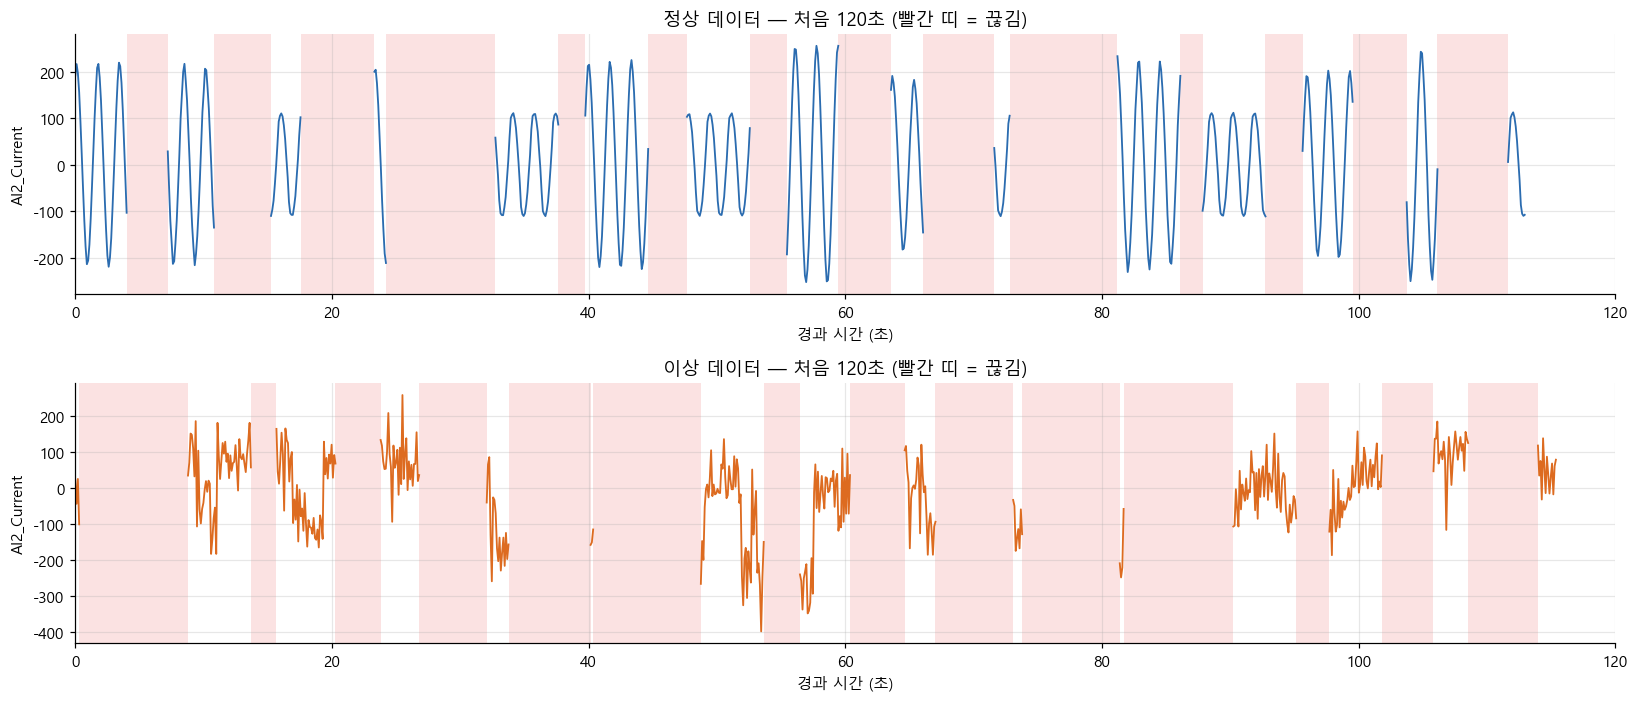

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6.5))
for ax, (lab, d) in zip(axes, IV.items()):
    part = d[d['t_sec'] <= TIMELINE_SEC]
    for _, s in part.groupby('segment_id', sort=False):
        ax.plot(s['t_sec'], s['AI2_Current'], color=COL[lab], lw=1.2)
    ends = part.groupby('segment_id', sort=False)['t_sec'].agg(['first', 'last'])
    for a, b in zip(ends['last'].iloc[:-1], ends['first'].iloc[1:]):
        ax.axvspan(a, b, color=GAP_COLOR, alpha=.15, lw=0)
    ax.set(title=f'{LAB[lab]} 데이터 — 처음 {TIMELINE_SEC}초 (빨간 띠 = 끊김)', xlabel='경과 시간 (초)',
           ylabel='AI2_Current', xlim=(0, TIMELINE_SEC))
plt.tight_layout(); show('02_1_gap_waveform', '앞부분 전류 파형과 끊김(빨간 띠)')

### 02-2 간격은 어떤 값들인가

**왼쪽 두 그림**: 간격을 범위별로 묶은 개수(로그 눈금). 회색 범위는 0개입니다.
**오른쪽 위**: 0–300 ms 간격을 1 ms 칸으로 센 히스토그램. **오른쪽 아래**: 전체 간격의 누적 비율(ECDF). 빨간 점선은 현재 gap 기준입니다.

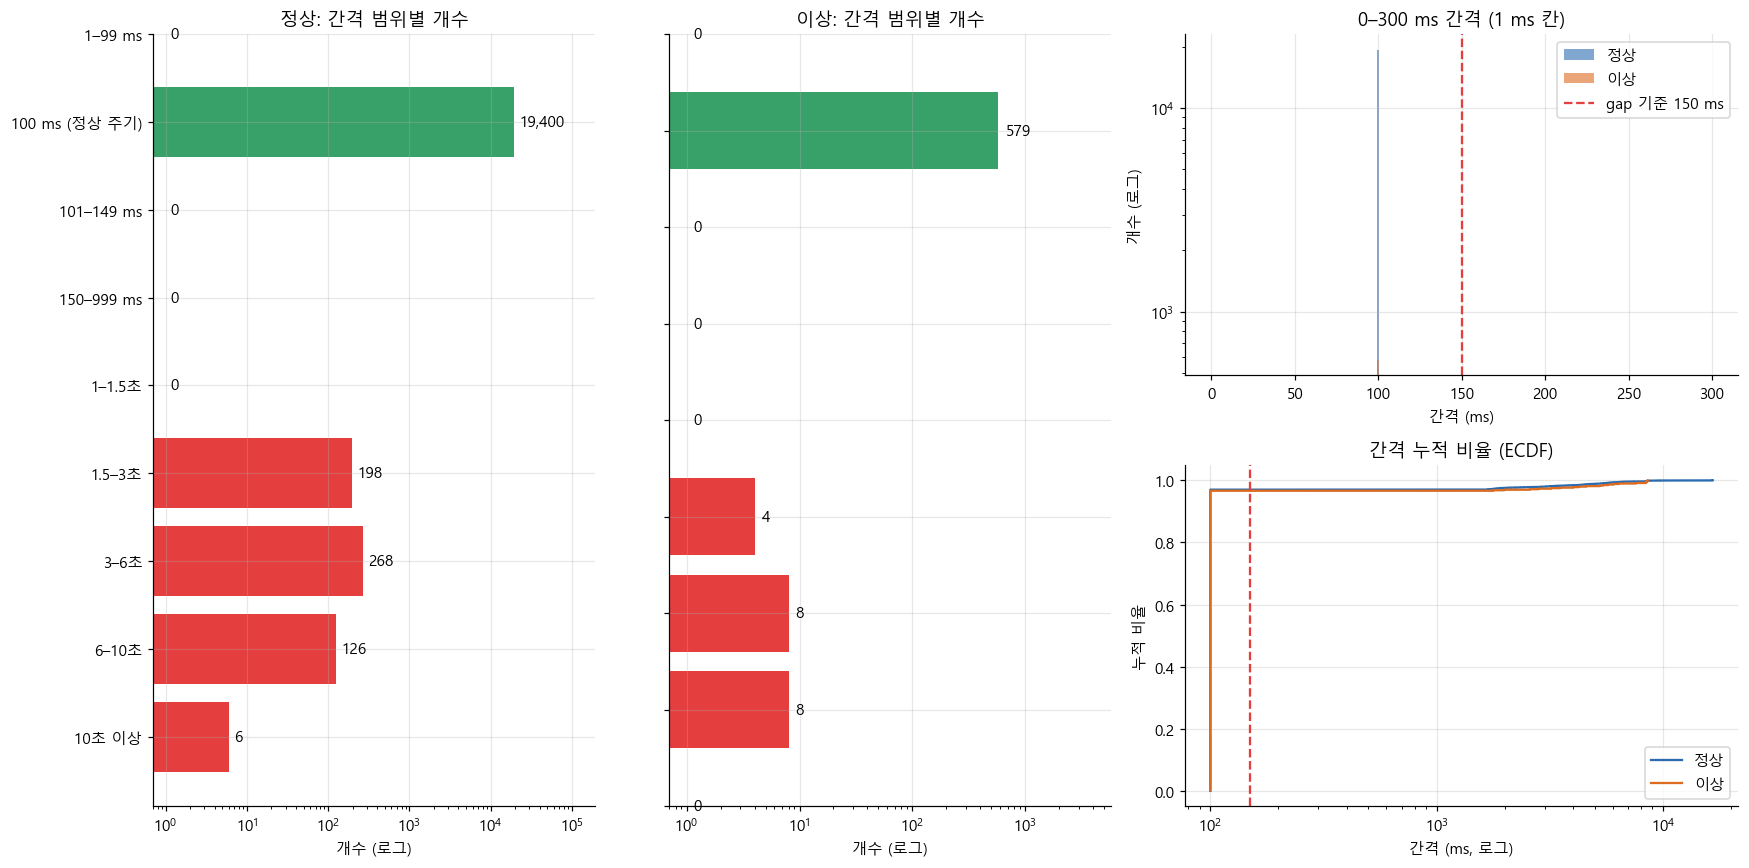

In [14]:
BANDS = [('1–99 ms', 1, 99), (f'{NOMINAL_MS} ms (정상 주기)', NOMINAL_MS, NOMINAL_MS), ('101–149 ms', 101, 149),
         ('150–999 ms', 150, 999), ('1–1.5초', 1000, 1499), ('1.5–3초', 1500, 2999), ('3–6초', 3000, 5999),
         ('6–10초', 6000, 9999), ('10초 이상', 10000, np.inf)]
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.25])
for k, (lab, d) in enumerate(IV.items()):
    ax = fig.add_subplot(gs[:, k])
    vals = np.array([((d['dt_ms'] >= lo) & (d['dt_ms'] <= hi)).sum() for _, lo, hi in BANDS])
    colors = [SAFE_COLOR if hi == NOMINAL_MS else GAP_COLOR if lo >= 1500 else '#a0aec0' for _, lo, hi in BANDS]
    y = np.arange(len(BANDS))[::-1]
    ax.barh(y, np.where(vals > 0, vals, np.nan), color=colors)
    for yi, v in zip(y, vals):
        ax.text(max(v, 1) * 1.15, yi, f'{v:,}', va='center', fontsize=10)
    ax.set_xscale('log'); ax.set_xlim(.7, vals.max() * 10)
    ax.set_yticks(y, [b[0] for b in BANDS] if k == 0 else [''] * len(BANDS))
    ax.set(title=f'{LAB[lab]}: 간격 범위별 개수', xlabel='개수 (로그)')
ax = fig.add_subplot(gs[0, 2])
for lab, d in IV.items():
    dt = d['dt_ms'].dropna()
    ax.hist(dt[dt <= HIST_MAX_MS], bins=np.arange(-.5, HIST_MAX_MS + 1.5, 1), color=COL[lab], alpha=.6, label=LAB[lab])
ax.axvline(GAP_MS, color=GAP_COLOR, ls='--', label=f'gap 기준 {GAP_MS} ms')
ax.set(title=f'0–{HIST_MAX_MS} ms 간격 (1 ms 칸)', xlabel='간격 (ms)', ylabel='개수 (로그)', yscale='log'); ax.legend()
ax = fig.add_subplot(gs[1, 2])
for lab, d in IV.items():
    x = np.sort(d['dt_ms'].dropna().values)
    ax.step(x, np.arange(1, len(x) + 1) / len(x), where='post', color=COL[lab], label=LAB[lab])
ax.axvline(GAP_MS, color=GAP_COLOR, ls='--')
ax.set(title='간격 누적 비율 (ECDF)', xlabel='간격 (ms, 로그)', ylabel='누적 비율', xscale='log'); ax.legend()
plt.tight_layout(); show('02_2_intervals', '간격 값 분포: 범위별 개수, 1 ms 히스토그램, 누적 비율')

### 02-3 끊김 길이

끊김이 얼마나 오래 이어지는지 봅니다. 파일 크기가 달라서 왼쪽은 **비율**로 그렸습니다.

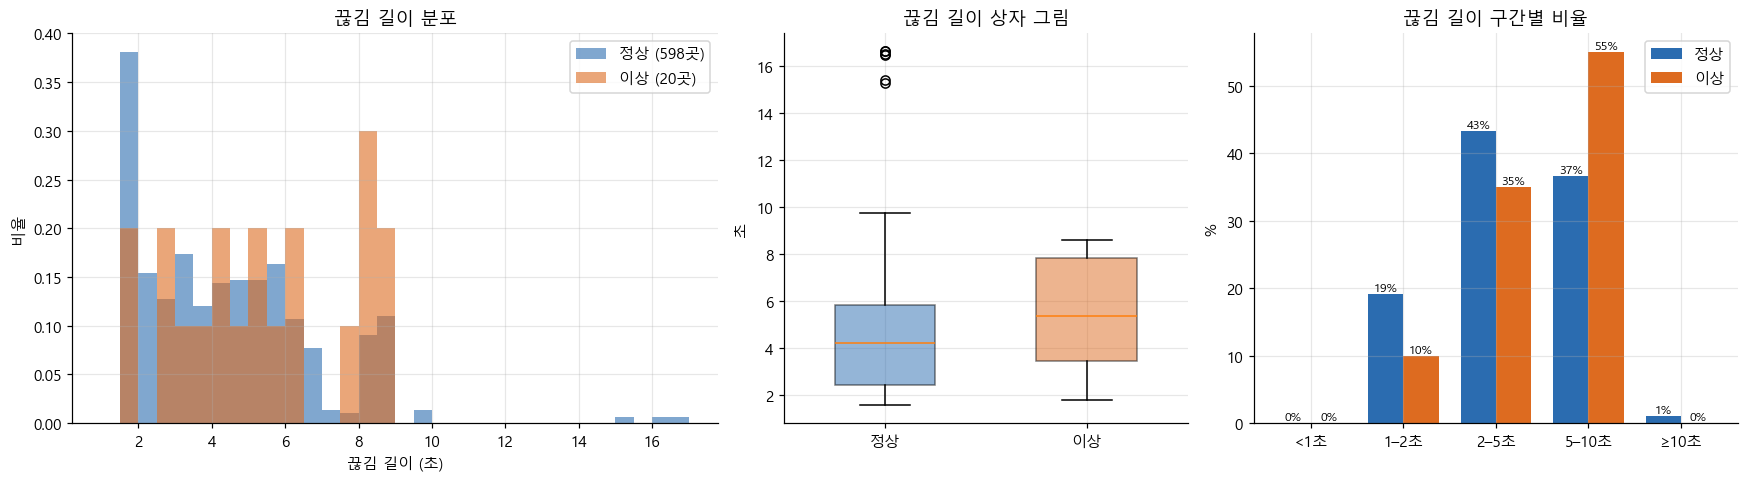

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), gridspec_kw={'width_ratios': [1.6, 1, 1.2]})
GB = {lab: d.loc[d['dt_ms'] > GAP_MS, 'dt_ms'] / 1000 for lab, d in IV.items()}
for lab, g in GB.items():
    axes[0].hist(g, bins=np.arange(1, 17.5, .5), color=COL[lab], alpha=.6, density=True, label=f'{LAB[lab]} ({len(g)}곳)')
axes[0].set(title='끊김 길이 분포', xlabel='끊김 길이 (초)', ylabel='비율'); axes[0].legend()
bp = axes[1].boxplot(list(GB.values()), tick_labels=[LAB[k] for k in GB], patch_artist=True, widths=.5)
for p, lab in zip(bp['boxes'], GB):
    p.set_facecolor(COL[lab]); p.set_alpha(.5)
axes[1].set(title='끊김 길이 상자 그림', ylabel='초')
edges, names = [0, 1, 2, 5, 10, np.inf], ['<1초', '1–2초', '2–5초', '5–10초', '≥10초']
x = np.arange(len(names))
for k, (lab, g) in enumerate(GB.items()):
    share = pd.cut(g, edges, right=False).value_counts(sort=False).values / len(g)
    b = axes[2].bar(x + (k - .5) * .38, share * 100, .38, color=COL[lab], label=LAB[lab])
    axes[2].bar_label(b, labels=[f'{v:.0%}' for v in share], fontsize=8)
axes[2].set_xticks(x, names); axes[2].set(title='끊김 길이 구간별 비율', ylabel='%'); axes[2].legend()
plt.tight_layout(); show('02_3_gap_length', '끊김 길이 분포')

### 02-4 gap 기준 정하기

**왼쪽**: 실제 간격 값(점 하나 = 간격 하나). 초록 띠는 간격 값이 하나도 없는 **빈 범위**입니다.
**가운데·오른쪽**: 기준을 바꿀 때 구간 수, 윈도 수가 어떻게 바뀌는지 그렸습니다. **초록 띠 안에서는 선이 평평합니다.** 즉 그 안의 어떤 값을 골라도 결과가 같습니다.

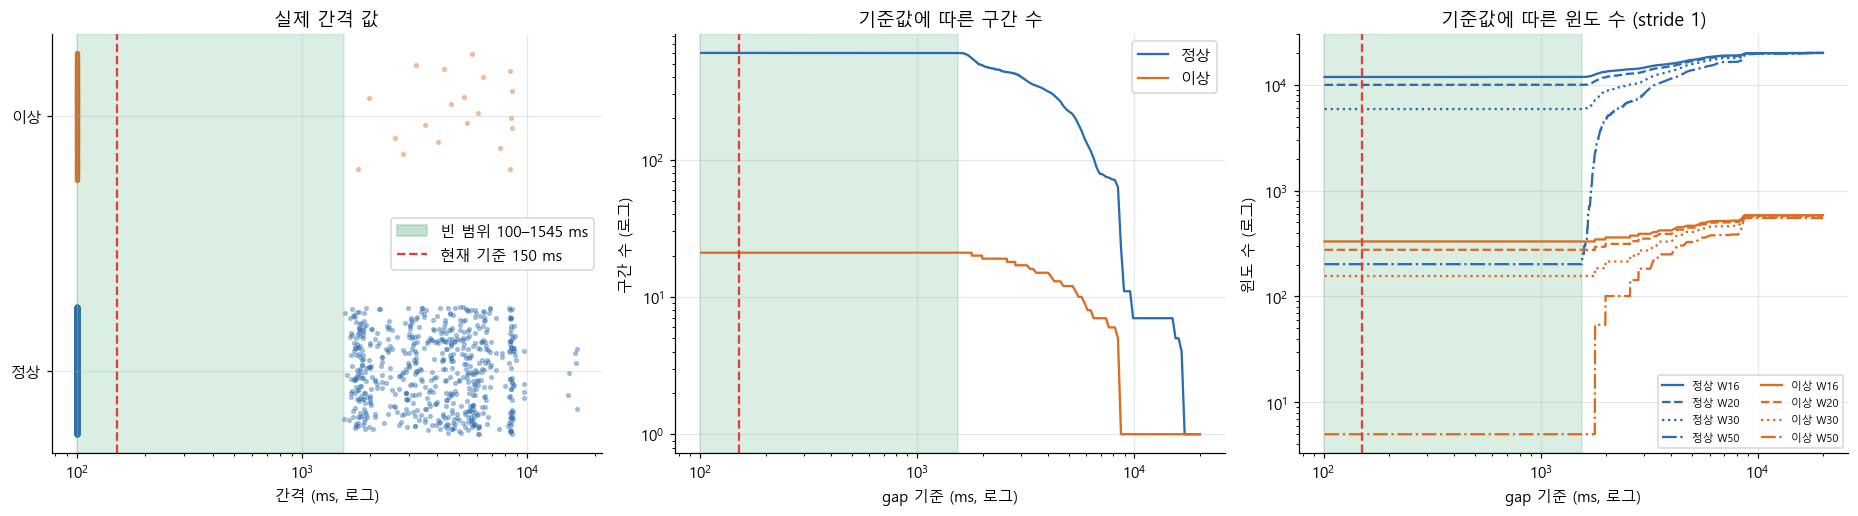

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
rng = np.random.default_rng(0)
for k, (lab, d) in enumerate(IV.items()):
    dt = d['dt_ms'].dropna(); dt = dt[dt > 0]
    axes[0].scatter(dt, k + rng.uniform(-.25, .25, len(dt)), s=6, alpha=.35, color=COL[lab])
axes[0].set_yticks(range(len(IV)), [LAB[k] for k in IV])
axes[0].set(title='실제 간격 값', xlabel='간격 (ms, 로그)', xscale='log')
for lab, d in IV.items():
    Ls = [seg_lengths(d, t) for t in CAND_GAP_MS]
    axes[1].plot(CAND_GAP_MS, [len(L) for L in Ls], color=COL[lab], label=LAB[lab])
    for w, ls in zip(CONFIG.windows, ['-', '--', ':', '-.']):
        axes[2].plot(CAND_GAP_MS, [np.clip(L - w + 1, 0, None).sum() for L in Ls], color=COL[lab], ls=ls,
                     label=f'{LAB[lab]} W{w}')
axes[1].set(title='기준값에 따른 구간 수', xlabel='gap 기준 (ms, 로그)', ylabel='구간 수 (로그)', xscale='log', yscale='log')
axes[2].set(title='기준값에 따른 윈도 수 (stride 1)', xlabel='gap 기준 (ms, 로그)', ylabel='윈도 수 (로그)',
            xscale='log', yscale='log')
for ax in axes:
    ax.axvspan(SAFE_LO, SAFE_HI, color=SAFE_COLOR, alpha=.18)
    ax.axvline(GAP_MS, color=GAP_COLOR, ls='--')
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=SAFE_COLOR, alpha=.3),
                        plt.Line2D([], [], color=GAP_COLOR, ls='--')],
               labels=[f'빈 범위 {SAFE_LO:.0f}–{SAFE_HI:.0f} ms', f'현재 기준 {GAP_MS} ms'], loc='center right')
axes[1].legend(); axes[2].legend(fontsize=7, ncol=2)
plt.tight_layout(); show('02_4_gap_threshold', 'gap 기준값에 따른 구간·윈도 수 (초록 띠 안에서는 결과가 같음)')

sens = pd.read_csv(OUTPUT_DIR/'gap_sensitivity.csv')
sens['데이터'] = sens.source.map(lambda s: LAB[SRC_LAB[s]])
display(sens.drop(columns='source').set_index(['데이터', 'gap_threshold'])
        .style.set_caption('원본 파이프라인의 민감도 표 (기준: 초)'))

### 02-5 끊김의 정체 — 샘플 누락인가, 기록 재시작인가

0.1초 시계가 계속 돌고 있는데 **샘플 몇 개만 빠진 것**이라면, 끊김 길이가 100 ms의 정수배에 딱 맞고 구간마다 '박자 위치'가 같아야 합니다.

- **왼쪽**: 끊김 길이와 가장 가까운 100 ms 배수의 차이입니다. 0에 몰리지 않고 −50~+50에 고르게 퍼져 있습니다.
- **가운데**: 구간마다 시작 시각을 100 ms로 나눈 나머지입니다. 구간마다 제각각입니다.
- **오른쪽**: 원본 파이프라인이 계산한 '빠진 행 수 추정'에 따른 시간 가용률입니다. 위 두 결과를 보면 이 추정은 **참고용**으로만 봐야 합니다.

➡ 끊김은 **기록이 멈췄다가 새 박자로 다시 시작**된 것으로 보입니다. 끊긴 자리를 보간으로 채울 근거가 약합니다.

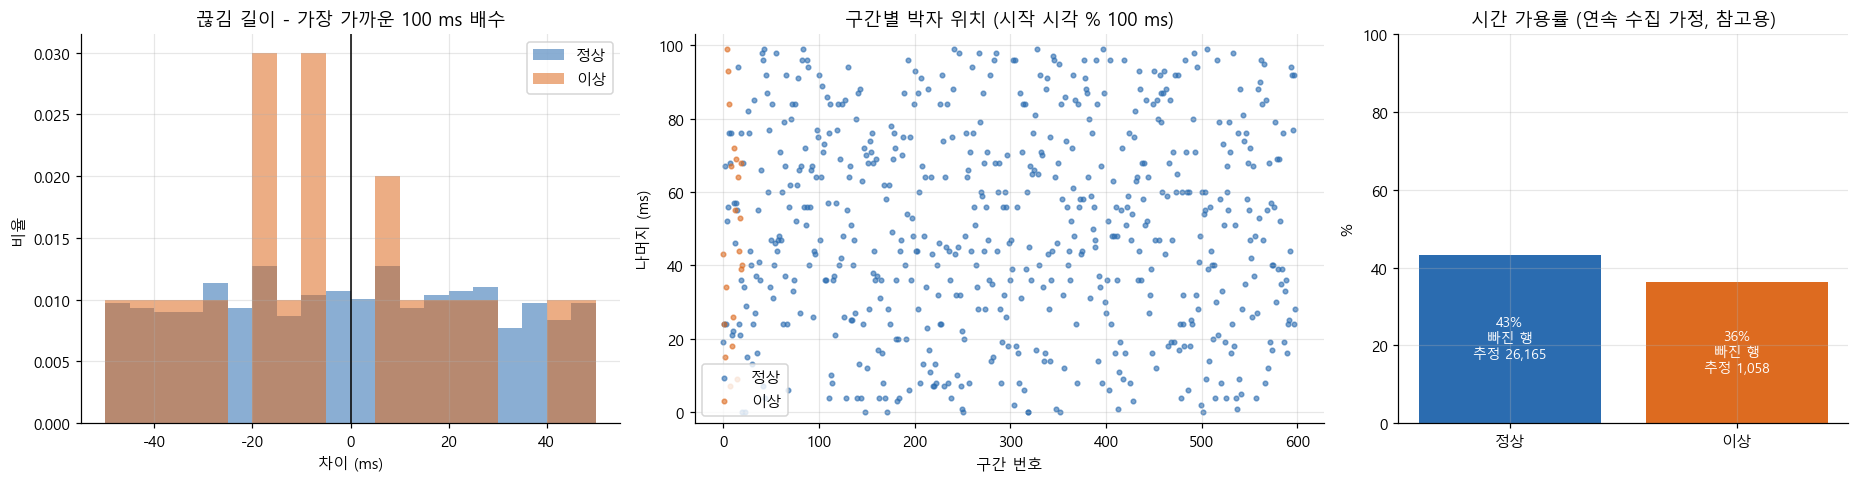

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={'width_ratios': [1.2, 1.4, 1]})
for lab, d in IV.items():
    g = d.loc[d['dt_ms'] > GAP_MS, 'dt_ms']
    axes[0].hist(g - (g / NOMINAL_MS).round() * NOMINAL_MS, bins=np.arange(-50, 52, 5), color=COL[lab],
                 alpha=.55, density=True, label=LAB[lab])
    phase = d.groupby('segment_id', sort=False)['t_ms'].first() % NOMINAL_MS
    axes[1].scatter(np.arange(len(phase)), phase.values, s=9, color=COL[lab], alpha=.6, label=LAB[lab])
axes[0].axvline(0, color='black', lw=1)
axes[0].set(title=f'끊김 길이 - 가장 가까운 {NOMINAL_MS} ms 배수', xlabel='차이 (ms)', ylabel='비율'); axes[0].legend()
axes[1].set(title=f'구간별 박자 위치 (시작 시각 % {NOMINAL_MS} ms)', xlabel='구간 번호', ylabel='나머지 (ms)', ylim=(-3, 103))
axes[1].legend()
me = pd.read_csv(OUTPUT_DIR/'missing_estimates.csv').query("stage == 'clean_sorted'")
x = np.arange(len(me))
b = axes[2].bar(x, me['time_availability'] * 100, color=[COL[SRC_LAB[s]] for s in me.source])
axes[2].bar_label(b, labels=[f'{v:.0%}\n빠진 행\n추정 {n:,}' for v, n in zip(me.time_availability, me.missing_round)],
                  label_type='center', color='white', fontsize=9)
axes[2].set_xticks(x, [LAB[SRC_LAB[s]] for s in me.source])
axes[2].set(title='시간 가용률 (연속 수집 가정, 참고용)', ylabel='%', ylim=(0, 100))
plt.tight_layout(); show('02_5_restart', '끊김이 샘플 누락이 아니라 기록 재시작이라는 근거')

### 02-6 구간 안쪽 간격의 흔들림과 구간 길이

**왼쪽**: 끊김이 아닌 간격이 100 ms에서 몇 ms 벗어나는지(1 ms 단위). **가운데**: 구간 길이 분포와 윈도 길이(점선). **오른쪽**: 시간 순서대로 본 구간 길이입니다.

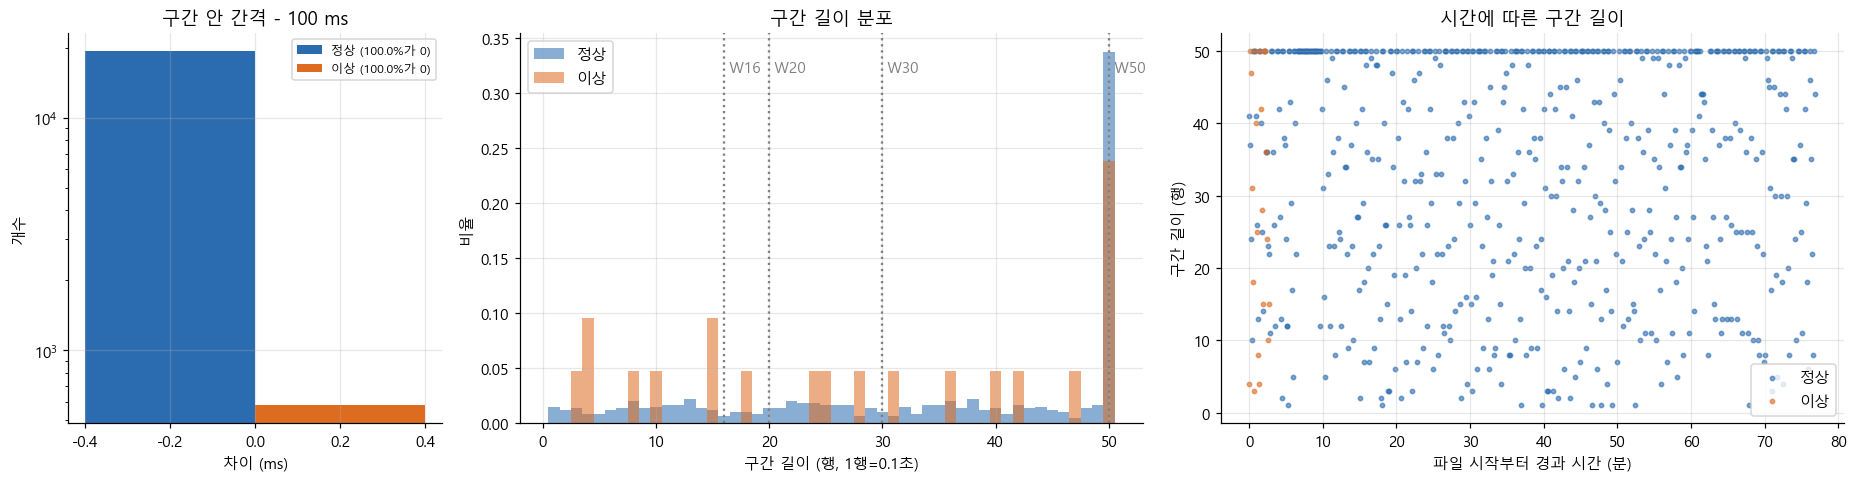

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={'width_ratios': [.9, 1.5, 1.5]})
for k, (lab, d) in enumerate(IV.items()):
    inner = d['dt_ms'][(d['dt_ms'] > 0) & (d['dt_ms'] <= GAP_MS)] - NOMINAL_MS
    vc = inner.value_counts().sort_index()
    axes[0].bar(vc.index + (k - .5) * .4, vc.values, .4, color=COL[lab], label=f'{LAB[lab]} ({(inner == 0).mean():.1%}가 0)')
    L = seg_lengths(d, GAP_MS)
    axes[1].hist(L, bins=np.arange(.5, L.max() + 1.5, 1), color=COL[lab], alpha=.55, density=True, label=LAB[lab])
    first = d.groupby('segment_id', sort=False).agg(start=('t_sec', 'first'), n=('t_sec', 'size'))
    axes[2].scatter(first['start'] / 60, first['n'], s=8, color=COL[lab], alpha=.6, label=LAB[lab])
axes[0].set(title=f'구간 안 간격 - {NOMINAL_MS} ms', xlabel='차이 (ms)', ylabel='개수', yscale='log'); axes[0].legend(fontsize=8)
for w in CONFIG.windows:
    axes[1].axvline(w, color='gray', ls=':'); axes[1].text(w, axes[1].get_ylim()[1] * .9, f' W{w}', color='gray')
axes[1].set(title='구간 길이 분포', xlabel='구간 길이 (행, 1행=0.1초)', ylabel='비율'); axes[1].legend()
axes[2].set(title='시간에 따른 구간 길이', xlabel='파일 시작부터 경과 시간 (분)', ylabel='구간 길이 (행)'); axes[2].legend()
plt.tight_layout(); show('02_6_segments', '구간 안 간격의 흔들림과 구간 길이')

## 03–04 구간 분할

구간 단위로 Train/Valid/Test를 나눕니다. 정상은 시간 순서대로 약 60/20/20%, 이상은 Valid/Test에 약 50/50%입니다. 한 구간은 한 분할에만 속합니다.

**왜 이렇게 나누나요?**

| 규칙 | 이유 |
|---|---|
| 구간(segment)을 통째로 한 분할에 | 윈도는 한 칸씩 밀며 잘라서 이웃 윈도가 거의 같습니다. 행 단위로 섞으면 거의 같은 윈도가 Train과 Test에 함께 들어가 성능이 부풀려집니다. |
| 시간 순서대로 (앞=Train, 뒤=Test) | 과거 데이터로 학습하고 미래 데이터로 평가하는 현장 상황과 같게 합니다. |
| 이상은 Train에 넣지 않음 | 이상 데이터가 600행뿐이라 정상만 학습하고, 정상에서 벗어난 정도로 이상을 찾습니다. |
| 정상 Valid 20% | 임계값을 "정상 오탐률 1%"로 정하는 데 씁니다. 정상만 쓰므로 이상 표본 수에 흔들리지 않습니다. |
| 이상 Valid/Test 반씩 | 이상 구간 21개를 앞쪽 11개, 뒤쪽 10개로 나눕니다. Test는 마지막에 한 번만 성능을 잽니다. |

모델은 이 노트북의 `run_baselines`가 직접 만드는 비교용 기준 모델(E0~E3)입니다. 외부 모델을 불러오지 않습니다.
**오른쪽 그림**은 시간축 위에서 각 구간이 어느 분할에 들어갔는지 보여 줍니다.

원본 행·구간 분할 검증 통과


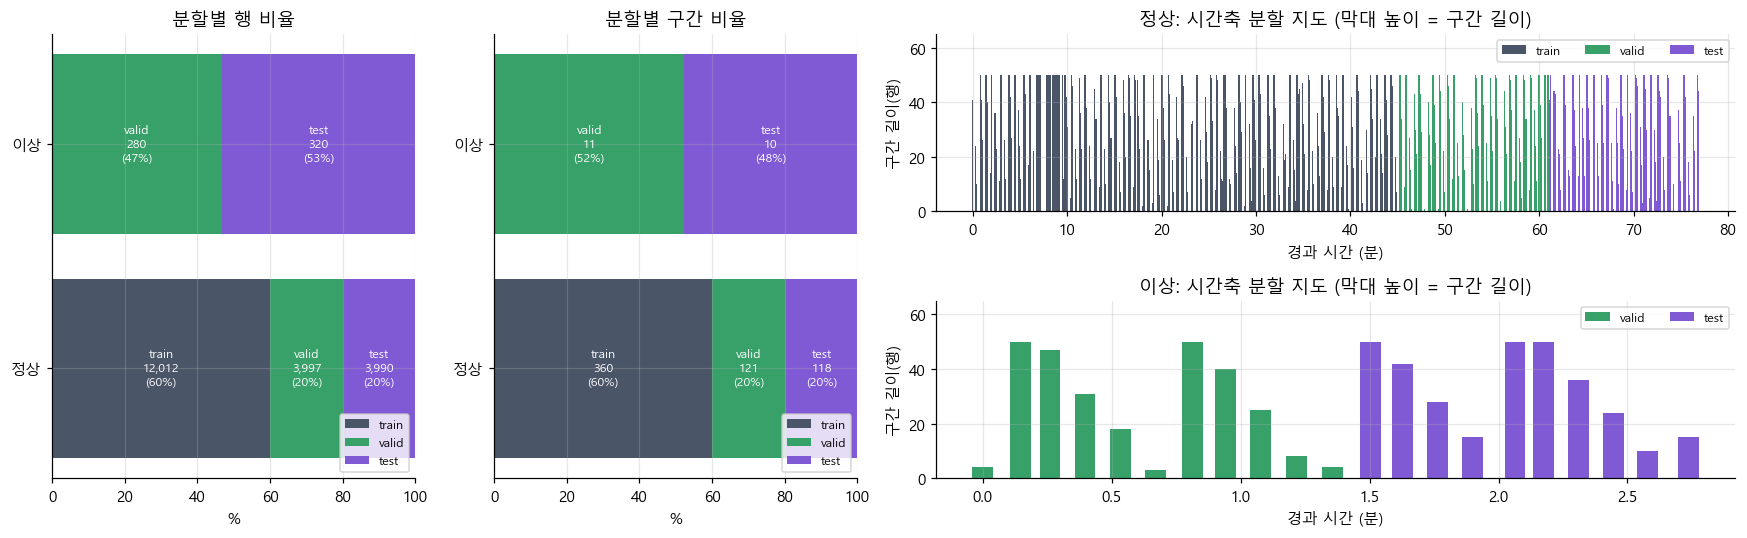

In [19]:
rows, segments = split_segments(rows, OUTPUT_DIR, CONFIG)
assert rows.row_id.is_unique
assert rows.groupby('segment_id').split.nunique().eq(1).all()
assert not ((rows.split == 'train') & (rows.Equipment_state == 1)).any()
print('원본 행·구간 분할 검증 통과')

summ = segments.groupby(['label', 'split']).agg(rows=('n_rows', 'sum'), segs=('segment_id', 'size')).reset_index()
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 2.2])
for j, (col, title) in enumerate([('rows', '분할별 행 비율'), ('segs', '분할별 구간 비율')]):
    ax = fig.add_subplot(gs[:, j])
    tot = np.array([summ.query('label == @l')[col].sum() for l in (0, 1)])
    left = np.zeros(2)
    for sp in ['train', 'valid', 'test']:
        v = np.array([summ.query('label == @l and split == @sp')[col].sum() for l in (0, 1)])
        pct = v / tot * 100
        ax.barh([LAB[0], LAB[1]], pct, left=left, color=SPLIT_COL[sp], label=sp)
        for i, (vv, pp, ll) in enumerate(zip(v, pct, left)):
            if vv:
                ax.text(ll + pp / 2, i, f'{sp}\n{vv:,}\n({pp:.0f}%)', ha='center', va='center', color='white', fontsize=8)
        left += pct
    ax.set(title=title, xlim=(0, 100), xlabel='%'); ax.legend(fontsize=8, loc='lower right')
for k, lab in enumerate([0, 1]):
    ax = fig.add_subplot(gs[k, 2])
    s = segments.query('label == @lab')
    t0 = s.start.min()
    for sp in [x for x in ['train', 'valid', 'test'] if x in set(s.split)]:
        g = s[s.split == sp]
        ax.bar((g.start - t0).dt.total_seconds() / 60, g.n_rows, width=.08, color=SPLIT_COL[sp], label=sp)
    ax.set(title=f'{LAB[lab]}: 시간축 분할 지도 (막대 높이 = 구간 길이)', xlabel='경과 시간 (분)', ylabel='구간 길이(행)',
           ylim=(0, 65))
    ax.legend(fontsize=8, ncol=3, loc='upper right')
plt.tight_layout(); show('03_split', '구간 단위 Train/Valid/Test 분할과 시간축 분할 지도')

## 05–06 윈도와 특징 계산

구간 안에서 W행씩 한 칸씩 밀며 윈도를 자르고, 윈도마다 시간 특징(RMS·P2P 등)과 주파수 특징(FFT·PSD)을 계산합니다. **몇 분 걸립니다.**
그래프는 윈도 길이별로 만들어진 윈도 수와, 윈도에 실제로 쓰인 행의 비율입니다. 긴 윈도일수록 짧은 구간을 못 써서 활용률이 떨어집니다.

전체 윈도 수: 28,681 / 모든 윈도가 균일 간격: True


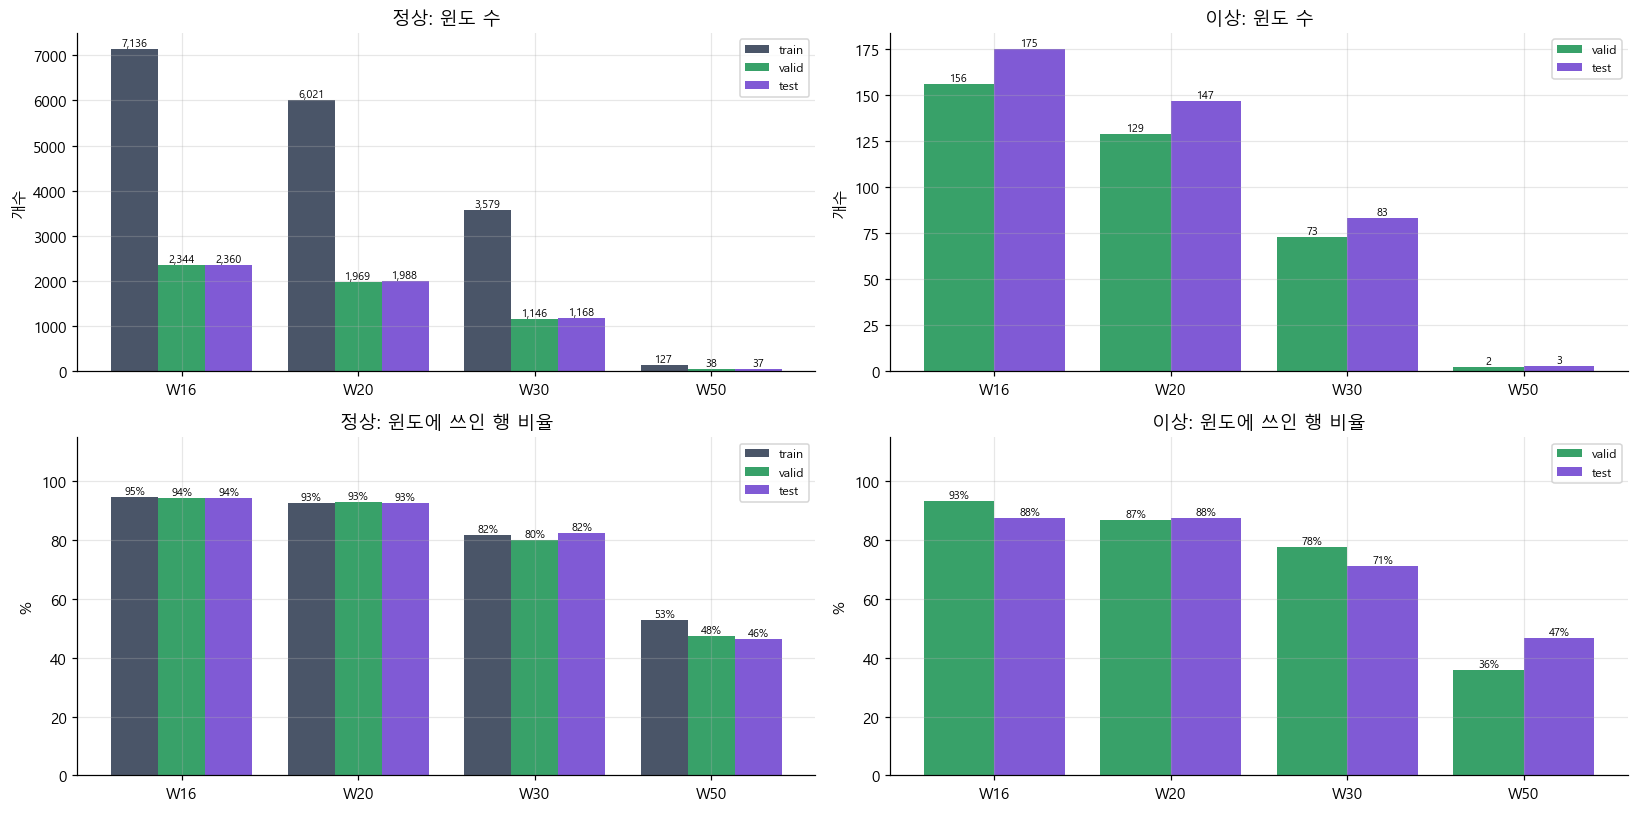

In [20]:
windows, coverage, spectra = extract_windows(rows, segments, OUTPUT_DIR, CONFIG)
print('전체 윈도 수:', f'{len(windows):,}', '/ 모든 윈도가 균일 간격:', bool(windows.uniform.all()))

cov = coverage.groupby(['label', 'split', 'window'], as_index=False)[['windows', 'used_rows', 'n_rows']].sum()
cov['row_coverage'] = cov.used_rows / cov.n_rows
fig, axes = plt.subplots(2, 2, figsize=(15, 7.5))
for k, lab in enumerate([0, 1]):
    c = cov.query('label == @lab')
    splits = [s for s in ['train', 'valid', 'test'] if s in set(c.split)]
    x = np.arange(len(CONFIG.windows)); bw = .8 / len(splits)
    for j, sp in enumerate(splits):
        cs = c.query('split == @sp').set_index('window').reindex(CONFIG.windows)
        b1 = axes[0, k].bar(x + (j - (len(splits) - 1) / 2) * bw, cs.windows, bw, color=SPLIT_COL[sp], label=sp)
        axes[0, k].bar_label(b1, labels=[f'{v:,}' for v in cs.windows], fontsize=7)
        b2 = axes[1, k].bar(x + (j - (len(splits) - 1) / 2) * bw, cs.row_coverage * 100, bw, color=SPLIT_COL[sp], label=sp)
        axes[1, k].bar_label(b2, labels=[f'{v:.0%}' for v in cs.row_coverage], fontsize=7)
    for r, (t, yl) in enumerate([('윈도 수', '개수'), ('윈도에 쓰인 행 비율', '%')]):
        axes[r, k].set_xticks(x, [f'W{w}' for w in CONFIG.windows])
        axes[r, k].set(title=f'{LAB[lab]}: {t}', ylabel=yl); axes[r, k].legend(fontsize=8)
    axes[1, k].set_ylim(0, 115)
plt.tight_layout(); show('05_windows', '윈도 길이별 윈도 수와 행 활용률')

### 06 계획서 수치와 재계산 비교

계획서의 예비 수치와 지금 계산한 값이 같은지 확인합니다.

In [21]:
claims = []
for filename, label in FILES.items():
    ss = segments.loc[segments.source.eq(filename)]
    expected = {'raw_rows': 20000 if label == 0 else 600, 'segments': 599 if label == 0 else 21,
                'max_segment_length': 50, 'W16': 11840 if label == 0 else 331,
                'W20': 9978 if label == 0 else 276, 'W30': 5893 if label == 0 else 156}
    actual = {'raw_rows': len(pd.read_csv(DATA_DIR/filename)), 'segments': len(ss), 'max_segment_length': ss.n_rows.max(),
              **{f'W{w}': int(((windows.source == filename) & (windows.window == w)).sum()) for w in (16,20,30)}}
    claims.extend(dict(source=filename, item=k, expected=v, actual=int(actual[k]), matches=v == actual[k]) for k,v in expected.items())
save_csv(pd.DataFrame(claims), OUTPUT_DIR / 'plan_claim_comparison.csv')
cl = pd.DataFrame(claims)
cl['데이터'] = cl.source.map(lambda s: LAB[SRC_LAB[s]])
cl['일치'] = np.where(cl.matches, '✔ 일치', '✘ 불일치')
display(cl[['데이터', 'item', 'expected', 'actual', '일치']].style
        .map(lambda v: 'color:#2f855a;font-weight:bold' if '✔' in str(v) else 'color:#c53030;font-weight:bold' if '✘' in str(v) else '',
             subset=['일치']).format({'expected': '{:,}', 'actual': '{:,}'}).hide(axis='index'))

데이터,item,expected,actual,일치
정상,raw_rows,"20,000","20,000",✔ 일치
정상,segments,599,599,✔ 일치
정상,max_segment_length,50,50,✔ 일치
정상,W16,"11,840","11,840",✔ 일치
정상,W20,"9,978","9,978",✔ 일치
정상,W30,"5,893","5,893",✔ 일치
이상,raw_rows,600,600,✔ 일치
이상,segments,21,21,✔ 일치
이상,max_segment_length,50,50,✔ 일치
이상,W16,331,331,✔ 일치


## 07 E0~E3 기준 실험

| 실험 | 입력 | 모델 |
|---|---|---|
| E0_abs_OR | 행 하나의 센서 절댓값 | 정상 99% 분위수로 나눈 값의 최댓값 |
| E1_time_W20 | W20 시간 특징 | Isolation Forest |
| E2_time_psd_W20 | W20 시간 + 주파수 특징 | Isolation Forest |
| E3_time_W16 / W30 | W16·W30 시간 특징 | Isolation Forest |

정상 Train으로만 학습하고, 임계값은 Valid에서 **정상 오탐률 1%**가 되도록 고정합니다. 아래 성능은 Test 결과입니다.

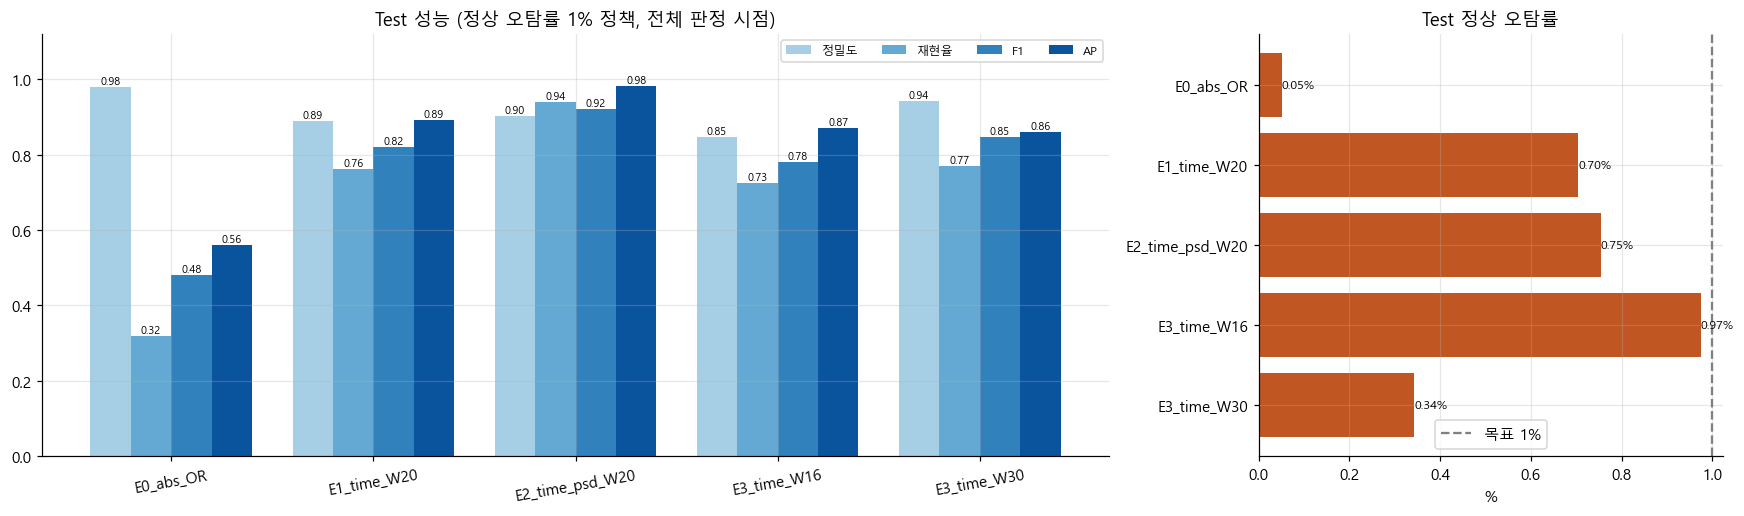

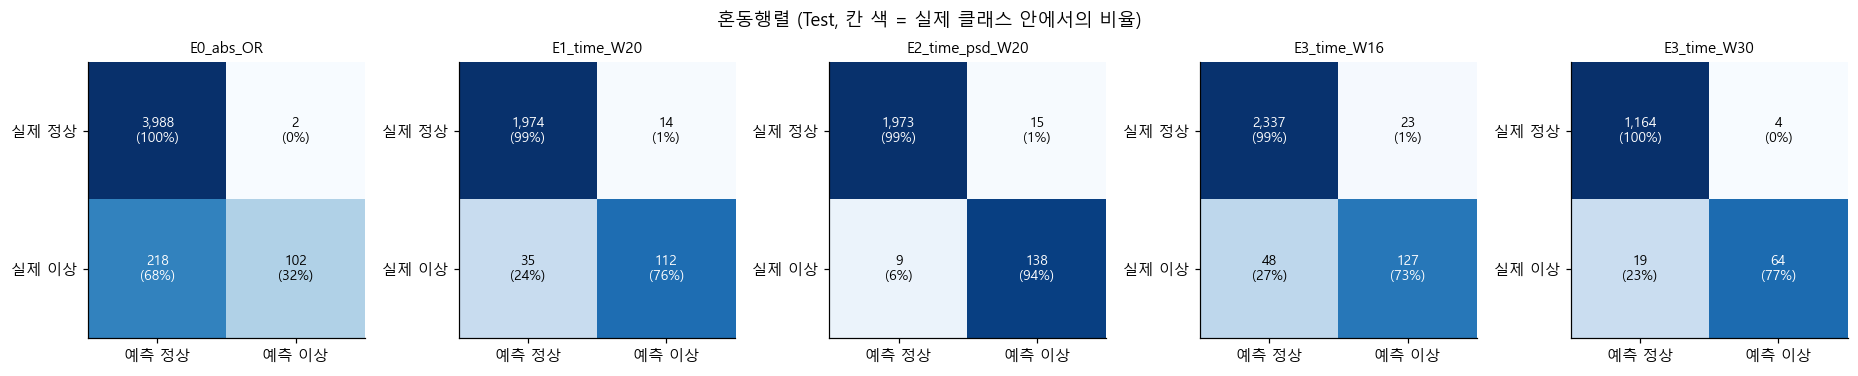

In [22]:
metrics, predictions = run_baselines(rows, windows, OUTPUT_DIR, CONFIG)
primary = metrics.query("split == 'test' and policy == 'normal_fpr_0.01' and weighting == 'decision' and scope == 'all'")
primary = primary.set_index('experiment').reindex(EXP_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={'width_ratios': [2.3, 1]})
names = ['precision', 'recall', 'f1', 'ap']
kor = {'precision': '정밀도', 'recall': '재현율', 'f1': 'F1', 'ap': 'AP'}
x = np.arange(len(EXP_ORDER)); bw = .2
for j, m in enumerate(names):
    b = axes[0].bar(x + (j - 1.5) * bw, primary[m], bw, label=kor[m], color=plt.cm.Blues(.35 + .17 * j))
    axes[0].bar_label(b, labels=[f'{v:.2f}' for v in primary[m]], fontsize=7)
axes[0].set_xticks(x, EXP_ORDER, rotation=10); axes[0].set_ylim(0, 1.12)
axes[0].set(title='Test 성능 (정상 오탐률 1% 정책, 전체 판정 시점)'); axes[0].legend(ncol=4, fontsize=8)
b = axes[1].barh(EXP_ORDER[::-1], primary['normal_fpr'][::-1] * 100, color='#c05621')
axes[1].bar_label(b, labels=[f'{v:.2%}' for v in primary['normal_fpr'][::-1]], fontsize=8)
axes[1].axvline(1, color='gray', ls='--', label='목표 1%')
axes[1].set(title='Test 정상 오탐률', xlabel='%'); axes[1].legend()
plt.tight_layout(); show('07_performance', 'Test 성능과 정상 오탐률')

fig, axes = plt.subplots(1, len(EXP_ORDER), figsize=(17, 3.3))
for ax, e in zip(axes, EXP_ORDER):
    r = primary.loc[e]
    cm = np.array([[r.tn, r.fp], [r.fn, r.tp]], dtype=float)
    ax.imshow(cm / cm.sum(axis=1, keepdims=True), cmap='Blues', vmin=0, vmax=1)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f'{v:,.0f}\n({v / cm[i].sum():.0%})', ha='center', va='center', fontsize=9,
                color='white' if v / cm[i].sum() > .6 else 'black')
    ax.set_xticks([0, 1], ['예측 정상', '예측 이상']); ax.set_yticks([0, 1], ['실제 정상', '실제 이상'])
    ax.set_title(e, fontsize=10); ax.grid(False)
fig.suptitle('혼동행렬 (Test, 칸 색 = 실제 클래스 안에서의 비율)')
plt.tight_layout(); show('07_confusion', 'Test 혼동행렬')

### 07-1 점수 분포와 PR 곡선

**위**: 실험마다 Test 점수 분포입니다. 점수가 **빨간 점선(임계값)보다 크면 이상**으로 판정합니다. 두 색이 잘 갈라질수록 좋은 모델입니다.
**아래 왼쪽**: PR 곡선(재현율에 따른 정밀도). 오른쪽 위로 붙을수록 좋습니다. **아래 오른쪽**: 임계값 정책을 바꿀 때 F1이 어떻게 변하는지 보여 줍니다.

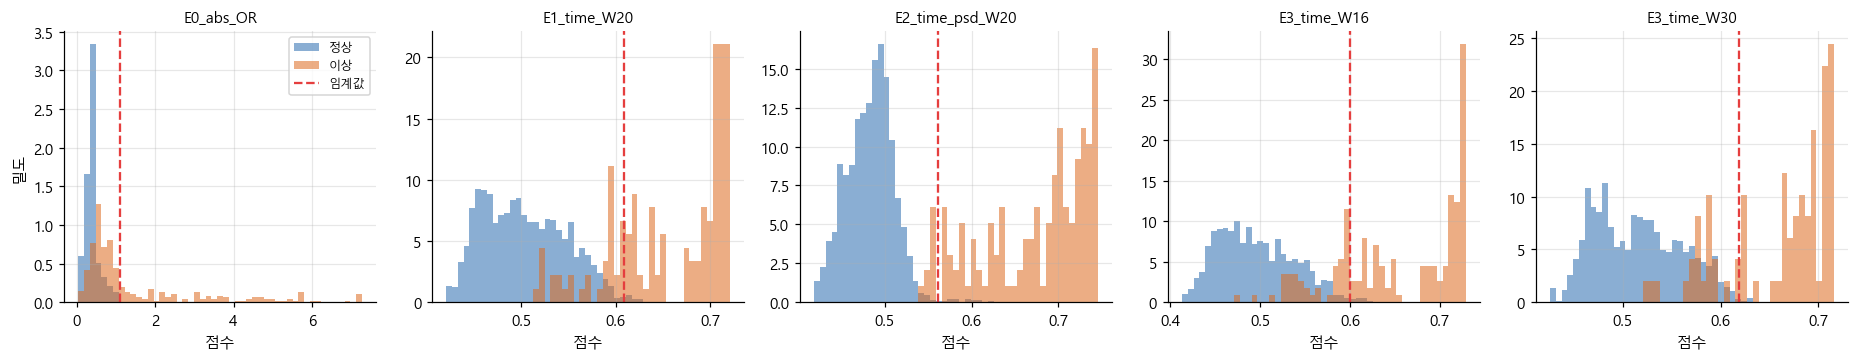

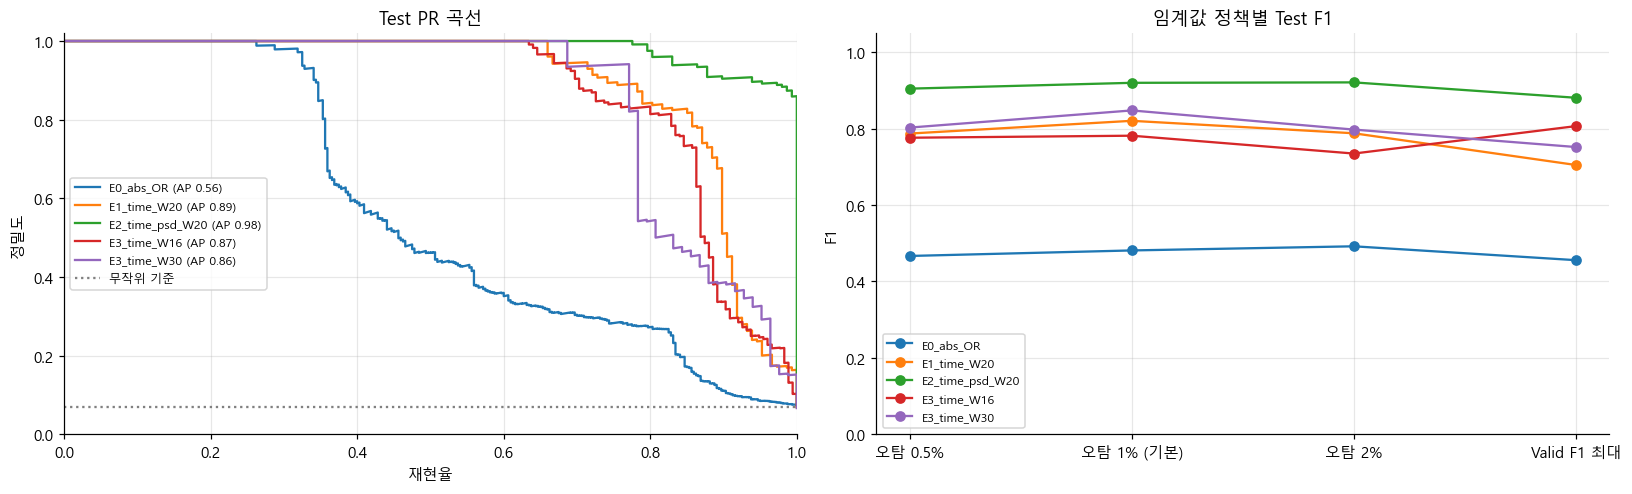

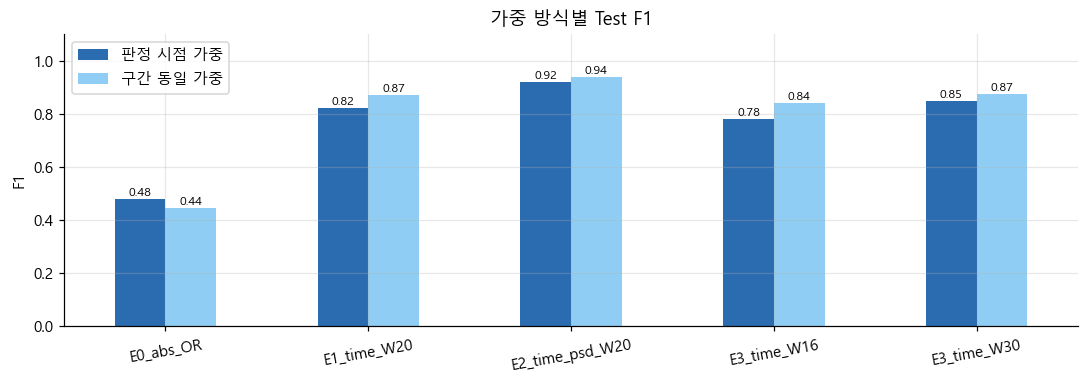

policy,normal_fpr_0.005,normal_fpr_0.01,normal_fpr_0.02,valid_f1_supervised
experiment,,,,
E0_abs_OR,1.169,1.106,1.047,1.204
E1_time_W20,0.6195,0.6085,0.588,0.6687
E2_time_psd_W20,0.5711,0.5618,0.546,0.5917
E3_time_W16,0.621,0.6001,0.5766,0.588
E3_time_W30,0.6275,0.619,0.6065,0.6655


In [23]:
test = predictions.query("split == 'test' and policy == 'normal_fpr_0.01'")
fig, axes = plt.subplots(1, len(EXP_ORDER), figsize=(17, 3.4))
for ax, e in zip(axes, EXP_ORDER):
    t = test[test.experiment == e]
    lo, hi = np.quantile(t.score, [.001, .999])
    bins = np.linspace(lo, hi, 50)
    for lab in (0, 1):
        ax.hist(t.loc[t.label == lab, 'score'].clip(lo, hi), bins=bins, density=True, alpha=.55, color=COL[lab], label=LAB[lab])
    ax.axvline(t.threshold.iloc[0], color=GAP_COLOR, ls='--', label='임계값')
    ax.set_title(e, fontsize=10); ax.set_xlabel('점수')
axes[0].set_ylabel('밀도'); axes[0].legend(fontsize=8)
plt.tight_layout(); show('07_scores', 'Test 점수 분포와 임계값')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for e in EXP_ORDER:
    t = test[test.experiment == e]
    p, r, _ = precision_recall_curve(t.label, t.score)
    axes[0].plot(r, p, label=f'{e} (AP {average_precision_score(t.label, t.score):.2f})')
axes[0].axhline(test.groupby('experiment').label.mean().mean(), color='gray', ls=':', label='무작위 기준')
axes[0].set(title='Test PR 곡선', xlabel='재현율', ylabel='정밀도', xlim=(0, 1), ylim=(0, 1.02)); axes[0].legend(fontsize=8)
pol = metrics.query("split == 'test' and weighting == 'decision' and scope == 'all'")
order = ['normal_fpr_0.005', 'normal_fpr_0.01', 'normal_fpr_0.02', 'valid_f1_supervised']
for e in EXP_ORDER:
    v = pol[pol.experiment == e].set_index('policy').reindex(order)
    axes[1].plot(range(len(order)), v.f1, marker='o', label=e)
axes[1].set_xticks(range(len(order)), ['오탐 0.5%', '오탐 1% (기본)', '오탐 2%', 'Valid F1 최대'])
axes[1].set(title='임계값 정책별 Test F1', ylabel='F1', ylim=(0, 1.05)); axes[1].legend(fontsize=8)
plt.tight_layout(); show('07_pr_policy', 'PR 곡선과 임계값 정책별 F1')

eq = metrics.query("split == 'test' and policy == 'normal_fpr_0.01' and weighting == 'equal_segment' and scope == 'all'")
cmp = pd.DataFrame({'판정 시점 가중': primary['f1'], '구간 동일 가중': eq.set_index('experiment')['f1'].reindex(EXP_ORDER)})
ax = cmp.plot.bar(figsize=(10, 3.6), color=['#2b6cb0', '#90cdf4'], rot=10, title='가중 방식별 Test F1')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8)
ax.set(ylim=(0, 1.1), xlabel='', ylabel='F1'); plt.tight_layout(); show('07_weighting', '가중 방식별 F1')
display(pd.read_csv(OUTPUT_DIR/'thresholds.csv').pivot(index='experiment', columns='policy', values='threshold')
        .reindex(EXP_ORDER).style.format('{:.4g}').set_caption('정책별 임계값 (score > threshold 이면 이상)'))

## 08 신호·특징·주파수 그림

원본 함수로 그림 파일을 만들어 저장하고, 그중 주요 그림을 보여 줍니다. 이 탐색은 **Train+Valid**만 씁니다.
10 Hz 샘플링이라 볼 수 있는 주파수는 **0–5 Hz**입니다. 이 결과로 부품 고장 주파수를 진단하지는 않습니다.

In [24]:
make_figures(rows, windows, spectra, predictions, OUTPUT_DIR, CONFIG)
%matplotlib inline
if KR_FONT:
    plt.rcParams['font.family'] = KR_FONT
FIG = OUTPUT_DIR / 'figures'
print('그래프 저장:', FIG)

그래프 저장: 결과/20261003_194353_525477/figures


### 08-1 센서 값 분포와 파형

상태(0=정상, 1=이상)별 센서 값 분포(히스토그램·누적·상자 그림)와 구간별 파형입니다.

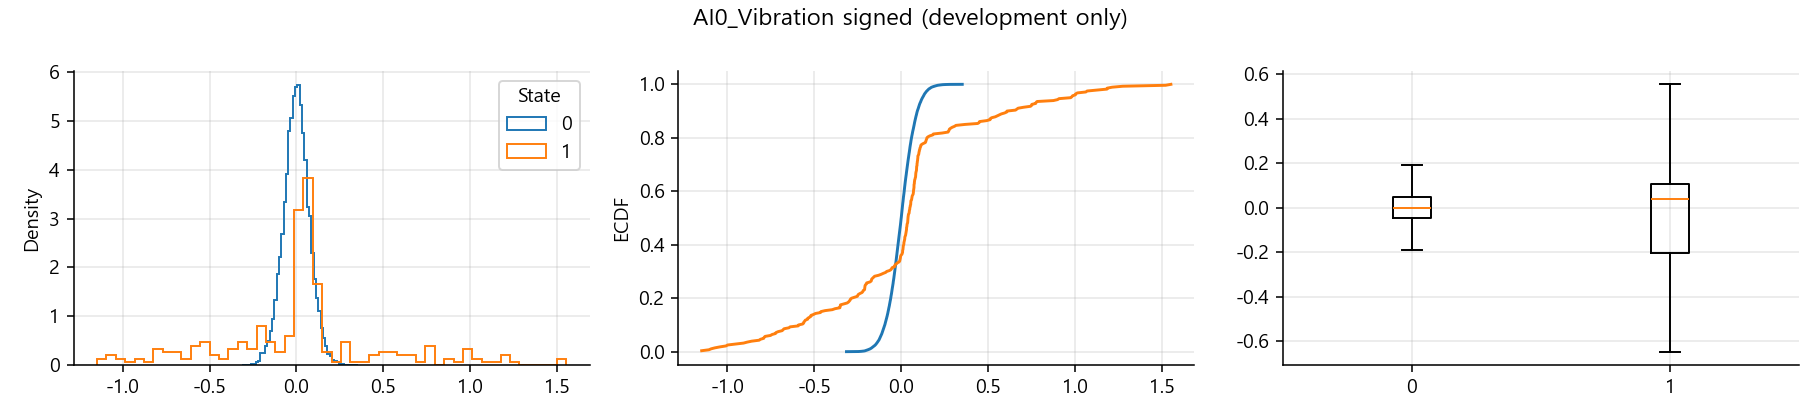

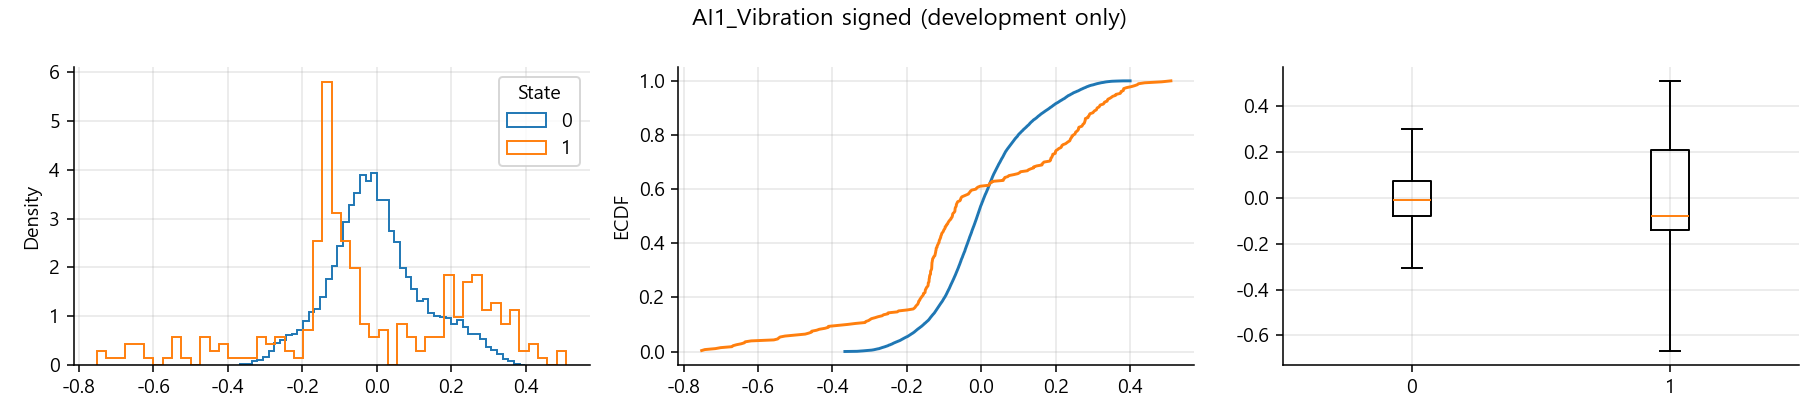

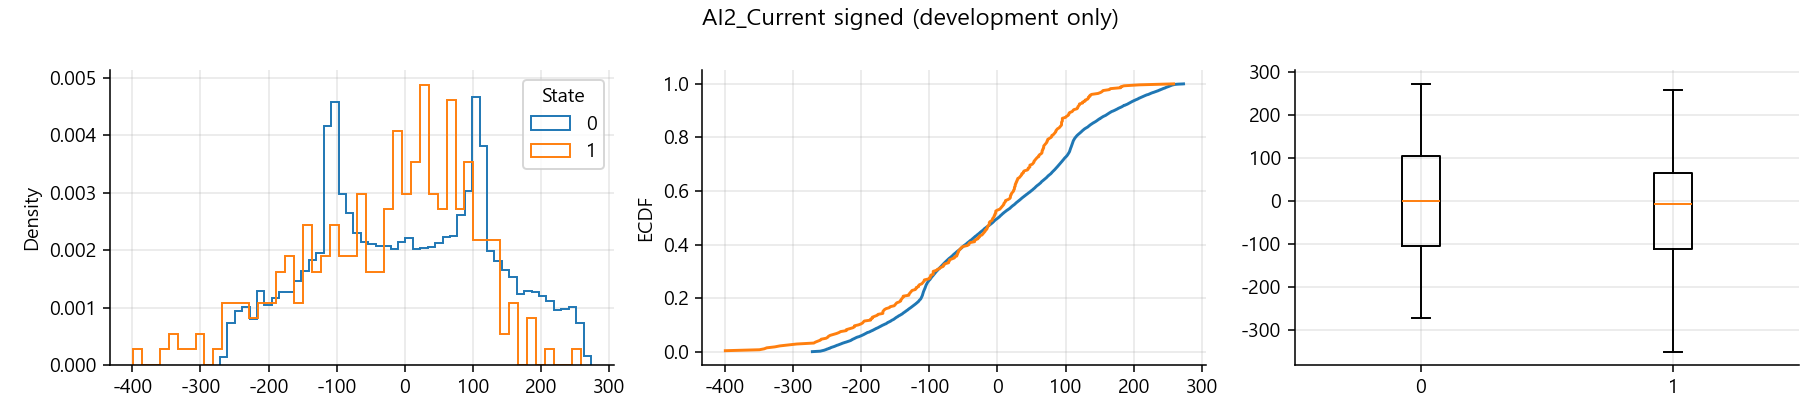

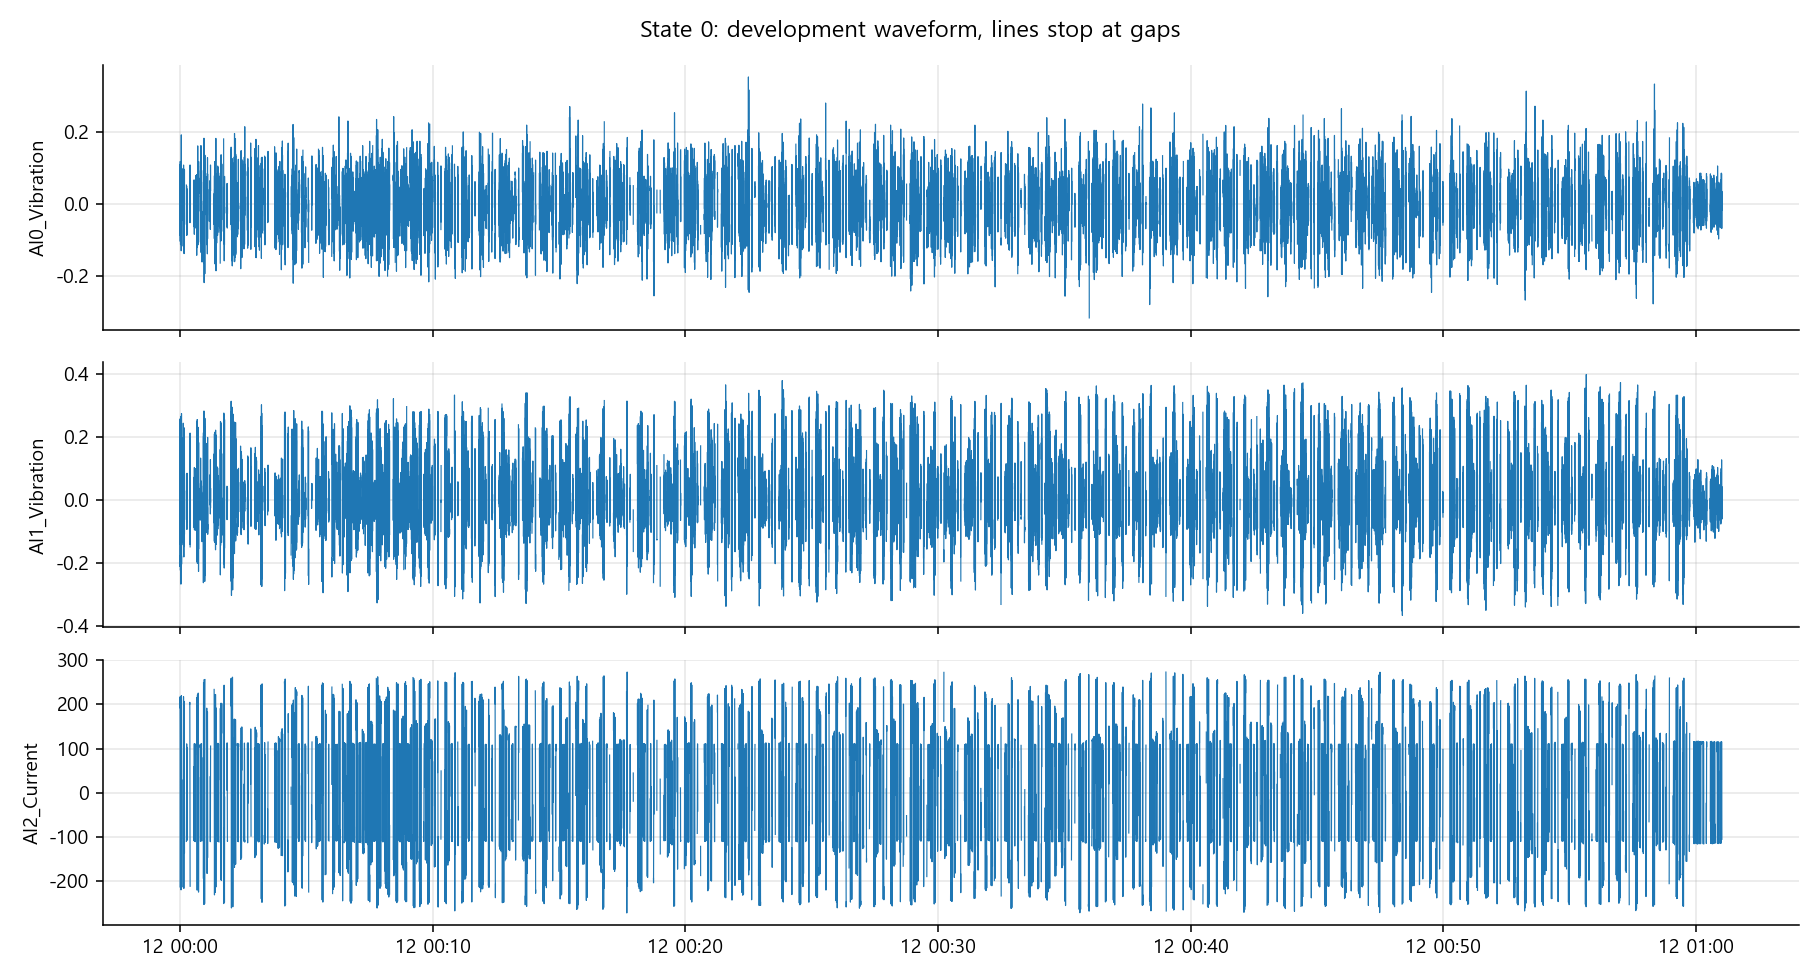

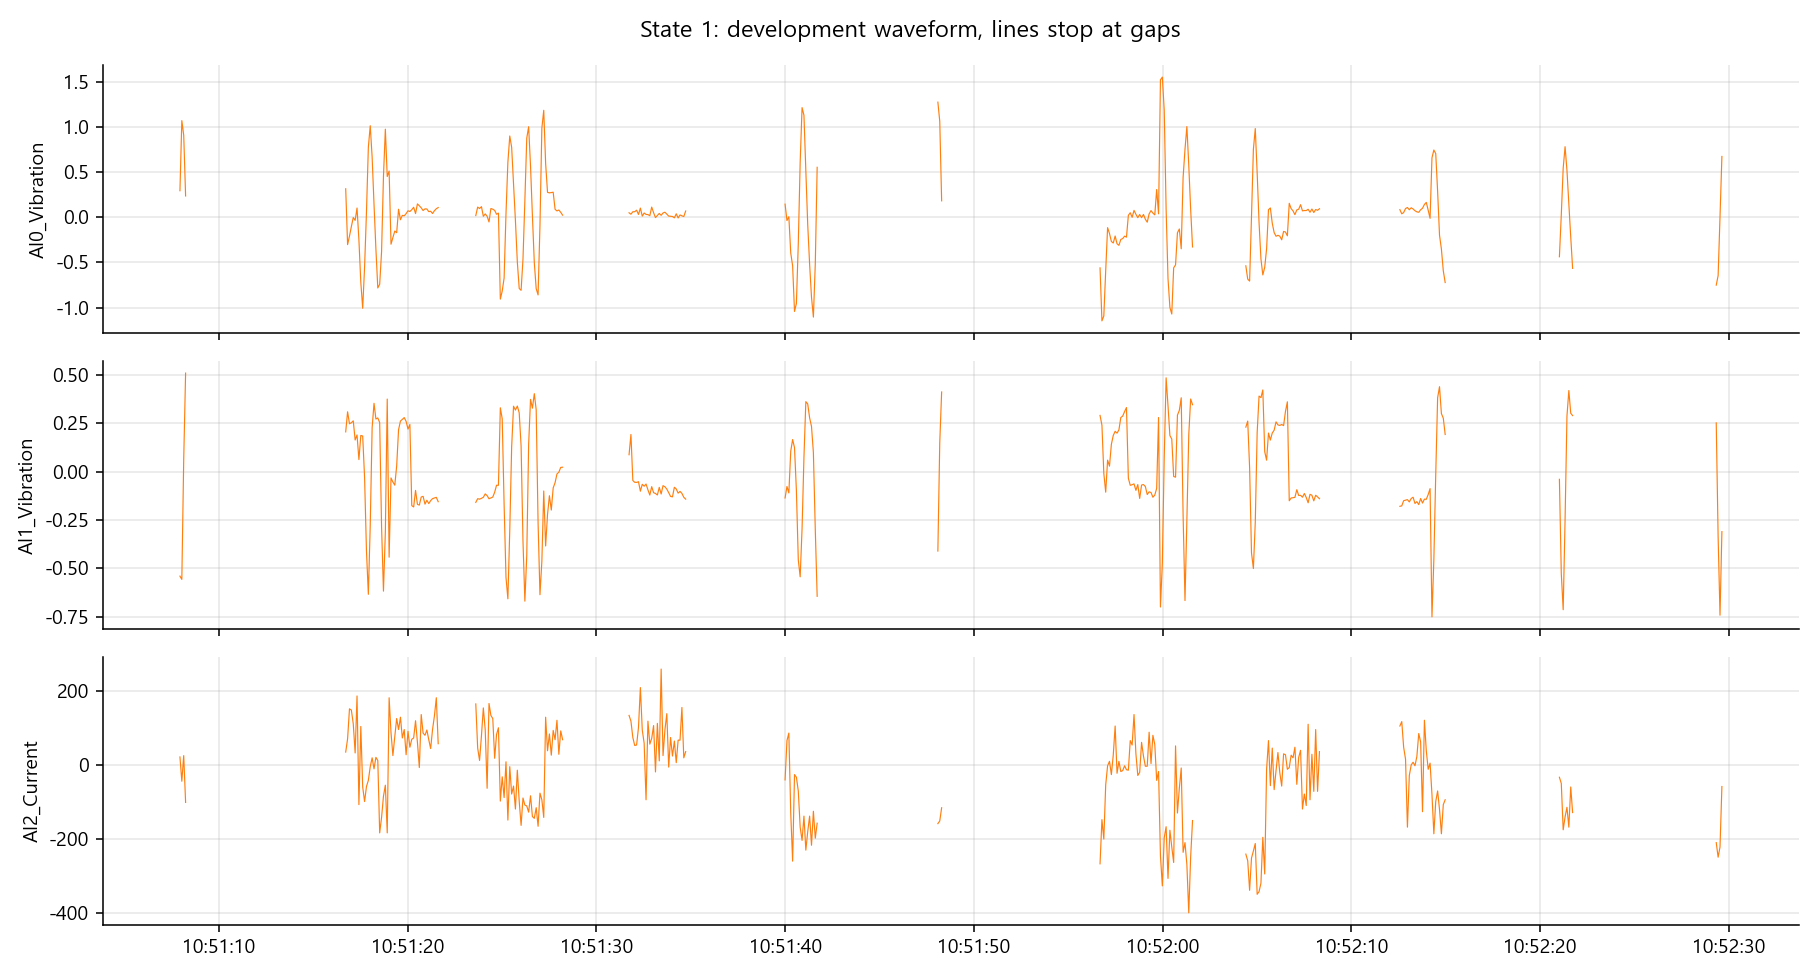

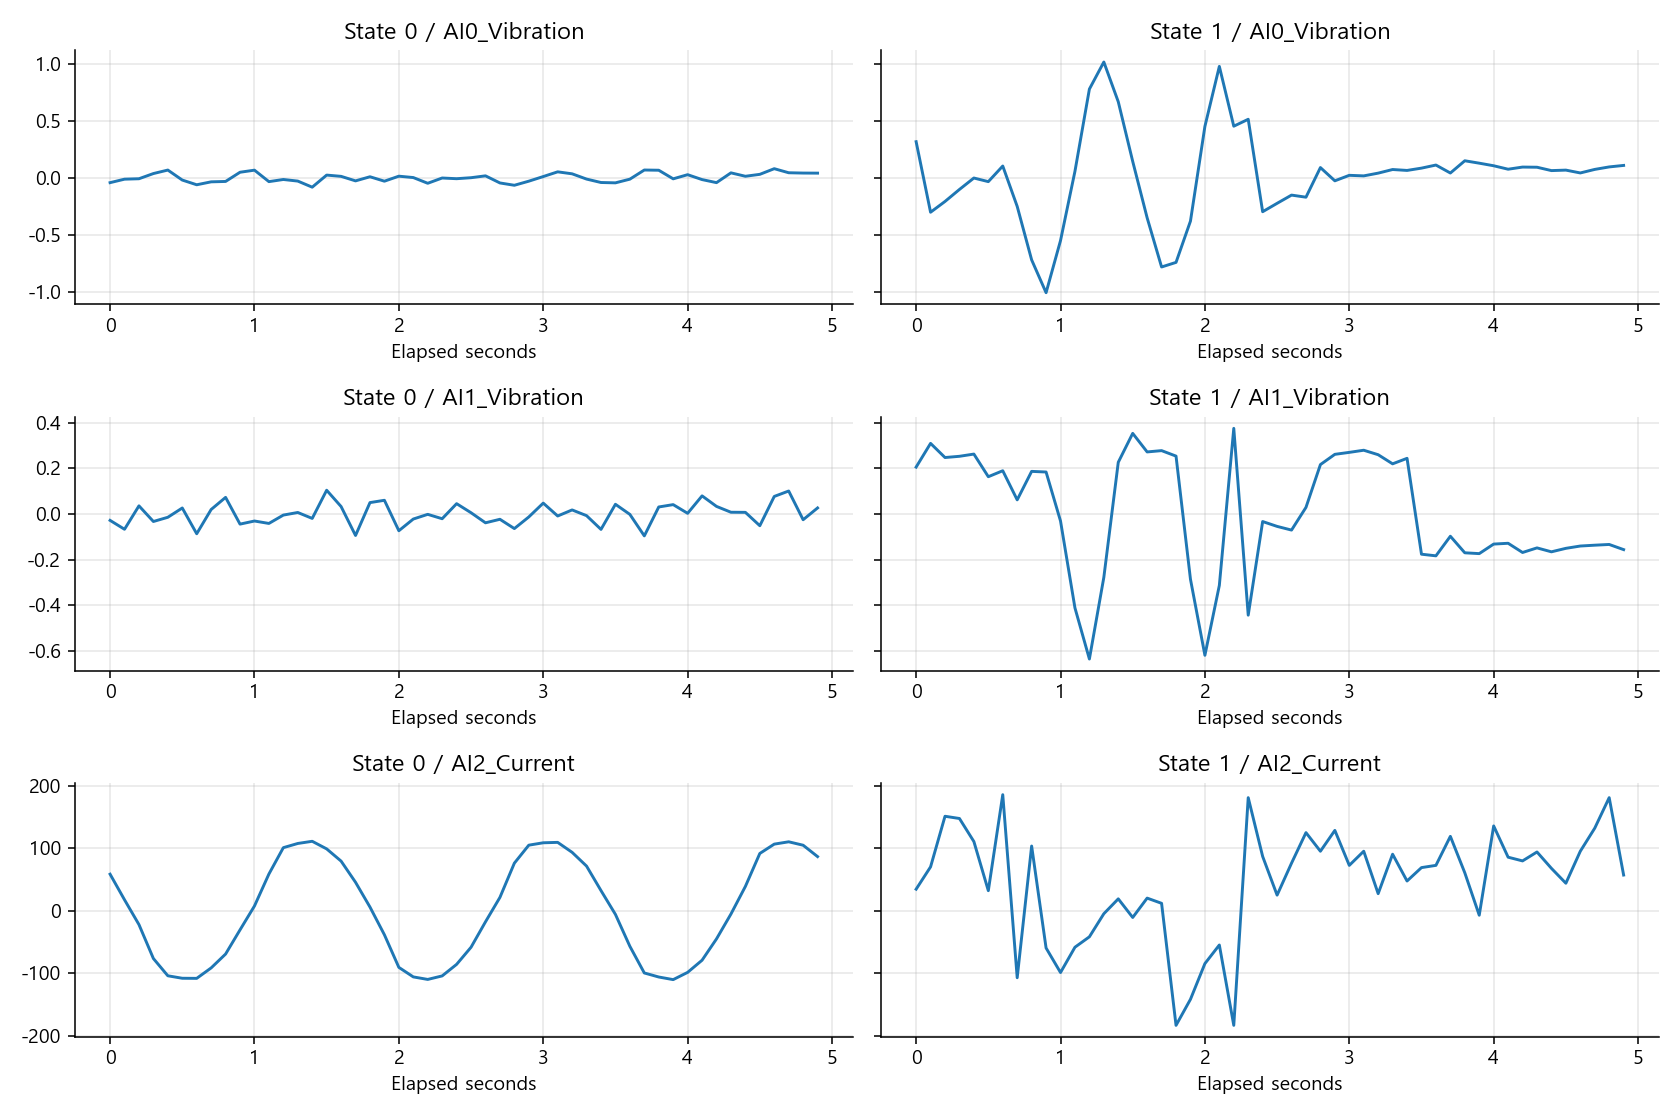

In [25]:
for sensor in SENSORS:
    display(Image(filename=str(FIG / f'{sensor}_signed.png')))
for name in ['development_waveform_0', 'development_waveform_1', 'development_zoom_shared_scale']:
    display(Image(filename=str(FIG / f'{name}.png')))

### 08-2 센서 간 상관

두 센서가 함께 움직이는 정도(스피어만 상관)입니다. 1에 가까우면 같이 커지고, −1에 가까우면 반대로 움직입니다.

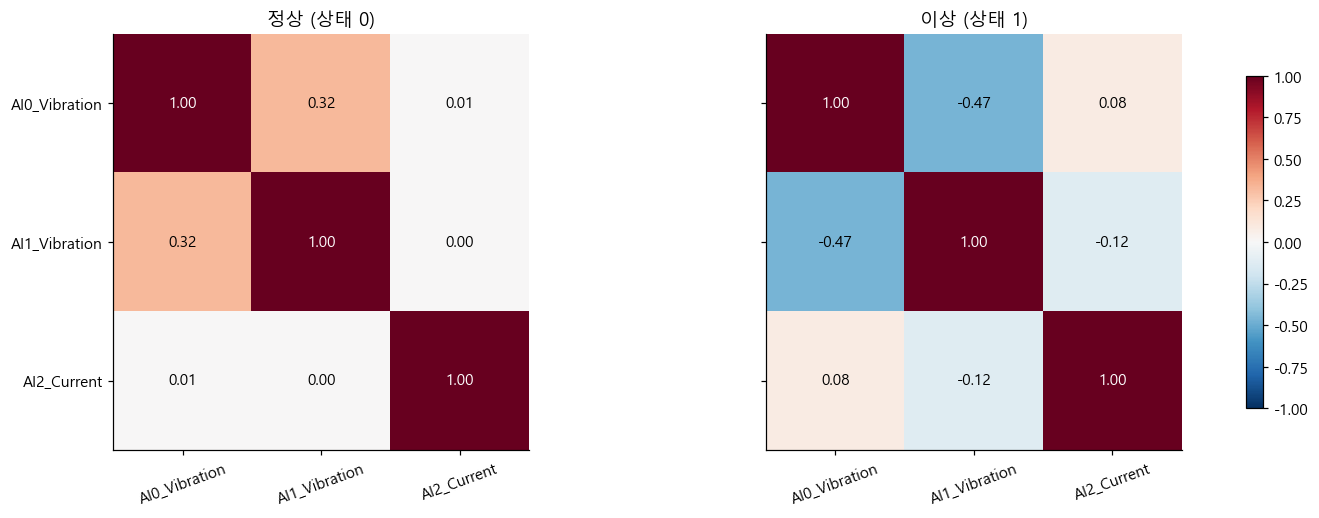

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for k, (ax, lab) in enumerate(zip(axes, (0, 1))):
    c = pd.read_csv(OUTPUT_DIR / f'development_correlation_{lab}_spearman.csv', index_col=0)
    im = ax.imshow(c.values, cmap='RdBu_r', vmin=-1, vmax=1)
    for (i, j), v in np.ndenumerate(c.values):
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='white' if abs(v) > .6 else 'black')
    ax.set_xticks(range(len(c)), c.columns, rotation=20)
    ax.set_yticks(range(len(c)), c.index if k == 0 else [''] * len(c))
    ax.set_title(f'{LAB[lab]} (상태 {lab})'); ax.grid(False)
fig.colorbar(im, ax=axes, shrink=.8)
show('08_2_correlation', '센서 간 스피어만 상관')

### 08-3 RMS·P2P 특징과 FFT/PSD

W20 윈도의 RMS(평균 세기)·P2P(최대-최소 폭) 분포, 그리고 W20·W50 윈도의 주파수 스펙트럼입니다.
W20의 주파수 칸 간격은 0.5 Hz, W50은 0.2 Hz입니다. 선은 구간별 중앙값, 띠는 25–75% 범위입니다.

**그래프 읽는 법**

- **RMS–P2P 산점도 (각 특징 그림의 오른쪽)**: 점 하나가 윈도 하나입니다. RMS는 평균 세기, P2P는 최댓값과 최솟값의 차이입니다. 파형 모양이 일정하면 둘이 비례해서 정상 점들이 **한 줄의 띠**를 이룹니다. 이상 점이 띠에서 벗어나면 세기가 아니라 **파형 모양**이 바뀐 것입니다. 가로로 늘어선 주황 점들은 같은 구간에서 한 칸씩 민 윈도들입니다. 큰 튐 하나가 윈도 안에 머무는 동안 P2P는 그대로이고 RMS만 변해서 생깁니다.
- **스펙트럼 범례 `State 0; 165 segments`**: State 0은 정상, State 1은 이상입니다. 숫자는 그 선을 그리는 데 쓴 **구간 수**입니다. 이 그림은 Train+Valid만 쓰고, N=50 윈도는 끊김 없이 50행 이상 이어진 구간에서만 나옵니다. 이상 데이터에는 그런 구간이 2개뿐이라 **W50 이상 스펙트럼은 근거가 약합니다.** W20 그림을 주로 보세요. 08-4의 표 1에 윈도 길이별 구간 수가 있습니다.

**AI0_Vibration**

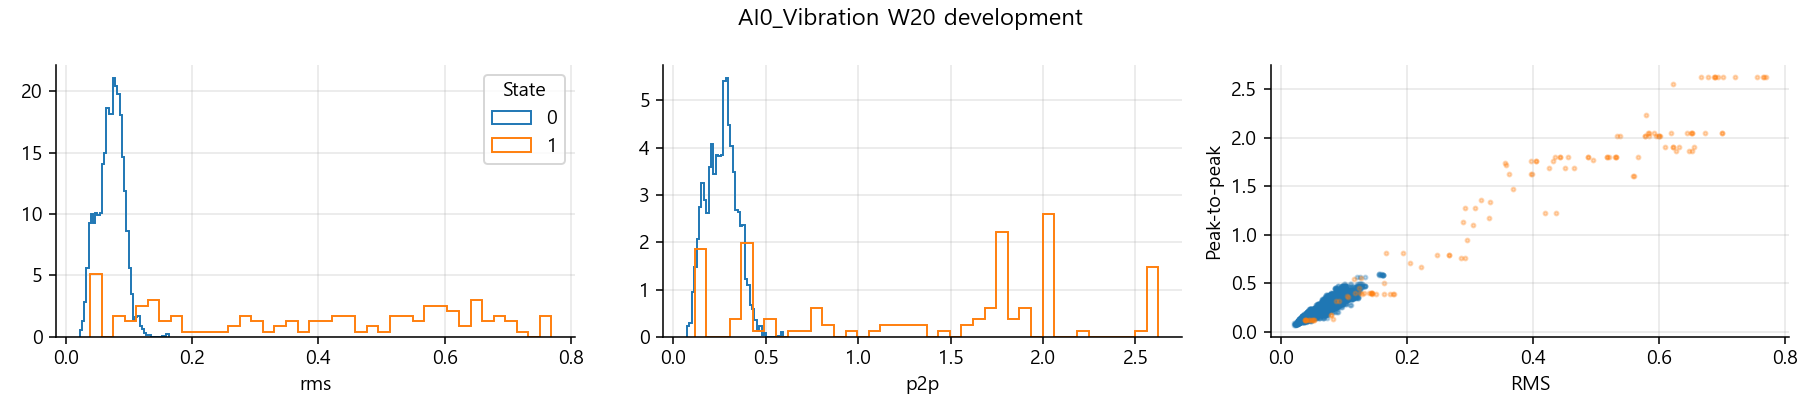

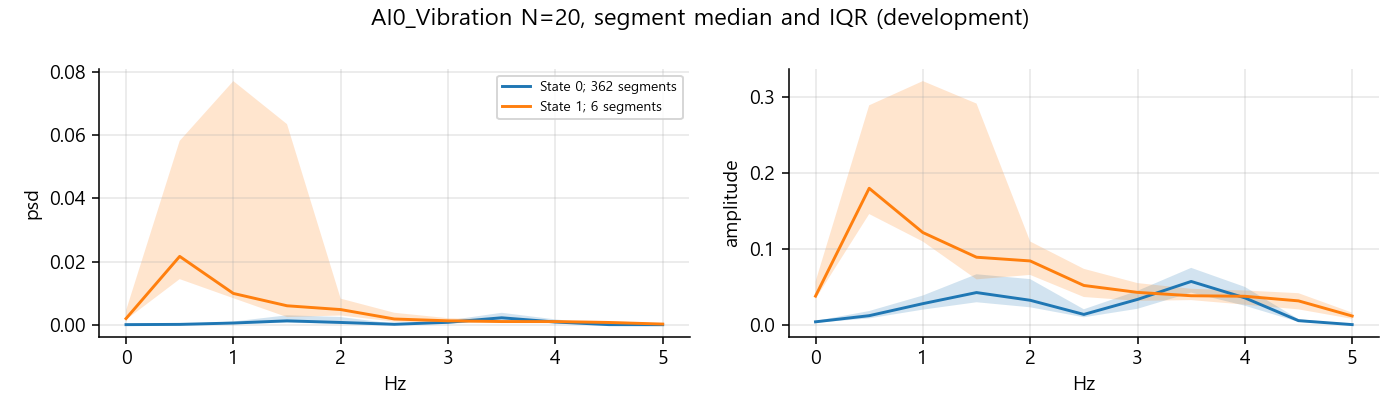

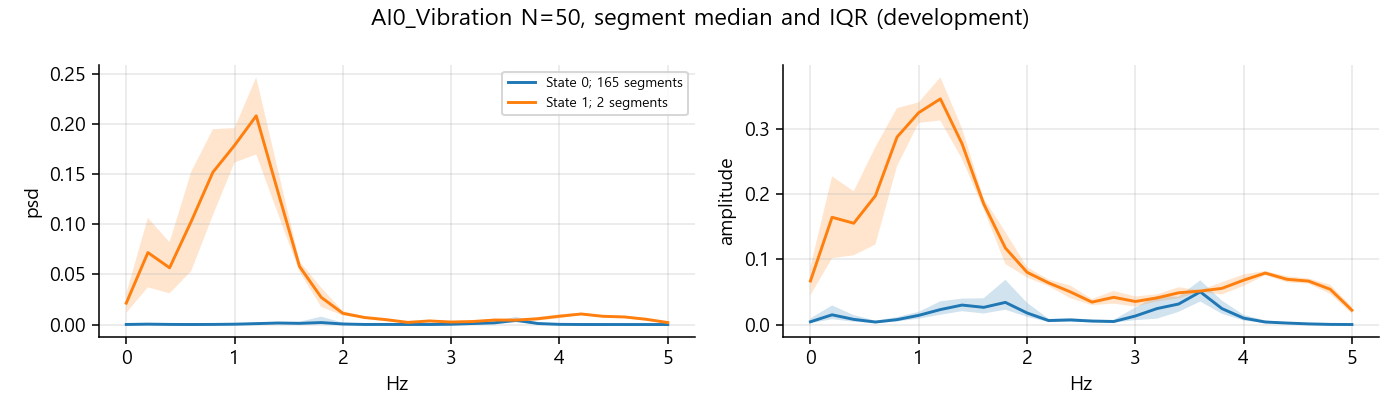

**AI1_Vibration**

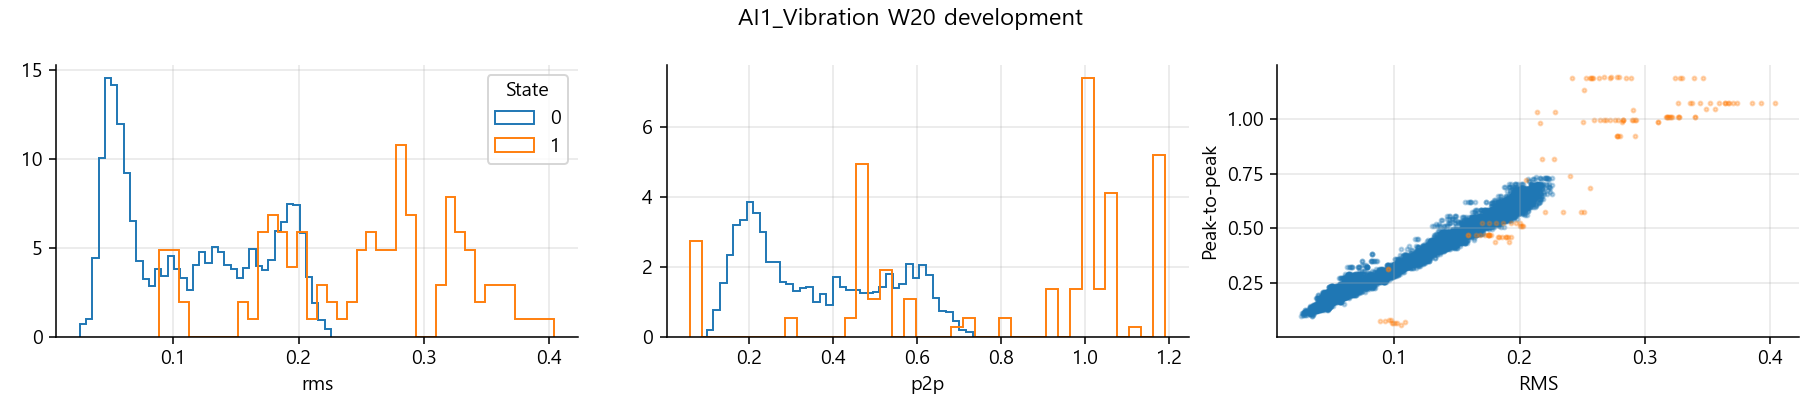

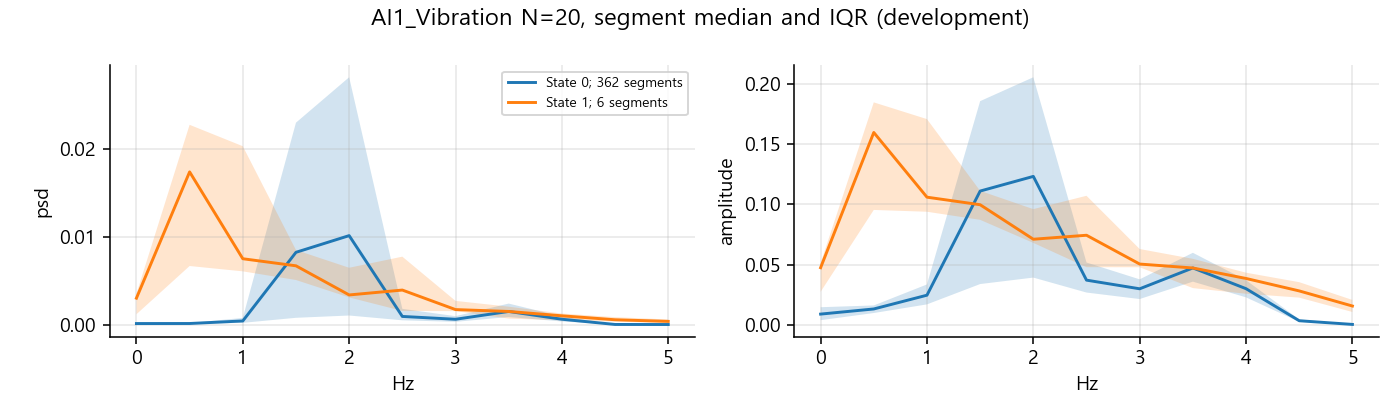

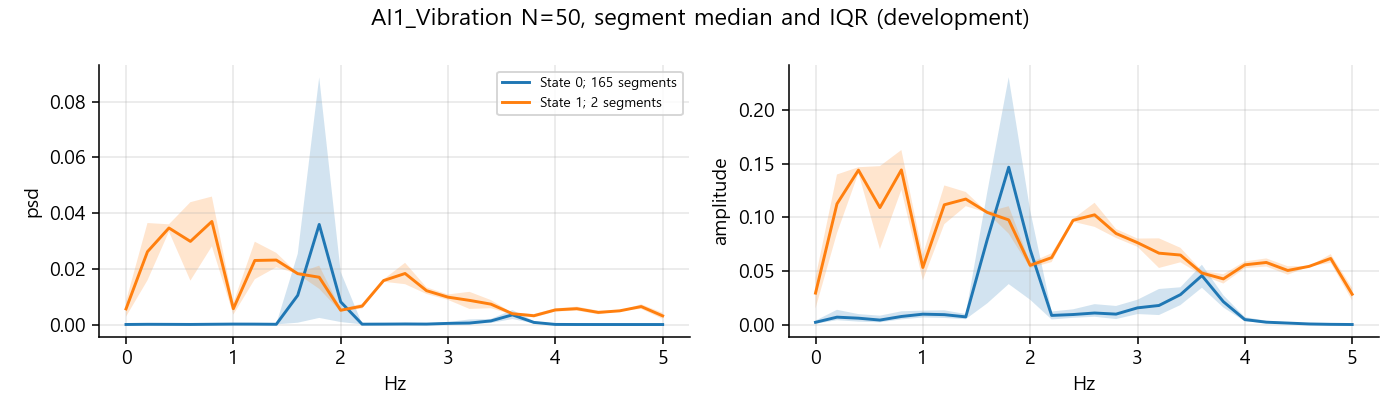

**AI2_Current**

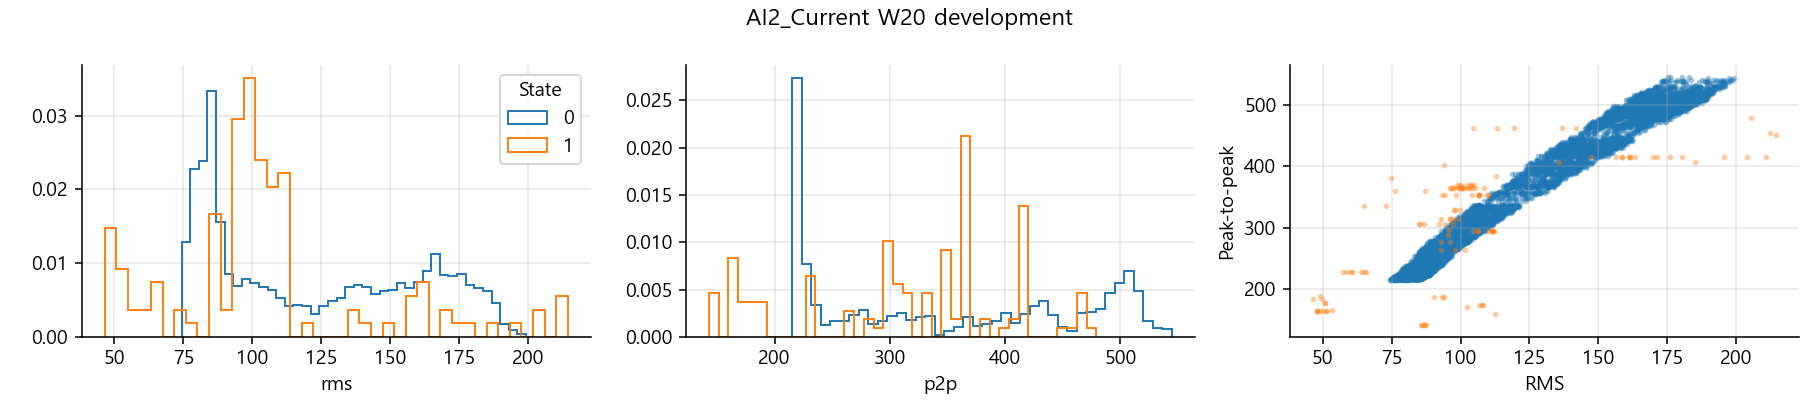

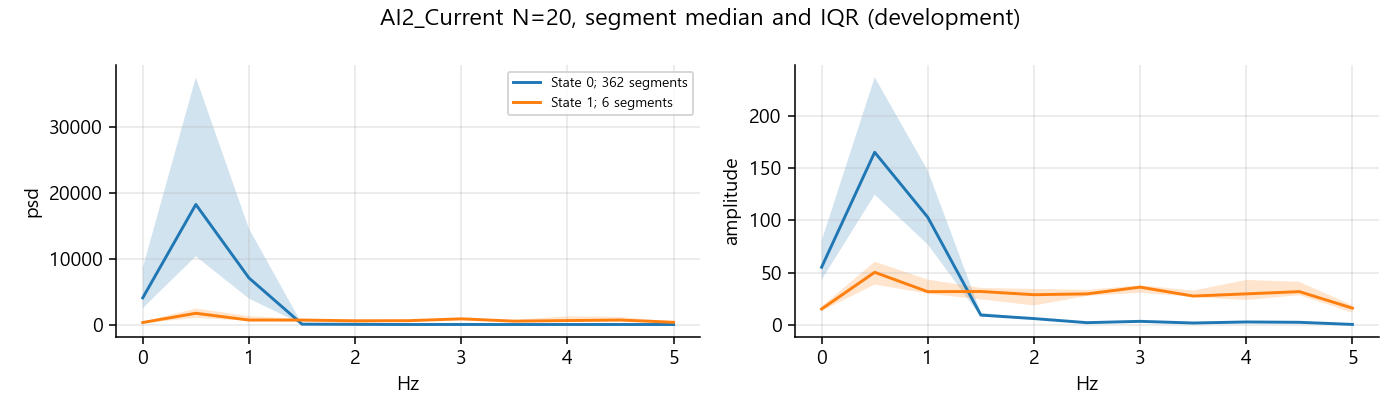

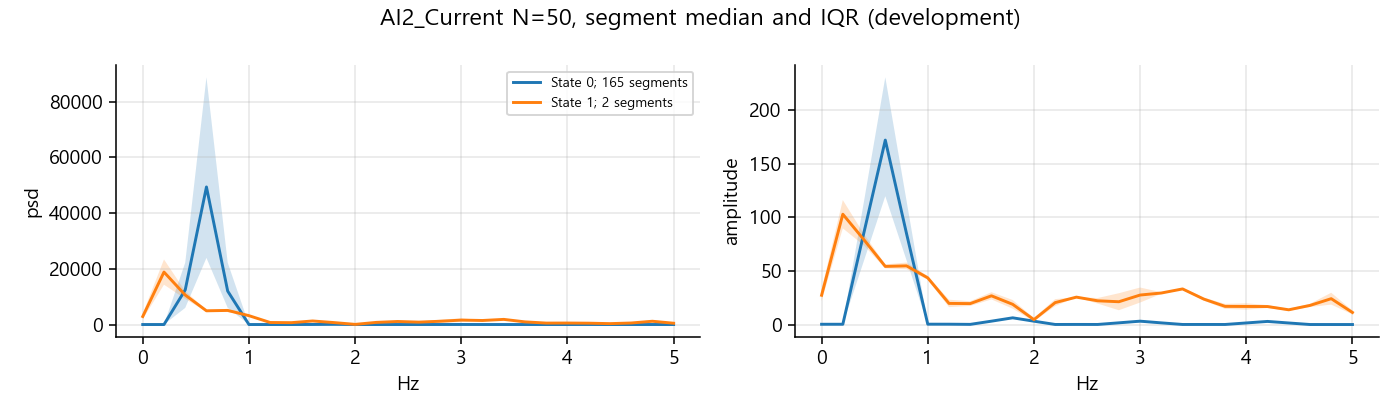

In [27]:
for sensor in SENSORS:
    display(Markdown(f'**{sensor}**'))
    for name in [f'{sensor}_features', f'{sensor}_spectrum_20', f'{sensor}_spectrum_50']:
        display(Image(filename=str(FIG / f'{name}.png')))

### 08-4 스펙트럼 범례의 구간 수와 RMS–P2P 띠

**표 1**: 스펙트럼 범례 숫자의 출처입니다. Train+Valid에서 윈도 길이 W 이상으로 끊김 없이 이어진 구간 수입니다.

**표 2와 그래프**: 정상 Train의 RMS–P2P 관계를 직선으로 맞춘 뒤, 직선(띠)에서 벗어난 정도만으로 정상과 이상을 얼마나 가를 수 있는지 Valid에서 잽니다.
구분력(AUC)은 0.5면 못 가르고 1이면 완벽하게 가릅니다. Test는 쓰지 않습니다.

,W16,W20,W30,W50
정상 (State 0),379,362,287,165
이상 (State 1),7,6,5,2


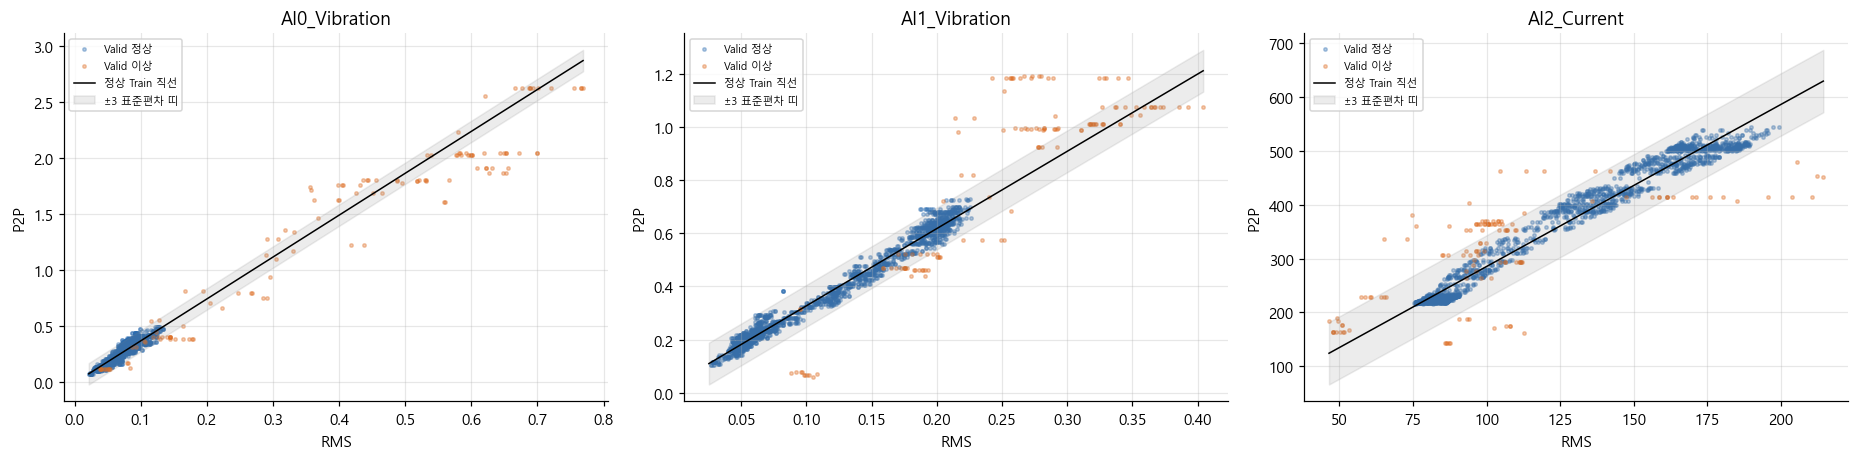

,RMS만,P2P만,띠에서 벗어난 정도
센서,,,
AI0_Vibration,0.912,0.875,0.917
AI1_Vibration,0.889,0.823,0.910
AI2_Current,0.584,0.598,0.921


In [28]:
from sklearn.metrics import roc_auc_score
dev_seg = segments[segments.split != 'test']
SEG_CNT = pd.DataFrame({f'W{w}': [int(((dev_seg.label == l) & (dev_seg.n_rows >= w)).sum()) for l in (0, 1)]
                        for w in CONFIG.windows}, index=['정상 (State 0)', '이상 (State 1)'])
display(SEG_CNT.style.set_caption('표 1. Train+Valid에서 W행 이상 이어진 구간 수 (= 스펙트럼 범례 숫자)'))

fw20 = windows[windows.window == 20]
tr, va = fw20[fw20.split == 'train'], fw20[fw20.split == 'valid']


def sep_auc(v):
    a = roc_auc_score(va.label, v)
    return max(a, 1 - a)


band_rows = []
fig, axes = plt.subplots(1, len(SENSORS), figsize=(17, 4.3))
for ax, s in zip(axes, SENSORS):
    coef = np.polyfit(tr[s + '__rms'], tr[s + '__p2p'], 1)
    sd = (tr[s + '__p2p'] - np.polyval(coef, tr[s + '__rms'])).std()
    resid = (va[s + '__p2p'] - np.polyval(coef, va[s + '__rms'])).abs() / sd
    band_rows.append({'센서': s, 'RMS만': sep_auc(va[s + '__rms']), 'P2P만': sep_auc(va[s + '__p2p']),
                      '띠에서 벗어난 정도': sep_auc(resid)})
    for lab in (0, 1):
        g = va[va.label == lab]
        ax.scatter(g[s + '__rms'], g[s + '__p2p'], s=5, alpha=.35, color=COL[lab], label=f'Valid {LAB[lab]}')
    dev_rms = pd.concat([tr, va])[s + '__rms']
    xs = np.linspace(dev_rms.min(), dev_rms.max(), 50)
    ax.plot(xs, np.polyval(coef, xs), color='black', lw=1, label='정상 Train 직선')
    ax.fill_between(xs, np.polyval(coef, xs) - 3 * sd, np.polyval(coef, xs) + 3 * sd, color='gray', alpha=.15,
                    label='±3 표준편차 띠')
    ax.set(title=s, xlabel='RMS', ylabel='P2P'); ax.legend(fontsize=7)
plt.tight_layout(); show('08_4_rms_p2p_band', 'RMS–P2P 정상 띠와 Valid 점 (띠에서 벗어나면 파형 모양이 바뀐 것)')
BAND_AUC = pd.DataFrame(band_rows).set_index('센서')
display(BAND_AUC.style.format('{:.3f}').background_gradient(cmap='Greens', vmin=.5, vmax=1)
        .set_caption('표 2. Valid 구분력(AUC): 0.5 = 구분 못 함, 1 = 완벽'))

## 09 오류 사례와 보고서

Test에서 틀린 판정을 **오탐(FP, 정상을 이상으로)**과 **미탐(FN, 이상을 정상으로)**으로 나눠 셉니다. 이어서 실험별 대표 오류 파형과 보고서를 보여 줍니다.
오류를 보고 모델을 고쳤다면, 같은 Test를 다시 최종 검증으로 쓸 수 없습니다.

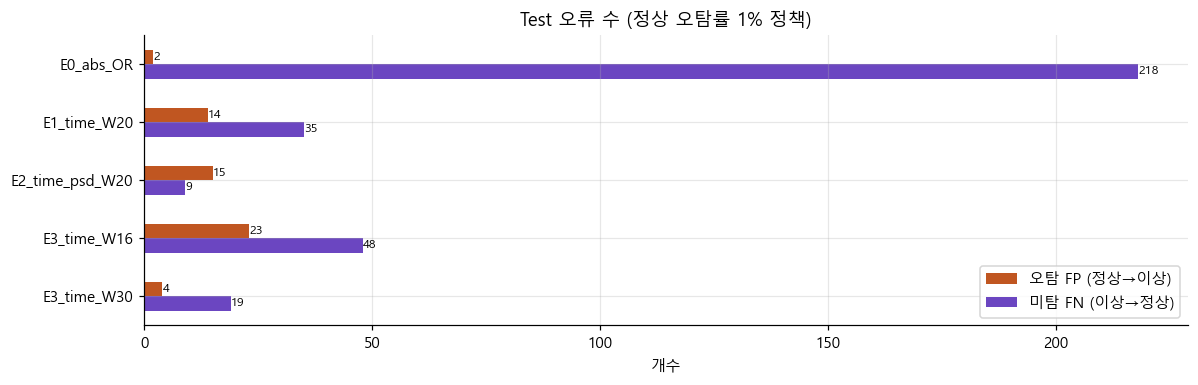

**E0_abs_OR — FP 대표 사례**

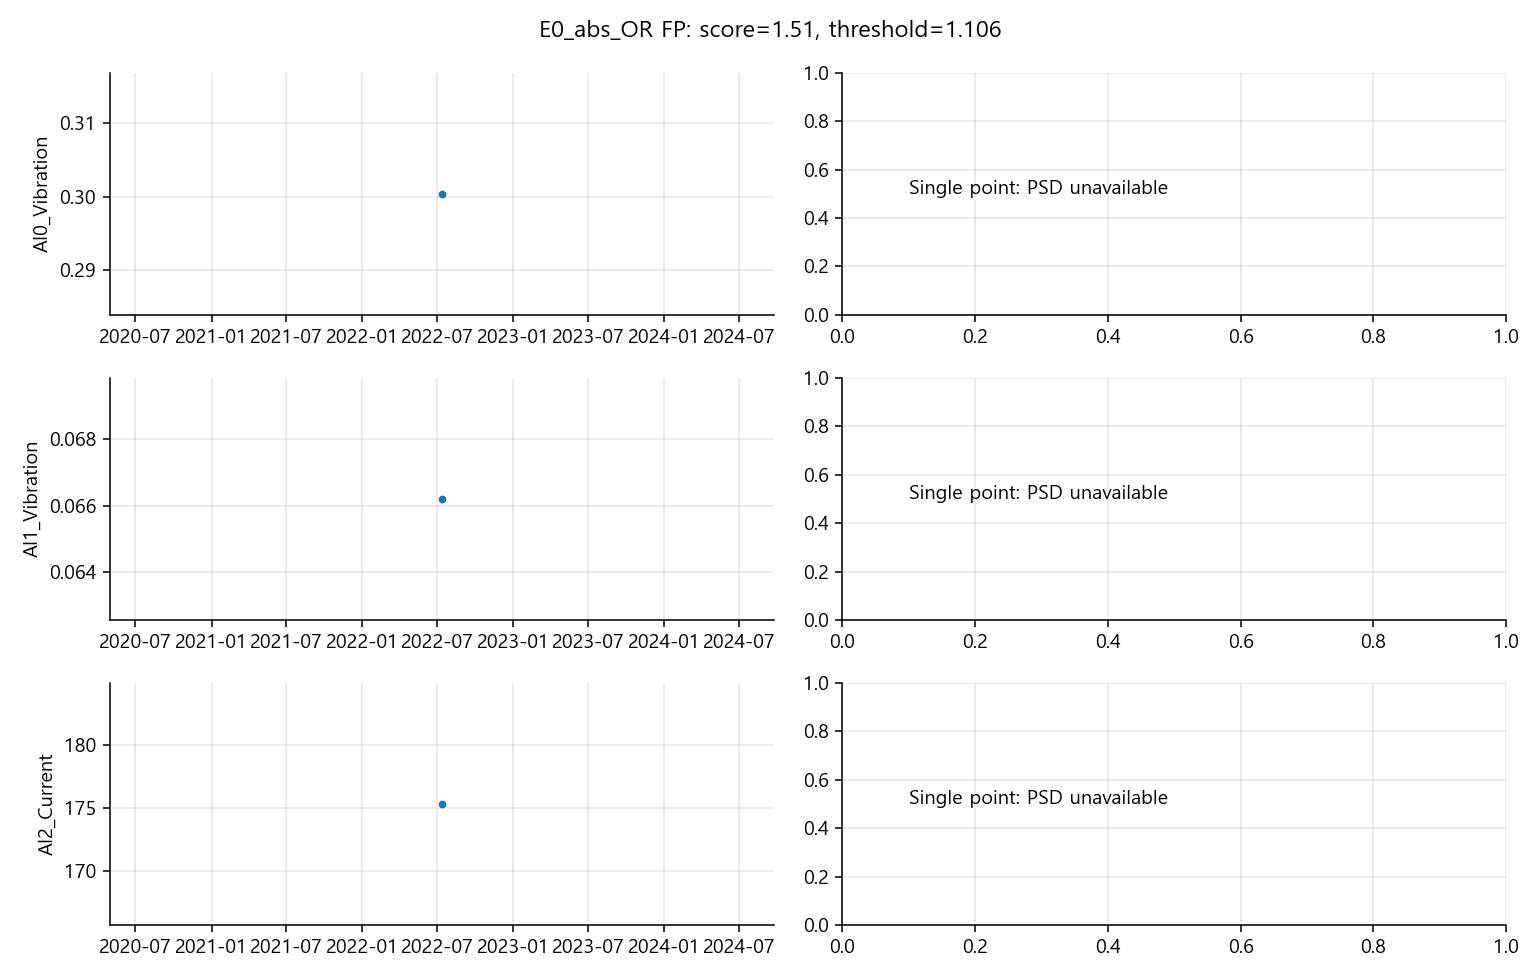

**E0_abs_OR — FN 대표 사례**

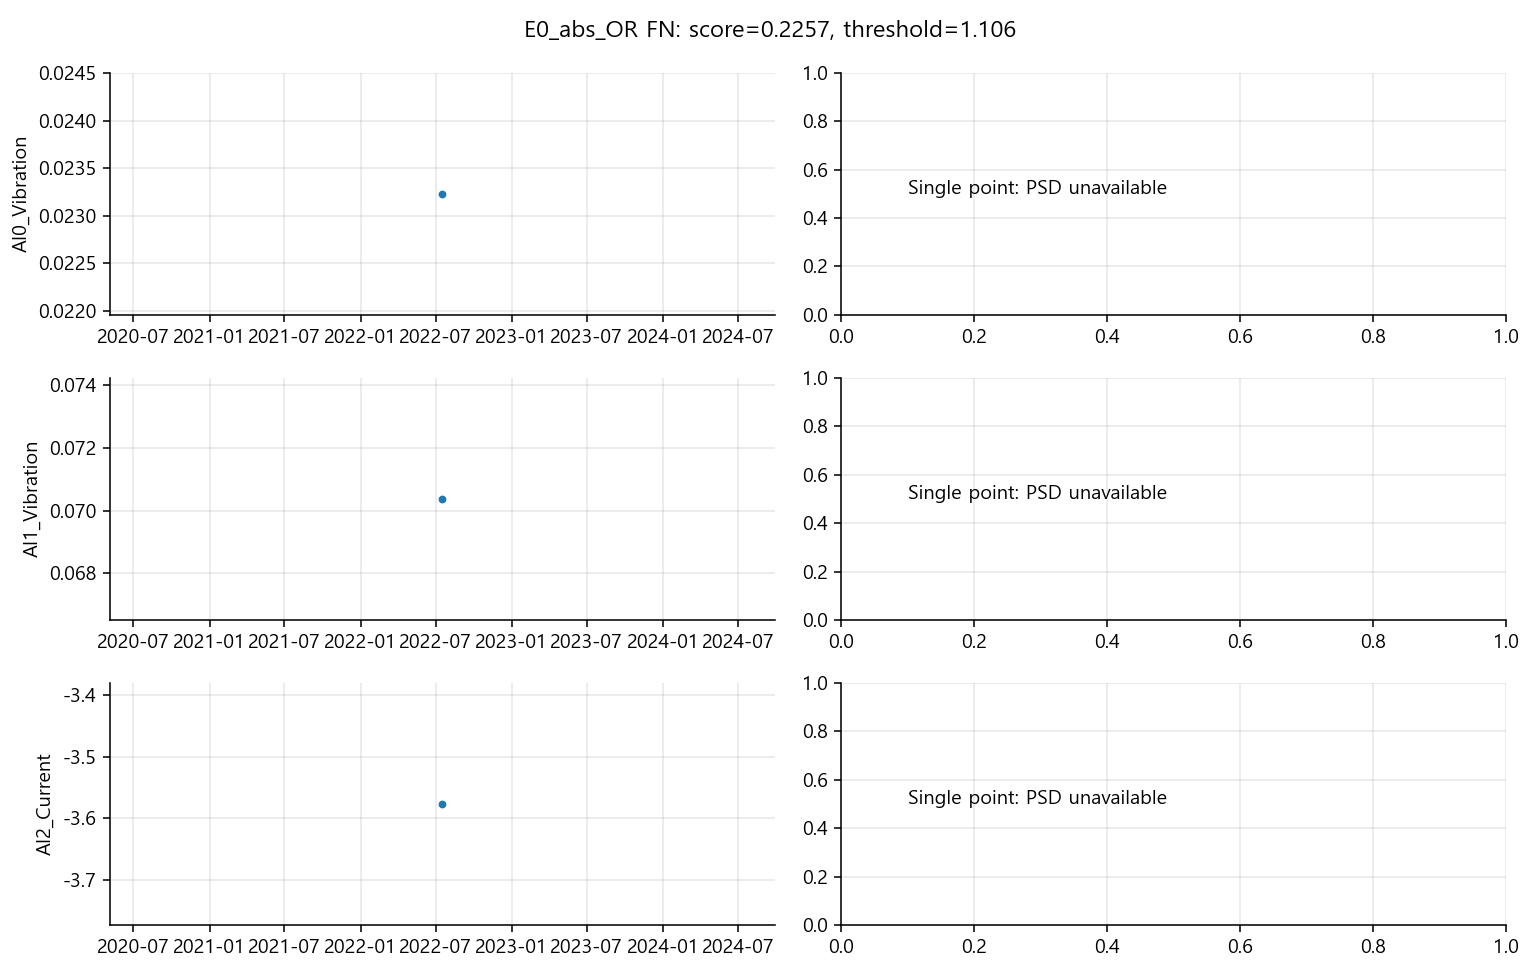

**E1_time_W20 — FP 대표 사례**

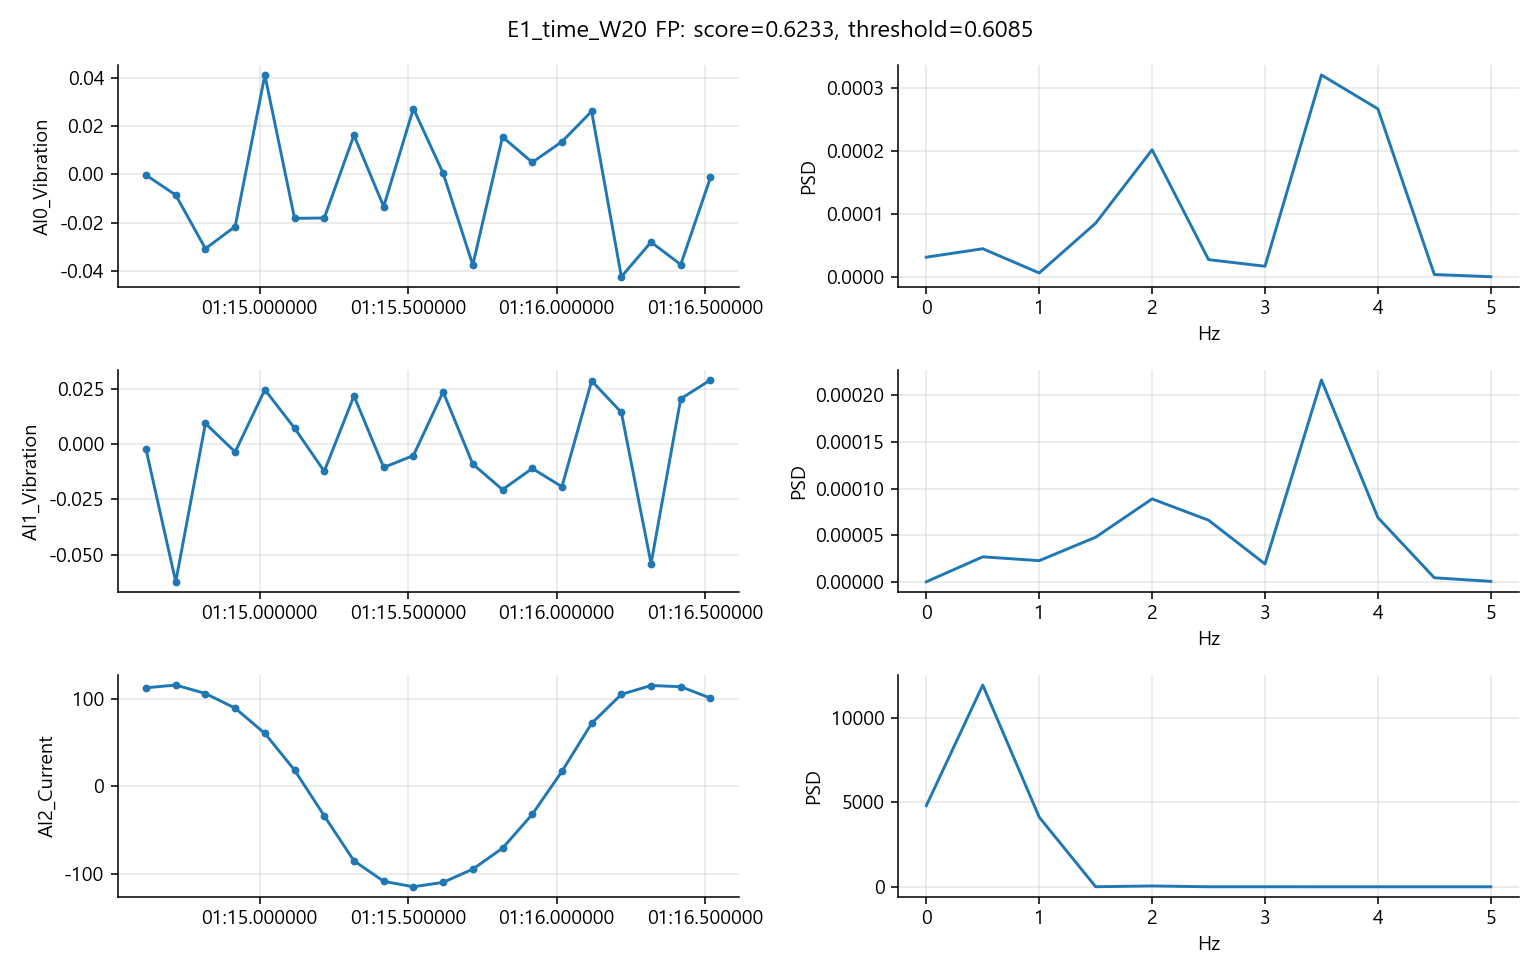

**E1_time_W20 — FN 대표 사례**

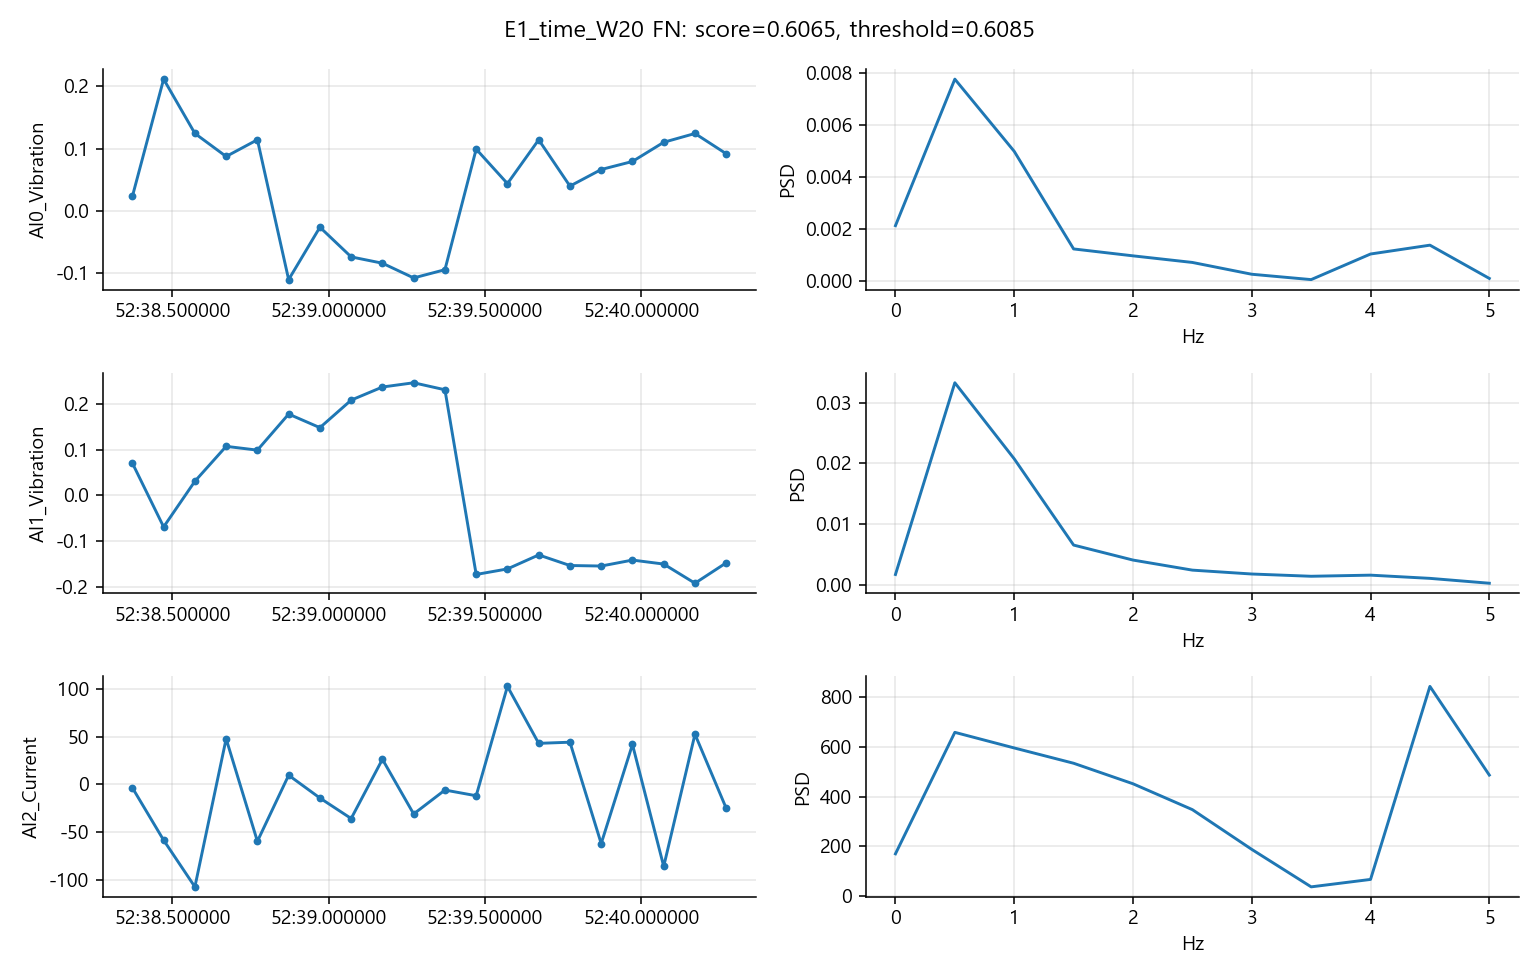

**E2_time_psd_W20 — FP 대표 사례**

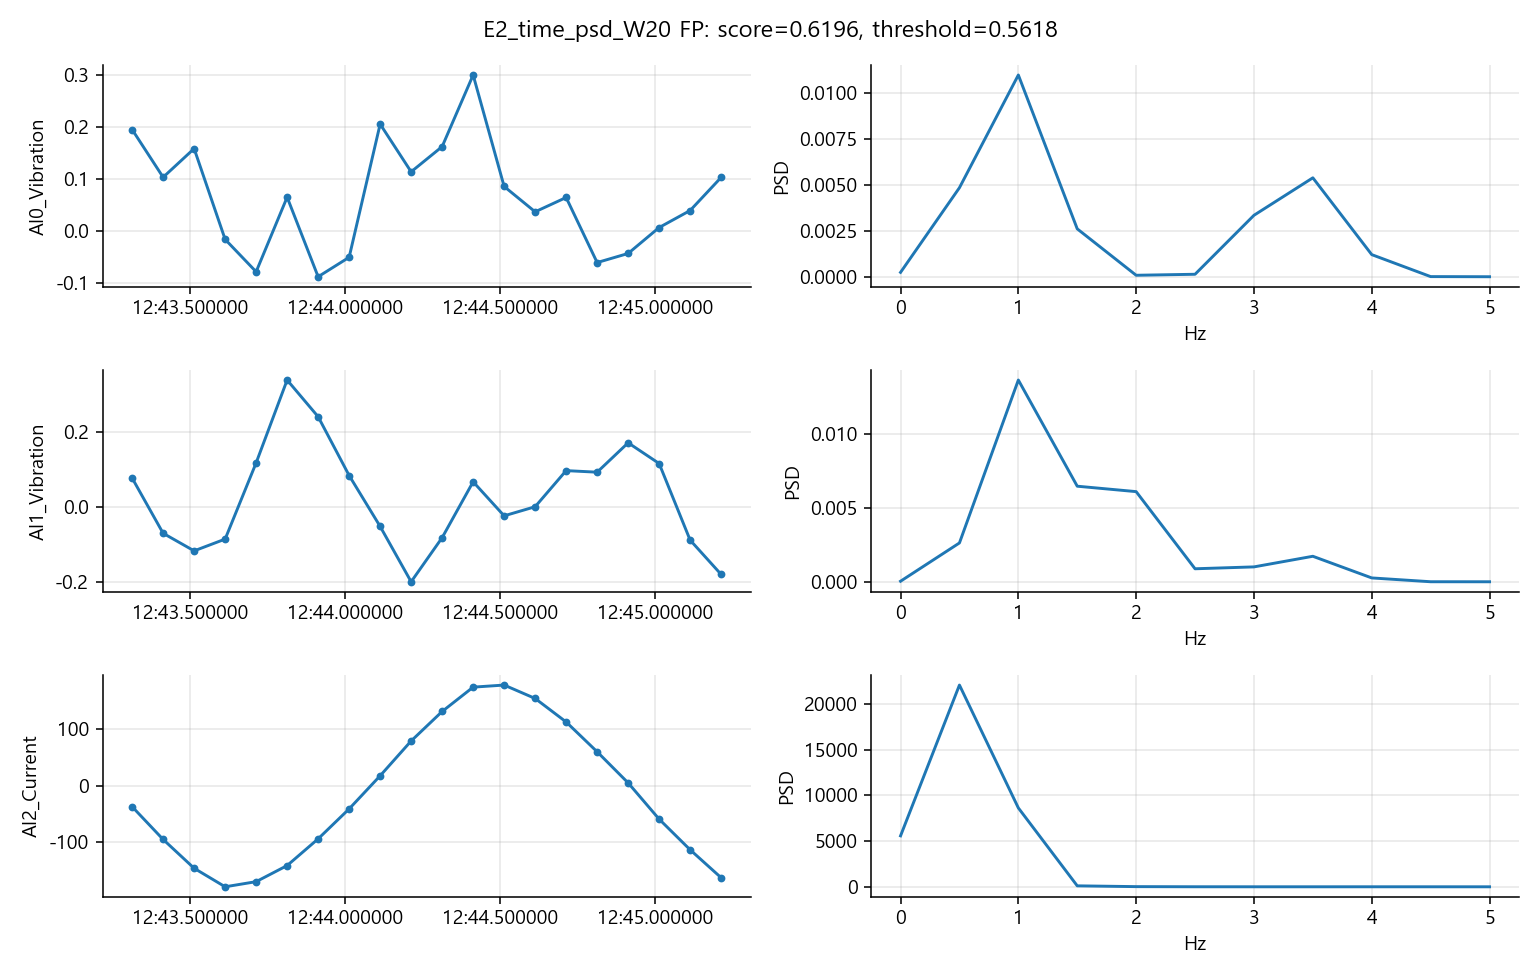

**E2_time_psd_W20 — FN 대표 사례**

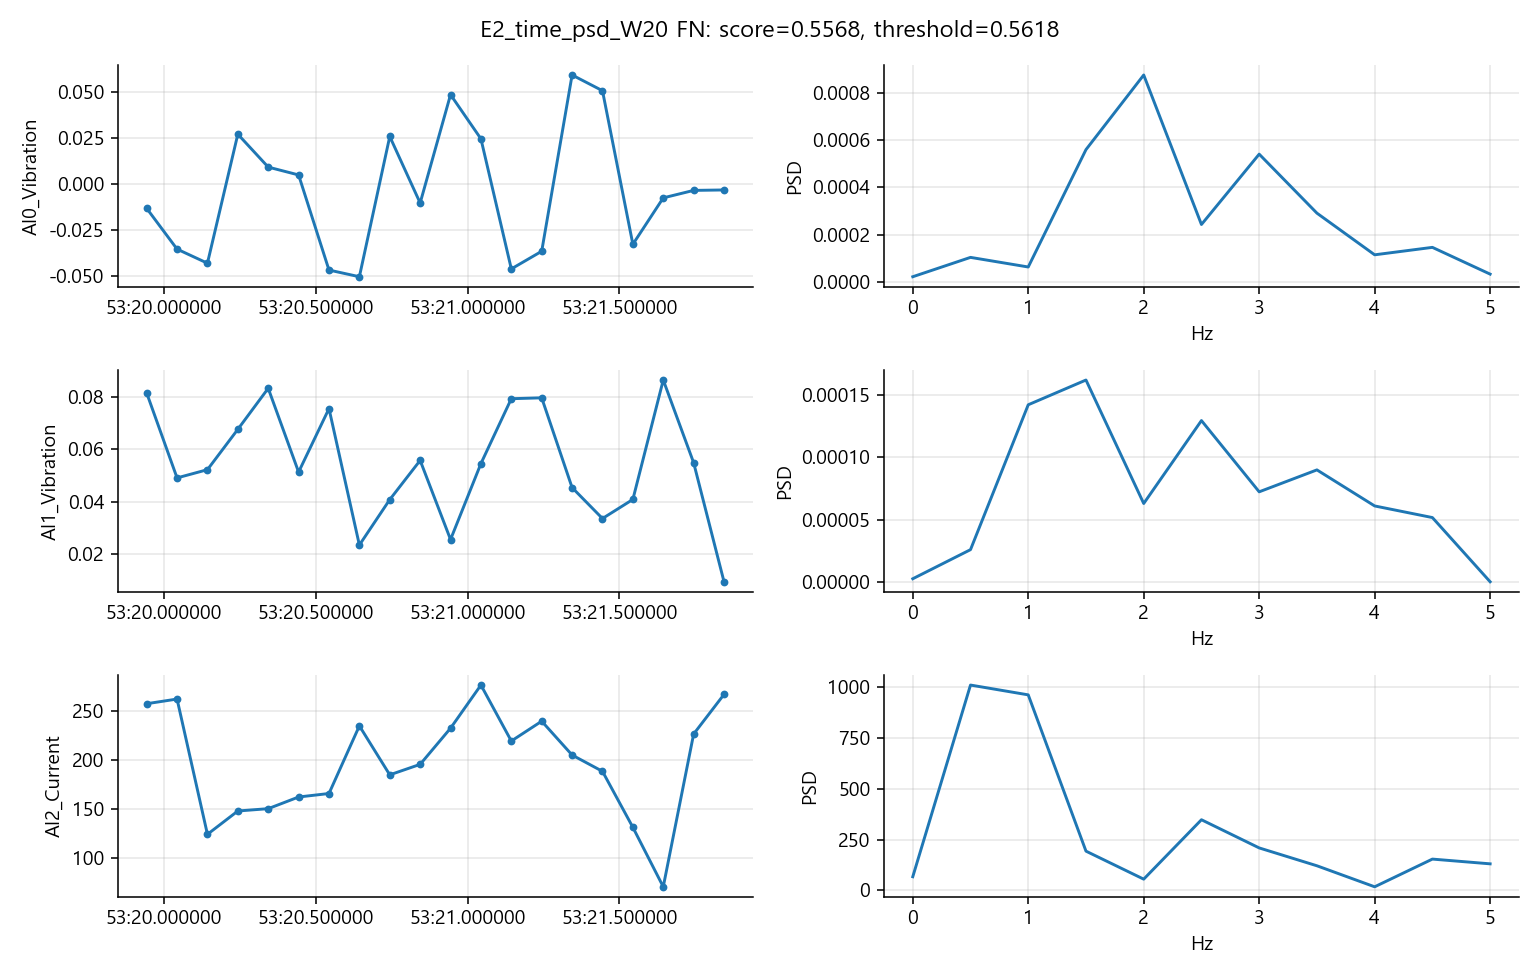

**E3_time_W16 — FP 대표 사례**

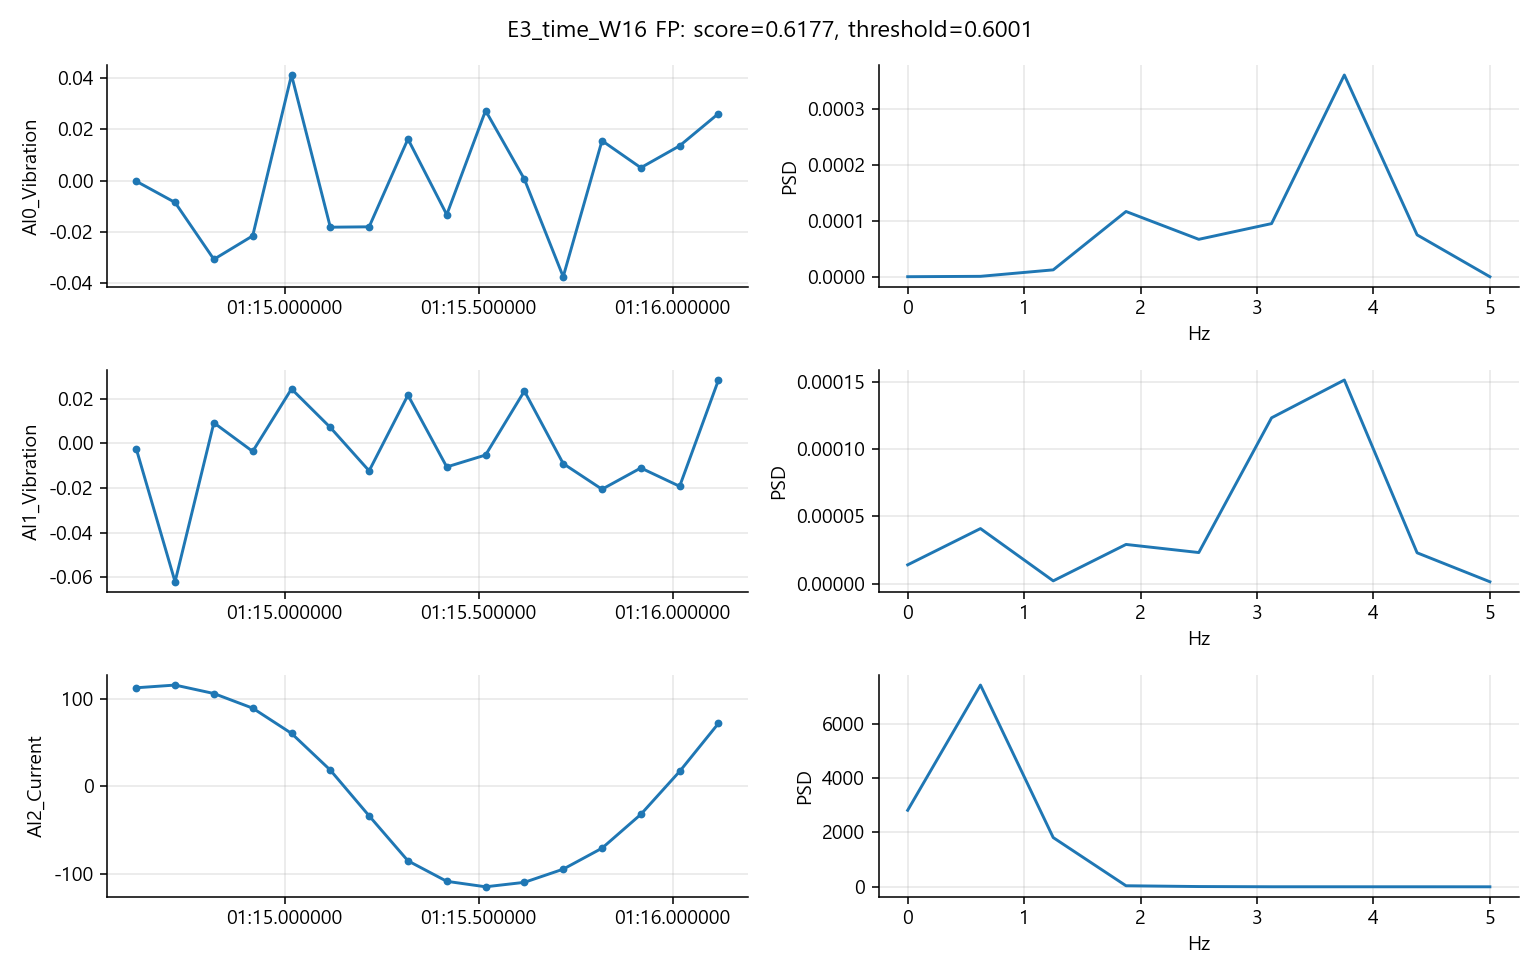

**E3_time_W16 — FN 대표 사례**

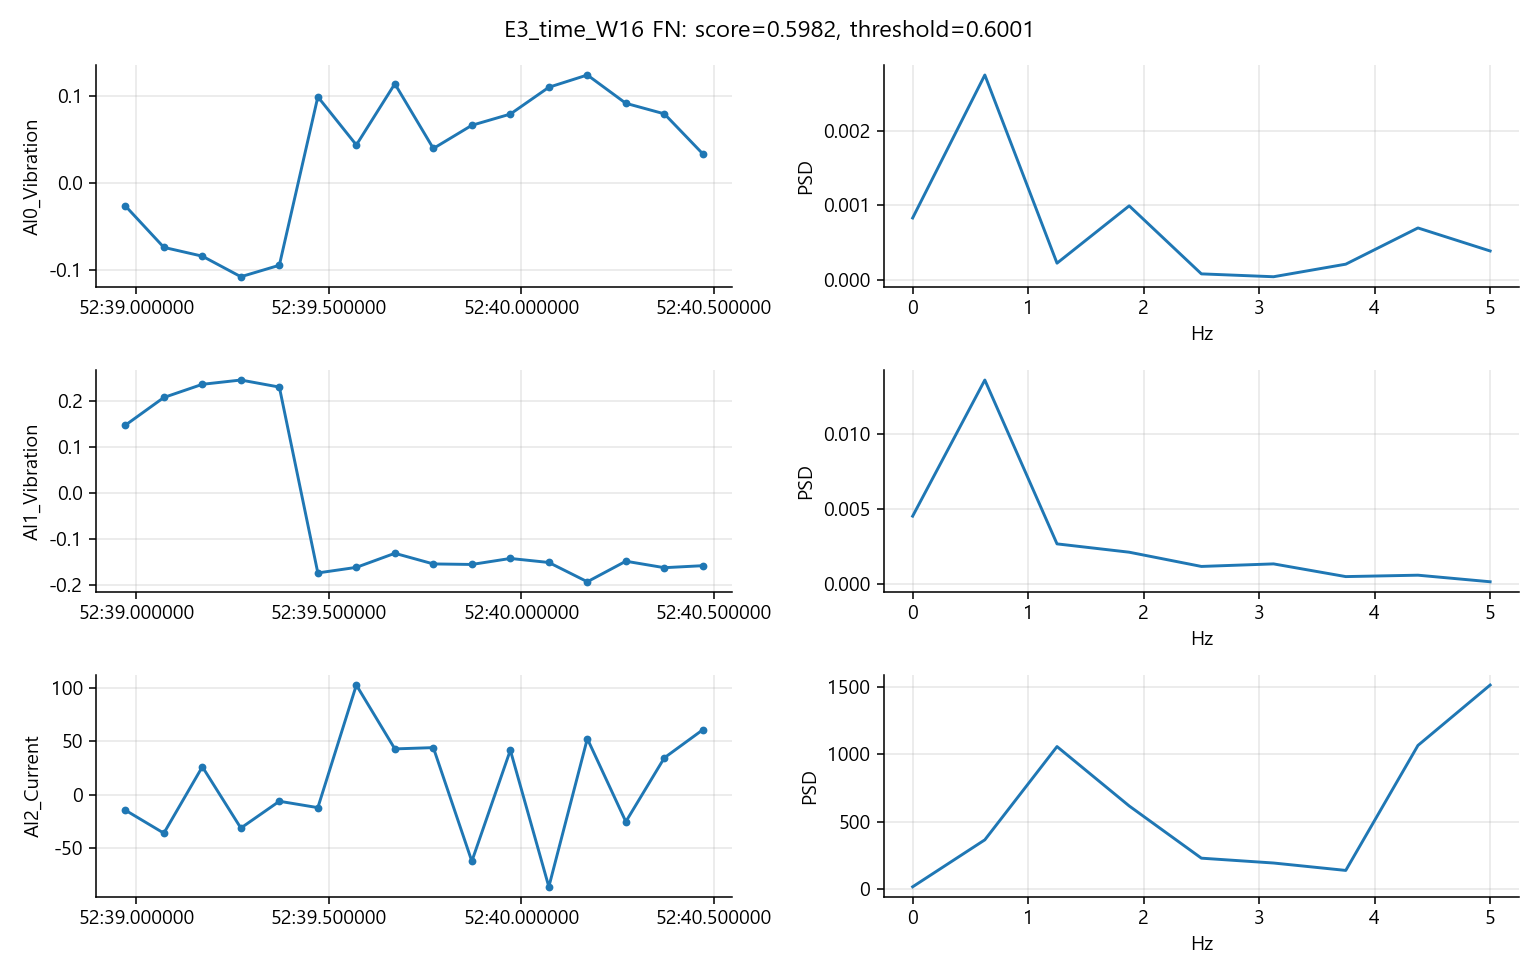

**E3_time_W30 — FP 대표 사례**

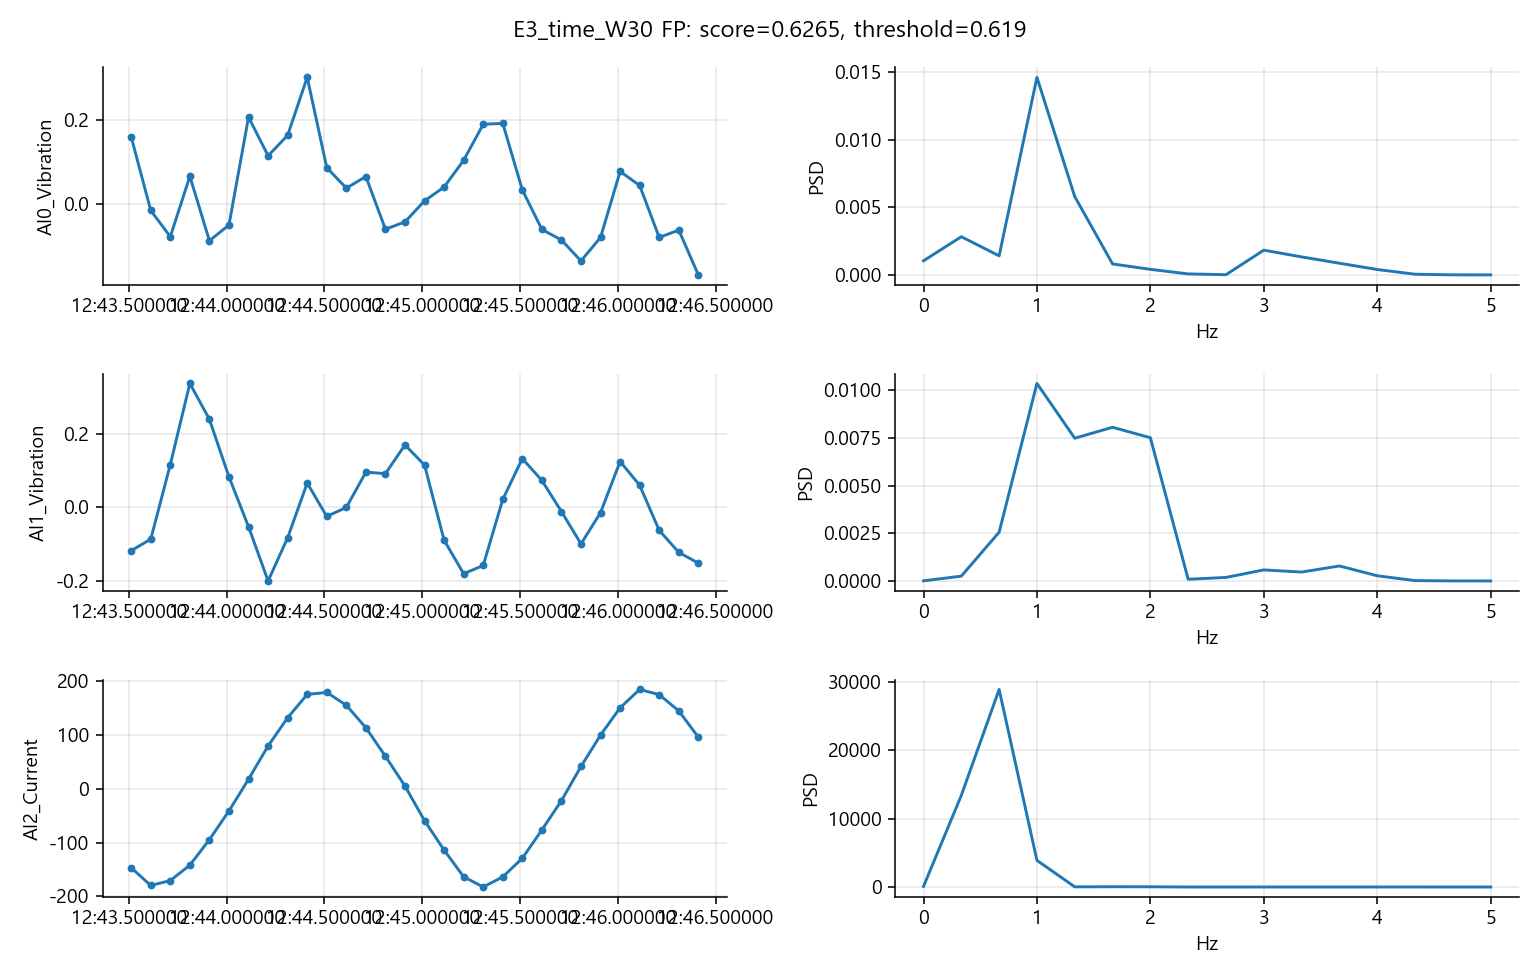

**E3_time_W30 — FN 대표 사례**

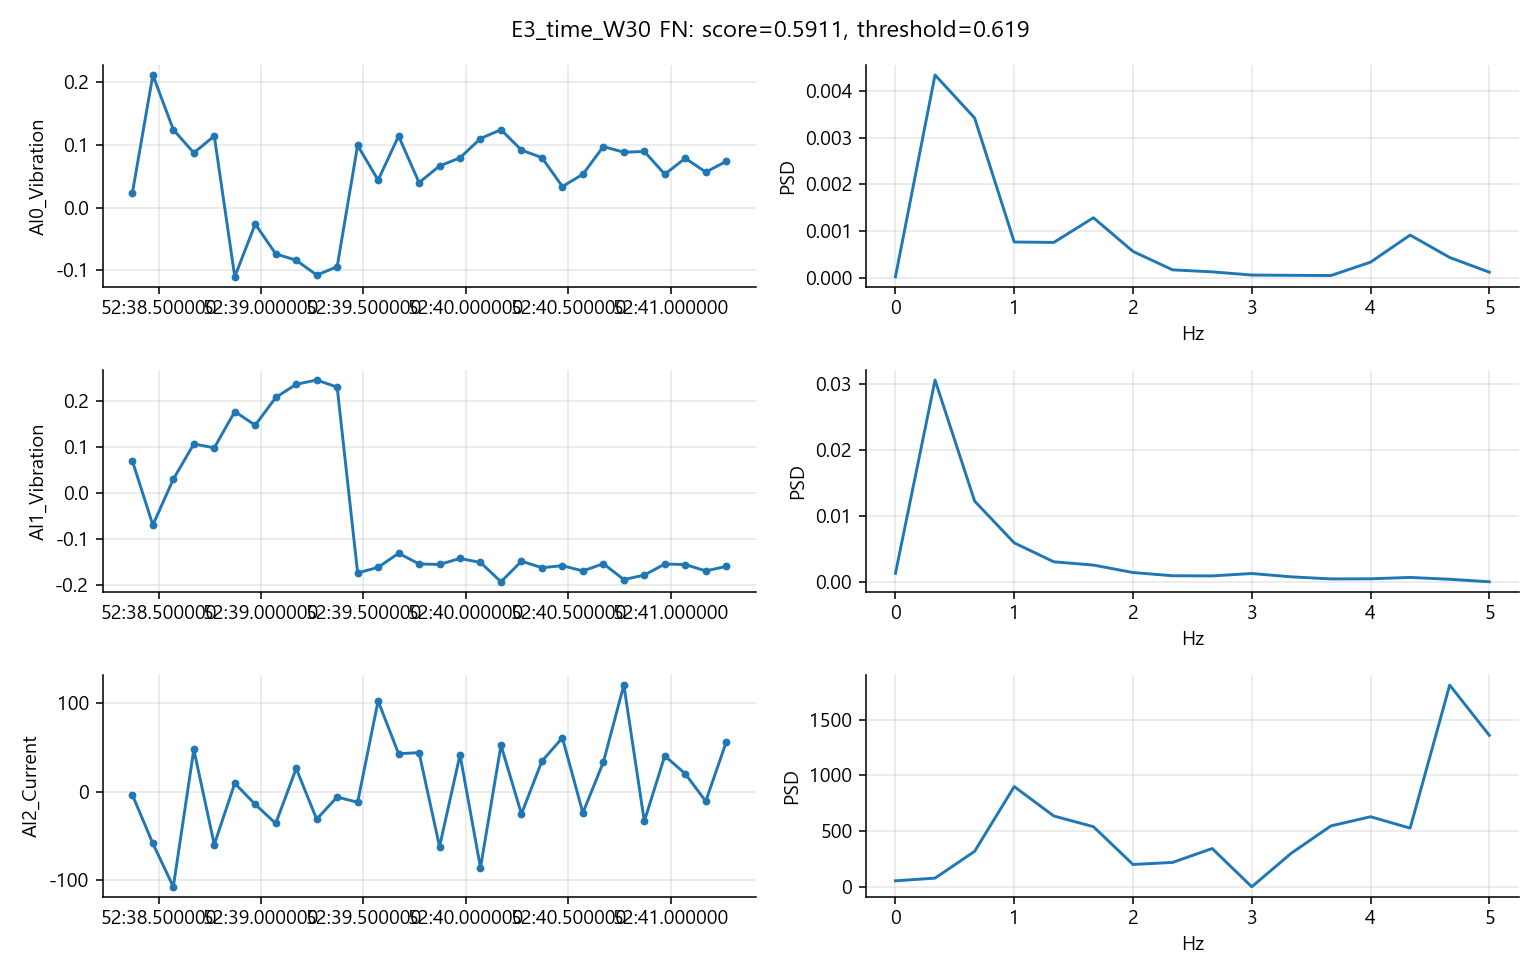

     experiment              scope       f1  normal_fpr
      E0_abs_OR                all 0.481132    0.000501
      E0_abs_OR common_W16_W20_W30 0.588235    0.000856
    E1_time_W20                all 0.820513    0.007042
    E1_time_W20 common_W16_W20_W30 0.871795    0.004281
E2_time_psd_W20                all 0.920000    0.007545
E2_time_psd_W20 common_W16_W20_W30 0.913580    0.004281
    E3_time_W16                all 0.781538    0.009746
    E3_time_W16 common_W16_W20_W30 0.802548    0.009418
    E3_time_W30                all 0.847682    0.003425
    E3_time_W30 common_W16_W20_W30 0.847682    0.003425


KAMP 분석 실행 결과

평가: 내부 재평가. 최종 Test로 모델/임계값을 선택하지 않았습니다.
정상과 이상은 날짜가 달라 날짜·운전조건 효과와 상태 효과를 분리할 수 없습니다.
겹치는 윈도는 독립 고장 사례가 아닙니다. equal_segment 지표도 독립성 보장은 아닙니다.
공백 상태는 미관측이며 새 구간의 W개 관측 이전은 판정 대기입니다.
누락 추정은 파일 내 연속 10 Hz 수집 가정에만 해당합니다.
주파수 결과는 0~5 Hz 저주파 변동 탐색이며 부품 고장 주파수 진단이 아닙니다.
임계값: 정상 Valid의 상위 분위수, score > threshold. 표본/동점 때문에 목표 FPR와 실현 FPR는 다를 수 있습니다.
보조 valid_f1_supervised는 이상 Valid 라벨을 사용합니다. AP는 average precision입니다.
E0은 센서별 정상 Train 99% 분위수로 나눈 절댓값 점수의 최댓값을 사용하고 결합 점수를 Valid로 보정합니다.
E1/E2 Isolation Forest: 고정 200 trees, 정상 Train 학습, 결측 대치는 Train 중앙값입니다.
E4 딥러닝, 외부 날짜 검증, 센서 단위/회전수/정비 이력 확인은 후속 작업입니다.

     experiment              scope    n  precision   recall       f1       ap  normal_fpr
      E0_abs_OR                all 4310   0.980769 0.318750 0.481132 0.561218    0.000501
      E0_abs_OR common_W16_W20_W30 1251   0.972222 0.421687 0.588235 0.590823    0.000856
    E1_time_W20                all 2135   0.888889 0.761905 0.820513 0.891929    0.007042
    E1_time_W20 common

In [29]:
errors = predictions.query("split == 'test' and policy == 'normal_fpr_0.01' and error != ''")
ec = errors.groupby(['experiment', 'error']).size().unstack(fill_value=0).reindex(EXP_ORDER).fillna(0)
ec = ec.reindex(columns=['FP', 'FN'], fill_value=0)
ax = ec.plot.barh(figsize=(11, 3.6), color={'FP': '#c05621', 'FN': '#6b46c1'}, title='Test 오류 수 (정상 오탐률 1% 정책)')
for c in ax.containers:
    ax.bar_label(c, fmt='%d', fontsize=8)
ax.invert_yaxis(); ax.set(xlabel='개수', ylabel='')
ax.legend(['오탐 FP (정상→이상)', '미탐 FN (이상→정상)'], title='')
plt.tight_layout(); show('09_errors', 'Test 오탐·미탐 수')

for e in EXP_ORDER:
    for kind in ['FP', 'FN']:
        p = FIG / f'{e}_{kind}.png'
        if p.exists():
            display(Markdown(f'**{e} — {kind} 대표 사례**'))
            display(Image(filename=str(p)))

write_analysis_report(segments, metrics, OUTPUT_DIR)
print((OUTPUT_DIR/'report.txt').read_text(encoding='utf-8'))
print('분석 완료:', OUTPUT_DIR.resolve())

## 10 종합 요약 `요약.md` 만들기

지금까지의 결과를 한 파일로 정리합니다. 두 곳에 저장합니다.

- 이 노트북 옆 `요약.md`: 가장 최근 실행 결과입니다. **이 파일부터 보세요.**
- `결과/<실행시각>/요약.md`: 그 실행의 결과 폴더 안 사본입니다.

VS Code에서 `요약.md`를 열고 `Ctrl+Shift+V`를 누르면 그래프까지 보입니다.

In [30]:
import os


def _cell(v):
    if isinstance(v, (float, np.floating)):
        return '' if pd.isna(v) else (f'{v:,.0f}' if abs(v) >= 1000 else f'{v:.3f}')
    if isinstance(v, (int, np.integer)):
        return f'{v:,}'
    return str(v)


def md_table(df, index=True):
    df = df.reset_index() if index else df
    lines = ['| ' + ' | '.join(map(str, df.columns)) + ' |', '|' + '---|' * len(df.columns)]
    lines += ['| ' + ' | '.join(_cell(v) for v in r) + ' |' for r in df.itertuples(index=False)]
    return '\n'.join(lines)


def img(prefix, folder, name, caption):
    return f'![{caption}]({prefix}{folder}/{name}.png)\n\n*{caption}*\n'


# ---------------- 요약에 쓸 숫자 ----------------
data_rows = []
for lab, d in IV.items():
    dt = d['dt_ms'].dropna(); L = seg_lengths(d, GAP_MS); g = dt[dt > GAP_MS] / 1000
    data_rows.append({'데이터': LAB[lab], '행 수': len(d),
                      '기록 기간': f'{d.TimeStamp.min():%Y-%m-%d %H:%M} ~ {d.TimeStamp.max():%H:%M}',
                      f'정확히 {NOMINAL_MS} ms 간격': f'{(dt == NOMINAL_MS).mean():.1%}',
                      '끊김 수': len(g), '끊김 길이(초)': f'{g.min():.1f} ~ {g.max():.1f}',
                      '구간 수': len(L), '가장 긴 구간(행)': int(L.max())})
DATA_TAB = pd.DataFrame(data_rows).set_index('데이터')

SPLIT_TAB = segments.groupby(['label', 'split']).agg(행=('n_rows', 'sum'), 구간=('segment_id', 'size'),
                                                      시작=('start', 'min'), 끝=('end', 'max')).reset_index()
SPLIT_TAB['데이터'] = SPLIT_TAB.label.map(LAB)
SPLIT_TAB['행 비율'] = (SPLIT_TAB.행 / SPLIT_TAB.groupby('label').행.transform('sum')).map('{:.0%}'.format)
SPLIT_TAB['시간'] = [f'{a:%m-%d %H:%M:%S} ~ {b:%H:%M:%S}' for a, b in zip(SPLIT_TAB.시작, SPLIT_TAB.끝)]
SPLIT_TAB['split'] = pd.Categorical(SPLIT_TAB.split, ['train', 'valid', 'test'])
SPLIT_TAB = SPLIT_TAB.sort_values(['label', 'split'])[['데이터', 'split', '행', '행 비율', '구간', '시간']]

WIN_TAB = windows.groupby(['label', 'window']).size().unstack().rename(index=LAB, columns=lambda w: f'W{w}')
WIN_TAB.index.name = '데이터'

PERF = primary[['precision', 'recall', 'f1', 'ap', 'normal_fpr', 'tp', 'fp', 'fn']].copy()
PERF.columns = ['정밀도', '재현율', 'F1', 'AP', '정상 오탐률', '맞힌 이상(TP)', '오탐(FP)', '미탐(FN)']
PERF.index.name = '실험'
best = PERF['F1'].idxmax()
PERF_SHOW = PERF.copy()
PERF_SHOW['정상 오탐률'] = PERF_SHOW['정상 오탐률'].map('{:.2%}'.format)
for c in ['맞힌 이상(TP)', '오탐(FP)', '미탐(FN)']:
    PERF_SHOW[c] = PERF_SHOW[c].astype(int)
n_test_anom = int(((segments.label == 1) & (segments.split == 'test')).sum())
n_test_anom20 = int(((segments.label == 1) & (segments.split == 'test') & (segments.n_rows >= 20)).sum())

segp = pd.read_csv(OUTPUT_DIR / 'segment_predictions.csv').query("split == 'test' and policy == 'normal_fpr_0.01'")
EVENT_TAB = pd.DataFrame({
    '이상 구간 중 경보가 1번이라도 울린 구간': segp[segp.label == 1].groupby('experiment').apply(
        lambda g: f'{(g.predicted_anomaly_fraction > 0).sum()} / {len(g)}', include_groups=False),
    '정상 구간 중 경보가 1번이라도 울린 구간': segp[segp.label == 0].groupby('experiment').apply(
        lambda g: f'{(g.predicted_anomaly_fraction > 0).sum()} / {len(g)}', include_groups=False),
}).reindex(EXP_ORDER)
EVENT_TAB.index.name = '실험'

ERR_TAB = ec.astype(int).rename(columns={'FP': '오탐 FP (정상→이상)', 'FN': '미탐 FN (이상→정상)'})
ERR_TAB.index.name = '실험'
band_best = BAND_AUC['띠에서 벗어난 정도'].idxmax()
d0, d1 = IV[0].TimeStamp.min().date(), IV[1].TimeStamp.min().date()


# ---------------- 요약 문서 ----------------
def build_summary(prefix):
    nb_fig = lambda n: img(prefix, 'notebook_figures', n, FIGS.get(n, n)) if n in FIGS else ''
    orig_fig = lambda n, c: img(prefix, 'figures', n, c) if (OUTPUT_DIR / 'figures' / f'{n}.png').exists() else ''
    p = PERF.loc[best]
    e0 = PERF.loc['E0_abs_OR']
    return f'''# KAMP 프레스 유압펌프 데이터 분석 요약

- 실행 시각: {datetime.now():%Y-%m-%d %H:%M}
- 입력 데이터: `{DATA_DIR}`
- 결과 폴더: `{OUTPUT_DIR}`

## 1. 한눈에 보기

- **데이터**: 정상 {len(IV[0]):,}행, 이상 {len(IV[1]):,}행입니다. 정상은 {d0}, 이상은 {d1}에 기록되어 **측정 날짜가 다릅니다.**
- **기록 주기**: 기본 {NOMINAL_MS} ms(10 Hz)입니다. 중간중간 기록이 멈췄다가 새로 시작해서, 끊김 없이 이어진 **구간** 단위로 나눠 분석합니다.
- **끊김 기준**: {SAFE_LO:.0f} ms 초과 ~ {SAFE_HI:.0f} ms 미만이면 어떤 값을 골라도 결과가 같습니다. 현재 기준은 {GAP_MS} ms입니다.
- **가장 좋은 기준 모델**: {best}입니다. Test F1 {p["F1"]:.2f}, AP {p["AP"]:.2f}, 정상 오탐률 {p["정상 오탐률"]:.2%}입니다.
- **가장 단순한 규칙(E0)**: Test F1 {e0["F1"]:.2f}입니다. 시간 창과 주파수 특징을 쓰면 크게 좋아집니다.
- **파형 모양**: RMS와 P2P의 정상 관계에서 벗어난 정도만으로도 Valid 구분력(AUC)이 {band_best}에서 {BAND_AUC.loc[band_best, "띠에서 벗어난 정도"]:.2f}입니다.

## 2. 데이터와 시간 간격

{md_table(DATA_TAB)}

- **interval(간격)**: 바로 앞 기록과의 시간 차이입니다.
- **gap(끊김)**: 간격이 {GAP_MS} ms보다 긴 곳입니다.
- **segment(구간)**: 끊김 없이 이어진 기록 덩어리입니다. 윈도는 구간 안에서만 자릅니다.
- 끊김 길이가 100 ms 배수에 맞지 않고 구간마다 박자 위치가 달라서, 샘플 몇 개가 빠진 것이 아니라 **기록 재시작**으로 봅니다. 그래서 끊긴 곳을 보간으로 채우지 않습니다.

{nb_fig("02_1_gap_waveform")}
{nb_fig("02_4_gap_threshold")}
{nb_fig("02_5_restart")}

## 3. Train / Valid / Test 분할

{md_table(SPLIT_TAB, index=False)}

| 규칙 | 이유 |
|---|---|
| 구간을 통째로 한 분할에 | 이웃 윈도가 거의 같아서, 섞으면 같은 윈도가 Train과 Test에 함께 들어가 성능이 부풀려집니다. |
| 시간 순서대로 | 과거로 학습하고 미래로 평가하는 현장 상황과 같게 합니다. |
| 이상은 Train에 없음 | 이상이 600행뿐이라 정상만 학습하고, 정상에서 벗어난 정도로 이상을 찾습니다. |
| 정상 Valid | 임계값을 정상 오탐률 1%로 정하는 데 씁니다. |
| 이상 Valid/Test 반씩 | Test는 마지막에 한 번만 성능을 잽니다. |

{nb_fig("03_split")}

## 4. 윈도

윈도는 구간 안에서 W행씩 한 칸씩 밀며 자른 묶음입니다. 윈도마다 RMS, P2P 같은 시간 특징과 FFT/PSD 주파수 특징을 계산합니다.

{md_table(WIN_TAB)}

구간이 최대 50행(5초)이라 윈도가 길수록 쓸 수 있는 구간이 줄어듭니다.

{nb_fig("05_windows")}

## 5. 기준 모델 성능 (Test, 정상 오탐률 1% 정책)

| 실험 | 내용 |
|---|---|
| E0_abs_OR | 행 하나의 센서 절댓값 규칙. 학습 없음 |
| E1_time_W20 | W20 시간 특징 + Isolation Forest |
| E2_time_psd_W20 | W20 시간 + 주파수 특징 + Isolation Forest |
| E3_time_W16 / W30 | W16·W30 시간 특징 + Isolation Forest |

모두 이 노트북이 정상 Train으로 직접 학습한 비교용 모델입니다. 실험마다 판정 시점 수가 달라서 TP, FP 개수는 직접 비교하지 말고 비율을 보세요.

{md_table(PERF_SHOW)}

**구간 단위로 본 경보** (현장에서는 "그 구간에 경보가 울렸는가"가 더 중요합니다)

{md_table(EVENT_TAB)}

윈도 모델은 윈도 길이보다 짧은 구간을 판정하지 못합니다. 예를 들어 이상 Test {n_test_anom}구간 중 20행 이상인 구간은 {n_test_anom20}개라서, W20 모델의 분모가 {n_test_anom20}입니다. 짧은 구간까지 다루려면 E0 같은 행 단위 규칙과 함께 써야 합니다.

{nb_fig("07_performance")}
{nb_fig("07_confusion")}
{nb_fig("07_scores")}
{nb_fig("07_pr_policy")}

## 6. 오류 (오탐·미탐)

{md_table(ERR_TAB)}

{nb_fig("09_errors")}

## 7. 그래프 읽는 법

**스펙트럼 범례 `State 0; 165 segments`**

State 0은 정상, State 1은 이상입니다. 숫자는 그 선을 그리는 데 쓴 구간 수입니다.
스펙트럼은 Train+Valid만 쓰고, 윈도 길이 N 이상 끊김 없이 이어진 구간에서만 계산합니다.

{md_table(SEG_CNT.rename_axis('데이터'))}

이상 데이터는 50행짜리 구간이 {SEG_CNT.loc["이상 (State 1)", "W50"]}개뿐입니다. 그래서 N=50 이상 스펙트럼은 근거가 약하고, W20 결과를 주로 봅니다.

**RMS–P2P 산점도**

RMS는 평균 세기, P2P는 최댓값과 최솟값의 차이입니다. 파형 모양이 일정하면 둘이 비례해서 정상 점이 한 줄의 띠를 이룹니다.
이상 점이 띠에서 벗어나면 세기가 아니라 파형 모양이 바뀐 것입니다. 가로로 늘어선 점은 큰 튐 하나가 여러 윈도에 걸친 경우입니다.

{md_table(BAND_AUC.rename_axis('센서'))}

구분력(AUC)은 0.5면 못 가르고 1이면 완벽하게 가릅니다. 정상 Train으로 띠를 맞추고 Valid에서 쟀습니다.

{nb_fig("08_4_rms_p2p_band")}
{orig_fig("AI2_Current_features", "AI2_Current: RMS·P2P 분포와 산점도 (원본 그림)")}
{orig_fig("AI2_Current_spectrum_20", "AI2_Current: W20 스펙트럼 (원본 그림)")}

**주파수(FFT/PSD)**: 10 Hz 샘플링이라 0–5 Hz만 볼 수 있습니다. 그보다 빠른 진동은 낮은 주파수로 섞여 보입니다. 그래서 이 결과로 베어링이나 기어 같은 부품 고장 주파수를 진단하지 않습니다.

## 8. 주의할 점

- **날짜 차이**: 정상과 이상의 측정 날짜가 달라서, 모델이 고장이 아니라 날짜나 운전 조건 차이를 배웠을 수 있습니다. 데이터로는 분리할 수 없으니 보고서에 한계로 적어야 합니다.
- **조기탐지 검증 불가**: 라벨이 파일 단위로 고정이고 정상에서 이상으로 바뀌는 순간이 없습니다. "몇 초 먼저 잡았다"는 이 데이터로 잴 수 없습니다.
- **독립 사례 수**: 겹치는 윈도는 독립 사례가 아닙니다. 이상 구간은 21개뿐이라 F1 같은 점수의 편차가 큽니다.
- **Test 재사용**: 오류를 보고 모델이나 임계값을 고치면 같은 Test는 더 이상 최종 검증이 아닙니다.
- **누락 추정**: 시간 가용률은 연속 수집을 가정한 참고값입니다.
- **센서 단위**: 진동과 전류의 단위와 설치 위치가 문서로 확인되지 않아 절대값 기준을 현장 기준으로 바로 쓰기 어렵습니다.

## 9. 결과 파일

| 파일 | 내용 |
|---|---|
| `notebook_figures/`, `figures/` | 그래프 |
| `metrics.csv`, `thresholds.csv` | 성능과 임계값 |
| `predictions.csv`, `error_cases.csv`, `segment_predictions.csv` | 판정 근거와 오류 사례 |
| `segment_summary.csv`, `split_manifest.csv` | 구간과 분할 |
| `window_features.csv` | 윈도 특징 |
| `report.txt` | 원본 형식 보고서 |
'''


here = Path.cwd()
rel = Path(os.path.relpath(OUTPUT_DIR, here)).as_posix() + '/'
(OUTPUT_DIR / '요약.md').write_text(build_summary(''), encoding='utf-8')
(here / '요약.md').write_text(build_summary(rel), encoding='utf-8')
print('요약 저장:', here / '요약.md')
print('사본 저장:', OUTPUT_DIR / '요약.md')
display(Markdown(build_summary(rel).split('## 2.')[0]))

요약 저장: 요약.md
사본 저장: 결과/20261003_194353_525477/요약.md


# KAMP 프레스 유압펌프 데이터 분석 요약

- 실행 시각: 2026-10-03 19:46
- 입력 데이터: `press_data_normal.csv`, `outlier_data.csv`
- 결과 폴더: `결과/20261003_194353_525477`

## 1. 한눈에 보기

- **데이터**: 정상 19,999행, 이상 600행입니다. 정상은 2022-07-12, 이상은 2022-07-17에 기록되어 **측정 날짜가 다릅니다.**
- **기록 주기**: 기본 100 ms(10 Hz)입니다. 중간중간 기록이 멈췄다가 새로 시작해서, 끊김 없이 이어진 **구간** 단위로 나눠 분석합니다.
- **끊김 기준**: 100 ms 초과 ~ 1545 ms 미만이면 어떤 값을 골라도 결과가 같습니다. 현재 기준은 150 ms입니다.
- **가장 좋은 기준 모델**: E2_time_psd_W20입니다. Test F1 0.92, AP 0.98, 정상 오탐률 0.75%입니다.
- **가장 단순한 규칙(E0)**: Test F1 0.48입니다. 시간 창과 주파수 특징을 쓰면 크게 좋아집니다.
- **파형 모양**: RMS와 P2P의 정상 관계에서 벗어난 정도만으로도 Valid 구분력(AUC)이 AI2_Current에서 0.92입니다.



## 결과 파일 안내

| 파일 | 내용 |
| --- | --- |
| `요약.md` | **종합 요약. 가장 먼저 볼 파일** |
| `notebook_figures/` | 이 노트북에 그린 그래프 |
| `figures/` | 원본 함수가 만든 그래프 (센서 분포, 스펙트럼, 오류 사례) |
| `run_config.json`, `input_hashes.json` | 실행 설정·버전·데이터 해시 |
| `quality_summary.csv`, `row_audit.csv` | 품질 검사와 행 처리 이력 |
| `gap_events.csv`, `missing_estimates.csv`, `gap_sensitivity.csv` | 끊김·누락 추정·기준 민감도 |
| `segment_summary.csv`, `split_manifest.csv` | 구간과 분할 |
| `window_coverage.csv`, `window_features.csv` | 윈도 활용도와 특징 |
| `metrics.csv`, `thresholds.csv`, `predictions.csv` | 성능·임계값·판정 근거 |
| `error_cases.csv`, `segment_predictions.csv` | 오탐·미탐과 구간별 요약 |
| `report.txt`, `models/` | 원본 보고서와 학습된 기준 모델 |